## 1. Introduction
This notebook analyzes the functional and sequence relationships from the study on bacteria from operational heating and cooling water systems, primarily in Germany. Using 16S rRNA data (bootstrap-validated from Notebook 5), this analysis employs PICRUSt2 to predict metabolic functions and compare functional profiles between different bacterial groups.

### Analysis Approaches
The notebook start by importing libraries, preparing the directories paths in section 1, section 2 prepares the data for the picrust pipeline on fasta, biom formates. Section 3-6 shows the process utilising directly algoritm for advance computer capabilities. The author approach utilises the Galaxy platform, where the original product files are found https://usegalaxy.eu/u/magicalex238/h/picrust2-functional. The results are imported on section 7 where a broad analysis is done on the global data exploring pathways,algoritm implementation, top general pathways and reactions. Section 8 involves retrieving the protein names for the granular data (EC contribution, ECcontri) from Galaxy results and for that utilises Uniprot Database. ECcontri_Uniprot data is analysed for the point of cutoff where the protein abundance has biological activity (Knee_abundance) for later use. Section 9 import several known and autoritative databases that are use to compile a new database (EC_records) comprising enzyme_names, mechanisms, pathways, metal_involved, protein hierarchi, reactions, amongst others. Then enriches the granular data with the newly created EC_records, put identifiers idx and introduce Sites and Categories. Section 10 is dedicated to the Filtering of protein-genus pairs pipeline on ECcontri_Uniprot_enriched. The data is classified by patterns, pathways (housekeeping, niche and mixed), separated between increasing, decreasing and mixed patterns, and the increasing patterns pairs are taken to the next step. The data is then prioritized by biological and statistical significance (prioritized_markers). Lastly is filtered with the knee abundance for biological activity (balanced_markers) and divided on marker_groups.
Then Section 11 visualise the results, made some clustering between related pairs and choses the top 10 markers to bring into the machine learning compendium repository where is join with the physicochemical data for a more comprensive prediction on corrosion by microbiologically induced corrosion.

### Directory Structure:
``` text
Sequence Analysis and Functional Prediction Pipeline
├── Introduction  
│   ├── 16S rRNA Data (bootstrap-validated)
│   └── imports, paths, preparation data
└── Analysis Approaches  
    ├── Direct Algorithm (Sections 3-6)  
    └── Galaxy Platform Analysis                             
         ├── Section 7: Broad Analysis (pathways, reactions)
         ├── Section 8: Protein Name Retrieval, data preparation
         ├── Section 9: Database Creation and Data enrichment
         │       ├──  EC_records: enzyme_names, mechanisms, pathways,
         │       └──  metal_involved, reactions, hierarchy...
         ├── Section 10: Filtering Protein-Genus Pairs pipeline
         │       ├── patterns_data, classified_results,
         │       └── prioritized_results...
         └── Section 11:Visualization & Machine Learning  
                 ├── Clustering related pairs  
                 ├── Top 10 markers  
                 └── further to ML (corrosion prediction)   

Picrust2 works using its reference database that was installed with the package   ~/miniconda3/envs/picrust2/lib/python3.9/site-packages/picrust2/default_files/prokaryotic/pro_ref

About picrust2  
https://evomics.org/wp-content/uploads/2015/01/presentation_evomics-05-picrust_01-18-15.pdf



# 2. Loading and Preparing the Data

## 2.1 Colab Initialisation

In [1]:
'''#os.path.exists('/content/drive/MyDrive')
from google.colab import drive
#drive.flush_and_unmount()

# Colab specific
from google.colab import files
drive.mount('/content/drive')
#change the path
os.chdir('/content/drive/MyDrive/MIC/data_picrust')'''

"#os.path.exists('/content/drive/MyDrive')\nfrom google.colab import drive\n#drive.flush_and_unmount()\n\n# Colab specific\nfrom google.colab import files\ndrive.mount('/content/drive')\n#change the path\nos.chdir('/content/drive/MyDrive/MIC/data_picrust')"

## 2.2. Installing Software Kaggle / Colab

In [2]:
'''# kernel in local is 3_combined python 3.12.3
# Making sure to use same python version for compatibility 3.12, Kaggle is very insufferable
!sudo apt-get update -y
!sudo apt-get install python3.12
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12
!python --version'''

'# kernel in local is 3_combined python 3.12.3\n# Making sure to use same python version for compatibility 3.12, Kaggle is very insufferable\n!sudo apt-get update -y\n!sudo apt-get install python3.12\n!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12\n!python --version'

In [3]:
'''import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)  # Further suppress TF warnings
# Making sure to use same python version for compatibility
!sudo apt-get update -y
!sudo apt-get install python3.10
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
from IPython.display import display
!pip install umap-learn
!pip install lxml pandas
!pip install pyarrow
!pip install openpyxl
!pip install scipy
!pip install python-Levenshtein
!pip install -U kaleido
!pip install statsmodels

!pip install natsort
!python3 --version
!pip install adjustText
!pip install psutil
import psutil
!pip install biopython
!pip install biom-format
!pip install fuzzywuzzy
!pip install dash dash-bootstrap-components plotly'''

"import os\nos.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings\nimport logging\nlogging.getLogger('tensorflow').setLevel(logging.ERROR)  # Further suppress TF warnings\n# Making sure to use same python version for compatibility\n!sudo apt-get update -y\n!sudo apt-get install python3.10\n!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1\nfrom IPython.display import display\n!pip install umap-learn\n!pip install lxml pandas\n!pip install pyarrow\n!pip install openpyxl\n!pip install scipy\n!pip install python-Levenshtein\n!pip install -U kaleido\n!pip install statsmodels\n\n!pip install natsort\n!python3 --version\n!pip install adjustText\n!pip install psutil\nimport psutil\n!pip install biopython\n!pip install biom-format\n!pip install fuzzywuzzy\n!pip install dash dash-bootstrap-components plotly"

In [4]:
# Standard library imports
import os
import sys
from pathlib import Path
import ast
import io
import base64
import subprocess
import logging
import time
from datetime import datetime
import shutil
from io import StringIO
import re
from collections import defaultdict
# Data processing and analysis
import pandas as pd
import numpy as np
import openpyxl
import seaborn as sns
import networkx as nx
import community as community_louvain
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib
#matplotlib.use('Agg') # For saving no for displaying
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex 
import matplotlib.cm as cm
from matplotlib.patches import Patch
%matplotlib inline
from matplotlib.colors import to_rgba, LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib import colormaps
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display
import kaleido

# Machine learning and statistical analysis
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.manifold import TSNE
import umap
import scipy
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.cluster.hierarchy as sch
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, kruskal, mannwhitneyu
from scipy.signal import savgol_filter

from joblib import Parallel, delayed
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
# Utility libraries
import gzip
import random
from natsort import natsorted
from typing import Dict, List, Tuple, Set, Optional
import gc
import joblib
import json
import pyarrow.parquet as pq

os.environ['DISPLAY'] = ':0'

# Dash
import dash
from dash import dcc, html, Input, Output, State
import dash_bootstrap_components as dbc
import plotly.graph_objects as go
import plotly.express as px
import umap
from sklearn.cluster import DBSCAN
from collections import Counter
import dash
from dash import dcc, html, Input, Output, callback, State
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import dash_cytoscape as cyto

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s')

In [5]:
import os
import sys
from pathlib import Path
sys.path.append(os.path.abspath('..'))  # Ensures the project root is in Python's search path

if Path("/kaggle").exists():
    print ("Running Kaggle environment")
    # Create directory structure
    !mkdir -p corrosion_scoring_v3
    !wget -O corrosion_scoring_v3/__init__.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/__init__.py
    !wget -O corrosion_scoring_v3/global_terms.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/global_terms.py
    !wget -O corrosion_scoring_v3/term_processor.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/term_processor.py
    !wget -O corrosion_scoring_v3/config.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/config.py
    !wget -O corrosion_scoring_v3/score_calculator.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/score_calculator.py
    !wget -O corrosion_scoring_v3/synergy_detector.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/synergy_detector.py
    !wget -O corrosion_scoring_v3/name_utils.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/name_utils.py
    !wget -O corrosion_scoring_v3/utils_ec.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/utils_ec.py
    !wget -O corrosion_scoring_v3/validators.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/validators.py
    !wget -O corrosion_scoring_v3/exceptions.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/exceptions.py
    # Add current directory to path
    sys.path.append(os.getcwd())
    print("Running in Kaggle environment")  
else:
    print("Running in local (VSCode) environment")# Silencing the imports after stable package
    os.system("pip uninstall -y corrosion_scoring_v3 || true")
    os.system("pip cache purge")
    os.system("pip install --force-reinstall git+https://github.com/MagicAlex238/2_Micro.git@main#subdirectory=corrosion_scoring_root/corrosion_scoring_v3")
    os.system("pip install git+https://github.com/MagicAlex238/2_Micro.git@main#subdirectory=corrosion_scoring_root/corrosion_scoring_v3")
    # ensuring the path is set correctly:
    sys.path.insert(0, "/home/beatriz/MIC/2_Micro/corrosion_scoring_root") 

import corrosion_scoring_v3 as cs
from corrosion_scoring_v3.term_processor import TermProcessor
from corrosion_scoring_v3.name_utils import enhanced_clean_protein_name, clean_protein_name
from corrosion_scoring_v3.utils_ec import normalize_ec_id, strip_all_ec_tokens , normalize_listlike, standardize_metals_list, standardize_metal_symbol
from corrosion_scoring_v3.validators import ValidationError
from corrosion_scoring_v3.exceptions import ScoringError, TextMiningError, SynergyDetectionError
from corrosion_scoring_v3.global_terms import (metal_terms_dict, functional_categories_dict, corrosion_synergies_dict,
    mechanisms_dict, pathway_dict, operational_environmental_factors_dict, metal_mapping)

# create processors (use cs.<name> for consistency)
fc_processor = TermProcessor(cs.functional_categories_dict)
metal_processor = TermProcessor(cs.metal_terms_dict)
synergy_processor = TermProcessor(cs.corrosion_synergies_dict)
mechanisms_processor = TermProcessor(cs.mechanisms_dict)
pathway_processor = TermProcessor(cs.pathway_dict)
ope_processor = TermProcessor(cs.operational_environmental_factors_dict)

processors =   {'fc_processor': fc_processor, 'metal_processor': metal_processor,
    'synergy_processor': synergy_processor}

# Initialize v3 components with existing processors
# ---- Initialize v3 system components ----
config = cs.ScoringConfig()
text_miner = cs.TextMiner(config)
text_miner.processors = processors 

score_calculator = cs.ScoreCalculator(config)
synergy_detector = cs.SynergyDetector(config)
metal_mapping = cs.metal_mapping 

Running in local (VSCode) environment


Files removed: 634 (1324.5 MB)
  Cloning https://github.com/MagicAlex238/2_Micro.git (to revision main) to /tmp/pip-req-build-41xmbyu9


  Running command git clone --filter=blob:none --quiet https://github.com/MagicAlex238/2_Micro.git /tmp/pip-req-build-41xmbyu9
  Running command git checkout -b main --track origin/main
  Switched to a new branch 'main'
  Branch 'main' set up to track remote branch 'main' from 'origin'.


  Resolved https://github.com/MagicAlex238/2_Micro.git to commit d8a32dbe82eabd883b38d8cee054f872986078b1
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.1 MB/s  0:00:07m0:00:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 2.2 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 1.8 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.8 MB/s  0:00:07 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

  Running command git clone --filter=blob:none --quiet https://github.com/MagicAlex238/2_Micro.git /tmp/pip-req-build-f029pz_w
  fatal: unable to access 'https://github.com/MagicAlex238/2_Micro.git/': Could not resolve host: github.com
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/MagicAlex238/2_Micro.git /tmp/pip-req-build-f029pz_w did not run successfully.
  │ exit code: 128
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'git+https://github.com/MagicAlex238/2_Micro.git@main#subdirectory=corrosion_scoring_root/corrosion_scoring_v3' when git clone --filter=blob:none --quiet https://github.com/magicalex238/2_micro.git /tmp/pip-req-build-f029pz_w


## 2.3. Importing Libraries,  Making Directories and Loading Data

In [6]:
# Set up defaults for all
base_dir = None
abundance_excel = None
output_large = None
output_base = None
market_dir = None
data_physicochemical = None
data_visual = None
combined_path = None

# Determine the environment
if "google.colab" in sys.modules:
    print("Running in Google Colab environment")
    base_dir = Path("/content/drive/MyDrive/MIC")
    output_base = base_dir
    output_large = base_dir / "output_large"
    market_dir = output_large / "Markers"
    abundance_excel = base_dir / "2_Micro/data_Ref/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "physicochemical-parameters/Physicochemical.xlsx"
    data_visual = base_dir / "3_combi/data_visual"
    combined_path = base_dir / "3_combi/combined_markers.xlsx"
elif Path("/kaggle").exists():
    print("Running in Kaggle environment")
    base_dir = Path("/kaggle/input")
    output_base = Path("/kaggle/working")
    output_large = output_base / "output_large"  # Not used in original but defined for consistency
    market_dir = output_base / "Markers"
    abundance_excel = base_dir / "new-picrust/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "physicochemical-parameters/Physicochemical.xlsx"
    data_visual = output_base / "data_visual"
    combined_path = output_base / "combined_markers.xlsx"
else:
    print("Running in local (VSCode) environment")
    base_dir = Path("/home/beatriz/MIC")
    output_base = base_dir
    output_large = base_dir / "output_large"
    market_dir = output_large / "Markers"
    abundance_excel = base_dir / "2_Micro/data_Ref/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "2_Micro/data_physicochemical/Physicochemical.xlsx"
    save_path = Path("/mnt/c/Users/Amanda/shared/") # "C:\Users\Amanda\shared"
    data_visual =  save_path
    #data_visual = base_dir / "3_combined/data_visual"
    combined_path = base_dir / "3_combined/combined_markers.xlsx"
# Print confirmation of which paths are being used
print(f"Base directory: {base_dir}")
print(f"Abundance Excel: {abundance_excel}")
print(f"Output base: {output_base}")
print(f"Output large: {output_large}")
print(f"Market dir: {market_dir}")
print(f"Physicochemical Excel: {data_physicochemical}")
print(f"data_visual Directory: {data_visual}")
print(f"Combined path: {combined_path}")

Running in local (VSCode) environment
Base directory: /home/beatriz/MIC
Abundance Excel: /home/beatriz/MIC/2_Micro/data_Ref/merged_to_sequence.xlsx
Output base: /home/beatriz/MIC
Output large: /home/beatriz/MIC/output_large
Market dir: /home/beatriz/MIC/output_large/Markers
Physicochemical Excel: /home/beatriz/MIC/2_Micro/data_physicochemical/Physicochemical.xlsx
data_visual Directory: /mnt/c/Users/Amanda/shared
Combined path: /home/beatriz/MIC/3_combined/combined_markers.xlsx


In [7]:
parquet_dir = market_dir  

corrosion_report = {}
if os.path.exists(parquet_dir):
    for filename in os.listdir(parquet_dir):
        if filename.endswith('.parquet'):
            name = filename.replace('.parquet', '')
            parquet_path = os.path.join(parquet_dir, filename)
            corrosion_report[name] = pd.read_parquet(parquet_path, engine='pyarrow')
            print(f"Loaded {name} - Shape: {corrosion_report[name].shape}")
else:
    print(f"Parquet directory {parquet_dir} does not exist.")

# Check available DataFrames
for name, df in corrosion_report.items():
    print(f"{name}: {df.shape}")

Loaded group_operational_all - Shape: (748, 54)
Loaded group_consolidated_metals - Shape: (753, 51)
Loaded group_biofilm_complexes - Shape: (9, 54)
Loaded group_mechanisms_all - Shape: (678, 51)
Loaded classified_results - Shape: (1168868, 42)
Loaded group_mechanism_all - Shape: (187, 49)
Loaded group_high_nice_relevance - Shape: (525, 49)
Loaded group_unified_synergy - Shape: (270, 53)
Loaded group_corrosion_critical - Shape: (79, 54)
Loaded group_inorganic_acid_complexes - Shape: (676, 54)
Loaded group_functional_categories - Shape: (840, 50)
Loaded group_synergy_child - Shape: (270, 52)
Loaded integrated_results - Shape: (1168868, 39)
Loaded group_high_pathway_relevance - Shape: (32, 49)
Loaded group_synergy_all - Shape: (373, 54)
Loaded group_functional_child - Shape: (332, 49)
Loaded group_high_corrosion_relevance - Shape: (188, 51)
Loaded group_organic_acid_complexes - Shape: (461, 54)
Loaded group_high_niche_relevance - Shape: (192, 51)
Loaded pattern_data - Shape: (1168868, 21)

In [8]:
# Integrated taxa from origin genus as headers with levels 6 for the genera, 7 for the GID, muss be cleaned
Integrated_T = pd.read_excel(abundance_excel, sheet_name='core_check_usual_taxa', header=[0,1,2,3,4,5,6,7], engine ='openpyxl')
# Drop first row (index 0) and first column in one chain
Integrated_T = Integrated_T.drop(index=0).drop(Integrated_T.columns[0], axis=1)
Integrated_T= Integrated_T.astype({'Sites': str})
Integrated_T['Sites'] = Integrated_T['Sites'].fillna('Source')
# Remove 'Unnamed' level names
Integrated_T.columns = Integrated_T.columns.map(lambda x: tuple('' if 'Unnamed' in str(level) else level for level in x))
# Changing dtypes to category whiles respecting structure
Integrated_T["Category"] = Integrated_T["Category"].astype("Int64")
Integrated_T= Integrated_T.set_index("Sites")
pre_Integrated = Integrated_T.T

## 2.4. Extracting Dictionary and Dataframes

In [9]:
# Define category dict outside
category_dict = Integrated_T.T.iloc[0, 0:-1].to_dict()

# Define colors and categories
category_colors = {1: '#008800',  # Dark green
                   2: '#FF8C00',  # Dark orange
                   3: '#FF0000'}   # Red

categories_labels = {1: 'Normal Operation',
              2: 'Early Warning',
              3: 'System Failure'}

# Ensure a deterministic mapping between category names and colors
hue_order = ['Normal Operation', 'Early Warning', 'System Failure']
palette_map = {
    'Normal Operation': category_colors[1],
    'Early Warning': category_colors[2],
    'System Failure': category_colors[3]
}

In [10]:
# Main analysis frames
pattern_data           = corrosion_report["pattern_data"]            # Sites:  70   Genus:  85   Rows:  1168868  Columns: 21
integrated_results     = corrosion_report["integrated_results"]      # Sites:  70   Genus:  85   Rows:  1168868  Columns: 39
classified_results     = corrosion_report["classified_results"]      # Sites:  70   Genus:  85   Rows:  1168868  Columns: 42
increasing_markers     = corrosion_report["increasing_markers"]      # Sites:  53   Genus:  84   Rows:  849714   Columns: 42
inverse_markers        = corrosion_report["inverse_markers"]         # Sites:  17   Genus:  80   Rows:  319154   Columns: 42
prioritized_markers    = corrosion_report["prioritized_markers"]     # Sites:  53   Genus:  84   Rows:  849714   Columns: 51
balanced_markers       = corrosion_report["balanced_markers"]        # Sites:  53   Genus:  84   Rows:  780      Columns: 49

# Marker groups (accessing keys stored as 'group_<name>' in the report)
top_markers                  = corrosion_report["group_top_markers"]                   # Sites:  43   Genus:  38   Rows:  195    Columns: 51
significant_markers          = corrosion_report["group_significant_markers"]           # Sites:  21   Genus:  40   Rows:  195    Columns: 51
high_metals_relevance        = corrosion_report["group_high_metals_relevance"]         # Sites:  42   Genus:  51   Rows:  188    Columns: 51
high_functional_relevance    = corrosion_report["group_high_functional_relevance"]     # Sites:  46   Genus:  40   Rows:  188    Columns: 51
high_synergy_relevance       = corrosion_report["group_high_synergy_relevance"]        # Sites:  41   Genus:  52   Rows:  186    Columns: 51
high_corrosion_relevance     = corrosion_report["group_high_corrosion_relevance"]      # Sites:  50   Genus:  46   Rows:  188    Columns: 51
high_niche_relevance         = corrosion_report["group_high_niche_relevance"]          # Sites:  43   Genus:  37   Rows:  192    Columns: 51
mechanisms_all               = corrosion_report["group_mechanisms_all"]                # Sites:  53   Genus:  76   Rows:  678    Columns: 51
consolidated_metals          = corrosion_report["group_consolidated_metals"]           # Sites:  53   Genus:  77   Rows:  753    Columns: 51
pathways_all                 = corrosion_report["group_pathways_all"]                  # Sites:  52   Genus:  66   Rows:  578    Columns: 51
functional_all               = corrosion_report["group_functional_all"]                # Sites:  49   Genus:  63   Rows:  300    Columns: 51

# Complexation / environmental groups
inorganic_acid_complexes     = corrosion_report["group_inorganic_acid_complexes"]      # Sites:  53   Genus:  75   Rows:  676    Columns: 54
organic_acid_complexes       = corrosion_report["group_organic_acid_complexes"]        # Sites:  53   Genus:  73   Rows:  461    Columns: 54
biofilm_complexes            = corrosion_report["group_biofilm_complexes"]             # Sites:  7    Genus:  6    Rows:  9      Columns: 54

# Operational, synergy, and biological relevance groups
operational_all              = corrosion_report["group_operational_all"]               # Sites:  53   Genus:  77   Rows:  748    Columns: 54
synergy_all                  = corrosion_report["group_synergy_all"]                   # Sites:  46   Genus:  62   Rows:  373    Columns: 54
high_biological_relevance    = corrosion_report["group_high_biological_relevance"]     # Sites:  46   Genus:  45   Rows:  195    Columns: 55
corrosion_critical           = corrosion_report["group_corrosion_critical"]            # Sites:  31   Genus:  15   Rows:  79     Columns: 54

## 2.5 Pathways Parsing

| PWY code | Descriptive name | Notes | Ref |
| :-: | :--- | :--- | :-: |
| **PWY-1422** | CDP-diacylglycerol biosynthesis II | Lipid precursor synthesis pathway | ¹ |
| **PWY-3801** | Sucrose degradation (anaerobic) | Fermentation produces ethanol and lactate (H+), contributing to localized acidification (acid corrosion) and forming aggressive metabolites in the biofilm matrix. | ² |
| **PWY-5308** | Superpathway of sulfur metabolism | Includes dissimilatory sulfate reduction, which is the primary source of highly aggressive, localized sulfide attack (H₂S) in anaerobic niches. | ³ |
| **PWY-5751** | Phenylethanol biosynthesis | Production of aromatic alcohols, which are corrosive organic solvents that can disrupt the passive oxide layer and facilitate localized attack. | ⁴ |
| **PWY-5789** | L-Lactate Fermentation to Acetate and Ethanol | Generates acetate and ethanol from lactate, furthering organic acid corrosion and producing secondary corrosive organic solvents in the biofilm matrix. | ⁵ |
| **PWY-6113** | Superpathway of Nitrate Assimilation | Consumes nitrate (NO₃⁻) to produce nitrite (NO₂⁻) and eventually ammonium, linking nitrogen metabolism to the consumption of a common corrosion inhibitor. | ⁶ |
| **PWY-6142** | L-Isoleucine biosynthesis II | Amino acid synthesis pathway, specialized route for L-Isoleucine production | ⁷ |
| **PWY-6145** | Superpathway of Chorismate Biosynthesis | Synthesis of the aromatic amino acid precursor chorismate | ⁸ |
| **PWY-6146** | Superpathway of UDP-GlcA Biosynthesis | Involved in the synthesis of sugar nucleotides/cofactors, essential for glycosylation and detoxification processes | ⁹ |
| **PWY-6285** | Dissimilatory Nitrite Reduction to Ammonium (DNRA) | A terminal electron-accepting process that produces corrosive ammonium (NH₄⁺) and consumes nitrite (NO₂⁻), altering the local chemistry and potentially depleting biocides. | ¹⁰ |
| **PWY-6395** | Superpathway of CDP-diacylglycerol Biosynthesis | Core lipid precursor synthesis pathway, essential for membrane lipid production and signaling | ¹¹ |
| **PWY-6594** | Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation | Generates primary corrosive organic acids (acidogenic phase) followed by corrosive solvents (solventogenic phase), driving pitting. | ¹² |
| **PWY-6604** | Acetyl-CoA Fermentation Pathway | Consolidated pathway that rapidly generates both protons (acid corrosion) and damaging solvents (pitting promoters) from carbohydrate sources. | ¹³ |
| **PWY-6676** | Superpathway of sulfide oxidation | Re-oxidizes corrosive sulfide or thiosulfate to less harmful sulfate, potentially offering a localized but temporary mitigation mechanism within the biofilm | ¹⁴ |
| **PWY-6728** | Methylaspartate Cycle (Glutamate Fermentation) | Fermentation of glutamate to short-chain fatty acids (SCFAs) like acetate and propionate, contributing to localized acidification and organic acid corrosion. | ¹⁵ |
| **PWY-6785** | Hydrogen production fermentations | Maintaining redox balance by consuming excess NADH and producing molecular H₂, leads to cathodic depolarization | ¹⁶ |
| **PROPFERM-PWY** | Propionate Fermentation - acrylate pathway | Fermentation pathway for propionate production via acrylate route | ¹⁷ |
| **P181-PWY** | Methylmalonyl-CoA pathway for Propanoate production | Fermentation pathway for propanoate production via methylmalonyl-CoA intermediate | ¹⁸ |
| **PWY-7402** | Benzoate fermentation (to acetate and cyclohexane carboxylate) | Anaerobic aromatic compound fermentation contribute to localized acidification and organic acid corrosion within biofilm microenvironments.  | ¹ |
| **PWY-7124** | L-lysine degradation I to acids | Lysine degradation involving cadaverine and/or 5-aminovalerate (AMV) ultimately leading to glutarate and then α-ketoglutarate or succinate, plausible on corrosion environments. | ¹ |

REFERENCES (APA Style):

¹ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458. https://doi.org/10.1093/nar/gkaa1002

² BioCyc. (n.d.). PWY-3801: Sucrose degradation (anaerobic). Retrieved from https://biocyc.org/pathway?id=PWY-3801

³ ModelSEED. (n.d.). PWY-5308: Superpathway of sulfur metabolism. Retrieved from https://modelseed.org/biochem/reactions/rxn27259

⁴ BioCyc. (n.d.). PWY-5751: Phenylethanol biosynthesis. Retrieved October 23, 2025, from https://biocyc.org/META/NEW-IMAGE?object=PWY-5751&type=PATHWAY

⁵ BioCyc. (n.d.). PWY-5789: L-Lactate fermentation to acetate and ethanol. Retrieved from https://biocyc.org/pathway?id=PWY-5789

⁶ BioCyc. (n.d.). PWY-6113: Superpathway of nitrate assimilation. Retrieved from https://biocyc.org/pathway?id=PWY-6113

⁷ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

⁸ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

⁹ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

¹⁰ BioCyc. (n.d.). PWY-6285: Dissimilatory nitrite reduction to ammonium (DNRA). Retrieved from https://biocyc.org/pathway?id=PWY-6285

¹¹ BioCyc. (n.d.). PWY-6395: Superpathway of CDP-diacylglycerol biosynthesis. Retrieved from https://biocyc.org/pathway?id=PWY-6395

¹² BioCyc. (n.d.). PWY-6594: Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation. Retrieved October 23, 2025, from https://biocyc.org/pathway?id=PWY-6594&orgid=META

¹³ BioCyc. (n.d.). PWY-6604: Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation. Retrieved from https://biocyc.org/pathway?id=PWY-6604&orgid=META

¹⁴ BioCyc. (n.d.). PWY-6676: Superpathway of sulfide oxidation (phototrophic sulfur bacteria). Retrieved October 23, 2025, from https://biocyc.org/META/NEW-IMAGE?object=PWY-6676&type=PATHWAY

¹⁵ Choo, Y. L., et al. (2016). The methylaspartate cycle: A novel anaplerotic pathway for C2 assimilation in methylotrophs. Applied and Environmental Microbiology, 82(14), 4381–4390. https://doi.org/10.1128/AEM.00455-16

¹⁶ BioCyc. (n.d.). PWY-6785: Hydrogen production fermentations. Retrieved from https://biocyc.org/pathway?id=PWY-6785

¹⁷ Franzosa, E. A., et al. (2022). A comparison of computational methods for pathway reconstruction from metagenomic data. Nature Communications, 13(1), 3021. https://doi.org/10.1038/s41467-022-30812-w

¹⁸ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

In [11]:
def rename_pathway_single(pathway_name: str) -> str:
    """ Renames a single pathway string based on a predefined dictionary.Safely handles NaN/None values and removes them.
    Safe for use with pandas Series.apply()."""
    replace = {'PWY-5751':  'Phenylethanol biosynthesis',       'PWY-6594': 'acetobutylicum solventogenic fermentation', 
               'PWY-6676': 'Superpathway of sulfide oxidation', 'PWY-5308': 'Superpathway of sulfur metabolism',
               'PWY-3801': 'Sucrose degradation (anaerobic)',   'PWY-6604' :'Acetyl-CoA Fermentation Pathway', 
               'PWY-6785': 'hydrogen production fermentation',  'PWY-6113': 'Superpathway of Nitrate Assimilation', 
               'PWY-5789': 'L-Lactate Fermentation to Acetate and Ethanol', 
               'PWY-6285': 'Dissimilatory Nitrite Reduction to Ammonium', 'PROPFERM-PWY':'Propionate Fermentation - acrylate pathway',
               'PWY-6728': 'Methylaspartate Cycle (Glutamate Fermentation)', 'P181-PWY' : 'Methylmalonyl-CoA pathway for Propanoate production',
               'PWY-6142': 'L-Isoleucine biosynthesis II'               , 'PWY-1422': 'CDP-diacylglycerol biosynthesis II',
               'PWY-6146': 'Superpathway of UDP-GlcA Biosynthesis',       'PWY-6395': 'Superpathway of CDP-diacylglycerol Biosynthesis',
               'PWY-6145' : 'Superpathway of Chorismate Biosynthesis' ,   'PWY-6886'	: 'Standard MetaCyc Pathway Entry',
               'PWY-7402' : 'Benzoate fermentation to acetate and cyclohexane carboxylate', 'PWY-7124' : 'L-lysine degradation I to acids'}
    #PWY-7274, 
    if pd.isna(pathway_name) or pathway_name is None:
        return '' 
    # Ensure input is a string (handles potential NaN/None after str conversion)
    pathway_name = str(pathway_name).strip()
    # Check if result is the string 'nan' (happens when converting NaN to string)
    if pathway_name.lower() == 'nan' or pathway_name == '':
        return ''
        
    # Check if the name needs renaming, otherwise return the original name
    return replace.get(pathway_name, pathway_name)

In [12]:
pd.set_option("display.max_colwidth", True)
#pd.reset_option('display.max_colwidth')

# 3. General Visualising Corrosion Protein-Genus Pairs Analysis

## 3.1. Multiple Visualizations of Functional Data across Risk Categories
Creates multiple visualizations of functional data across risk categories, with genus-level aggregation and category representation

In [13]:
def plot_multiview_functional_landscape(data_df, name, top_n=25, score_col='combined_score'):
    """
    Creates multiple visualizations of functional data across risk categories,
    using pre-calculated fold changes, sum and mean values without recalculation.
    """
    df = data_df.copy()

    # Aggregate by genus to get top representatives
    genus_agg = df.groupby('Genus').agg({
        score_col: 'mean',
        'mean_cat1': 'mean', 
        'mean_cat2': 'mean',
        'mean_cat3': 'mean'
    }).reset_index()
    
    # Get top genera by score
    top_genera = genus_agg.nlargest(top_n, score_col)['Genus'].tolist()
    
    # Get best protein per genus from top genera
    top_markers = df.loc[df.groupby('Genus')[score_col].idxmax()]
    top_markers = top_markers[top_markers['Genus'].isin(top_genera)]
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # ===================================================================
    # 1. Corrosion Mechanisms Distribution - USE MEAN VALUES DIRECTLY
    # ===================================================================
    mech_by_cat = []
    
    for _, row in top_markers.iterrows():
        if pd.notna(row.get('mechanisms_sub')) and str(row['mechanisms_sub']).strip():
            mechanism = str(row['mechanisms_sub']).strip()
            
            # USE MEAN VALUES DIRECTLY - no multiplication
            cat1_val = row.get('mean_cat1', 0) if pd.notna(row.get('mean_cat1')) else 0
            cat2_val = row.get('mean_cat2', 0) if pd.notna(row.get('mean_cat2')) else 0
            cat3_val = row.get('mean_cat3', 0) if pd.notna(row.get('mean_cat3')) else 0
            
            mech_by_cat.extend([
                {'Mechanism': mechanism, 'Category': 'Normal Operation', 'Abundance': cat1_val, 'CategoryID': 1},
                {'Mechanism': mechanism, 'Category': 'Early Warning', 'Abundance': cat2_val, 'CategoryID': 2},
                {'Mechanism': mechanism, 'Category': 'System Failure', 'Abundance': cat3_val, 'CategoryID': 3}
            ])
    
    if mech_by_cat:
        mech_df = pd.DataFrame(mech_by_cat)
        agg_mech = mech_df.groupby(['Mechanism', 'Category', 'CategoryID'])['Abundance'].sum().reset_index()
        
        # Get top mechanisms
        top_mechanisms = agg_mech.groupby('Mechanism')['Abundance'].sum().nlargest(8).index
        filtered_mech = agg_mech[agg_mech['Mechanism'].isin(top_mechanisms)]
        
        sns.barplot(
            data=filtered_mech,
            x='Abundance',
            y='Mechanism',
            hue='Category',
            hue_order=hue_order,
            palette=palette_map,
            ax=axes[0, 0]
        )
        axes[0, 0].set_title("Top Corrosion Mechanisms by Risk Category", fontsize=14)
        axes[0, 0].set_xlabel("Mean Abundance", fontsize=12)
        axes[0, 0].set_ylabel("Mechanism", fontsize=12)
    else:
        axes[0, 0].text(0.5, 0.5, "No mechanism data available", ha='center', va='center', fontsize=14)
        axes[0, 0].set_title('Top Corrosion Mechanisms', fontsize=14)
    
    # ===================================================================
    # 2. Protein Abundance Heatmap - USE MEAN VALUES DIRECTLY
    # ===================================================================
    required_cols = ['mean_cat1', 'mean_cat2', 'mean_cat3', 'Genus', 'protein_name']
    has_required_cols = all(col in top_markers.columns for col in required_cols)
    
    if has_required_cols and not top_markers.empty:
        sorted_markers = top_markers.sort_values(by='mean_cat3', ascending=False).head(15)
        
        protein_labels = []
        for _, row in sorted_markers.iterrows():
            genus = row.get('Genus', 'Unknown')
            protein_name = row.get('protein_name', 'Unknown')
            
            if isinstance(protein_name, str) and len(protein_name) > 20:
                protein_name = protein_name[:20] + "..."
                
            label = f"{genus} - {protein_name}"
            protein_labels.append(label)
        
        # USE MEAN VALUES DIRECTLY - no norm_abund_contri multiplication
        heatmap_data = pd.DataFrame({
            'Normal Op': sorted_markers['mean_cat1'].values,
            'Early Warning': sorted_markers['mean_cat2'].values,
            'System Failure': sorted_markers['mean_cat3'].values
        })
        
        # Scale rows to percentages for comparison
        for idx in heatmap_data.index:
            row_max = heatmap_data.loc[idx].max()
            if row_max > 0:
                heatmap_data.loc[idx] = (heatmap_data.loc[idx] / row_max * 100).round(1)
        
        sns.heatmap(
            heatmap_data,
            cmap='Reds',
            annot=True,
            fmt='.1f',
            linewidths=0.5,
            yticklabels=protein_labels,
            ax=axes[0, 1],
            vmin=0,
            vmax=100
        )
        
        axes[0, 1].set_title('Protein Abundance Patterns (%)', fontsize=14)
    else:
        axes[0, 1].text(0.5, 0.5, "Insufficient data for heatmap", ha='center', va='center', fontsize=14)
        axes[0, 1].set_title('Protein Abundance Patterns', fontsize=14)
   # ===================================================================
    # 3. Functional Category Enrichment - Aggregate THEN calculate ratio
    # ===================================================================
    if 'functional_sub' in top_markers.columns:
        func_categories = []
        
        for _, row in top_markers.iterrows():
            if pd.notna(row.get('functional_sub')) and row['functional_sub']:
                functional_cat = row['functional_sub']
                
                cat1_val = row.get('mean_cat1', 0) if pd.notna(row.get('mean_cat1')) else 0
                cat3_val = row.get('mean_cat3', 0) if pd.notna(row.get('mean_cat3')) else 0
                
                func_categories.append({
                    'Functional_Category': functional_cat,
                    'Cat1': cat1_val,
                    'Cat3': cat3_val
                })
        
        if func_categories:
            func_df = pd.DataFrame(func_categories)
            
            # Aggregate per category FIRST
            agg_func = func_df.groupby('Functional_Category').agg({
                'Cat1': 'sum',
                'Cat3': 'sum',
            }).reset_index()
            n_proteins = len(top_markers)
            agg_func['Cat1'] = agg_func['Cat1'] / n_proteins
            agg_func['Cat3'] = agg_func['Cat3'] / n_proteins
            # THEN calculate enrichment from aggregated values
            agg_func['Enrichment'] = agg_func['Cat3'] / (agg_func['Cat1'] + 0.001)
            
            # Filter for meaningful entries (at least one category present)
            meaningful_func = agg_func[
                (agg_func['Cat1'] > 0.01) | (agg_func['Cat3'] > 0.01)
            ].sort_values('Enrichment', ascending=False).head(top_n // 3)  # Use top_n parameter
            
            if not meaningful_func.empty:
                sns.barplot(
                    data=meaningful_func,
                    x='Enrichment',
                    y='Functional_Category',
                    color='steelblue',
                    ax=axes[1, 0]
                )
                
                axes[1, 0].axvline(x=1, color='gray', linestyle='--', alpha=0.7)
                
                for i, p in enumerate(axes[1, 0].patches):
                    enrichment = meaningful_func.iloc[i]['Enrichment']
                    axes[1, 0].annotate(
                        f"{enrichment:.1f}x", 
                        (p.get_width() + 0.05, p.get_y() + p.get_height()/2),
                        ha='left', 
                        va='center',
                        fontsize=10
                    )
                
                axes[1, 0].set_title('Functional Category Enrichment (Cat3:Cat1)', fontsize=14)
                axes[1, 0].set_xlabel('Enrichment (from Normal to System Failure)', fontsize=12)
                axes[1, 0].set_ylabel('Functional Category', fontsize=12)
            else:
                axes[1, 0].text(0.5, 0.5, "No significant enrichment patterns", ha='center', va='center', fontsize=14)
                axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
        else:
            axes[1, 0].text(0.5, 0.5, "No functional categories available", ha='center', va='center', fontsize=14)
            axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
    else:
        axes[1, 0].text(0.5, 0.5, "Missing functional_sub column", ha='center', va='center', fontsize=14)
        axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
    # ===================================================================
    # 4. Top Genera Distribution - USE MEAN VALUES DIRECTLY
    # ===================================================================
    if all(col in df.columns for col in ['mean_cat1', 'mean_cat2', 'mean_cat3', 'Genus']):
        genus_summary = df.groupby('Genus').agg({
            'mean_cat1': 'sum',
            'mean_cat2': 'sum',
            'mean_cat3': 'sum',
            score_col: 'mean'
        }).reset_index()
                
        # Normalize by total number of proteins
        n_proteins = len(df)
        genus_summary['mean_cat1'] = genus_summary['mean_cat1'] / n_proteins
        genus_summary['mean_cat2'] = genus_summary['mean_cat2'] / n_proteins
        genus_summary['mean_cat3'] = genus_summary['mean_cat3'] / n_proteins
            
        top_genera_viz = genus_summary.nlargest(12, score_col)
        
        melt_genera = top_genera_viz.melt(
            id_vars=['Genus'],
            value_vars=['mean_cat1', 'mean_cat2', 'mean_cat3'],
            var_name='Category',
            value_name='Abundance'
        )
        
        melt_genera['Category'] = melt_genera['Category'].map({
            'mean_cat1': 'Normal Operation',
            'mean_cat2': 'Early Warning', 
            'mean_cat3': 'System Failure'
        })
        
        sns.barplot(
            data=melt_genera,
            x='Genus',
            y='Abundance',
            hue='Category',
            hue_order=hue_order,
            palette=palette_map,
            ax=axes[1, 1]
        )
        
        axes[1, 1].set_title(f'Top Genera by {score_col}', fontsize=14)
        axes[1, 1].set_xlabel('Genus', fontsize=12)
        axes[1, 1].set_ylabel('Mean Abundance', fontsize=12)
        axes[1, 1].tick_params(axis='x', rotation=45)
    else:
        axes[1, 1].text(0.5, 0.5, "Insufficient genus data", ha='center', va='center', fontsize=14)
        axes[1, 1].set_title('Top Genera Distribution', fontsize=14)
    
    plt.suptitle(f"Functional MIC Landscape: {name}", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig

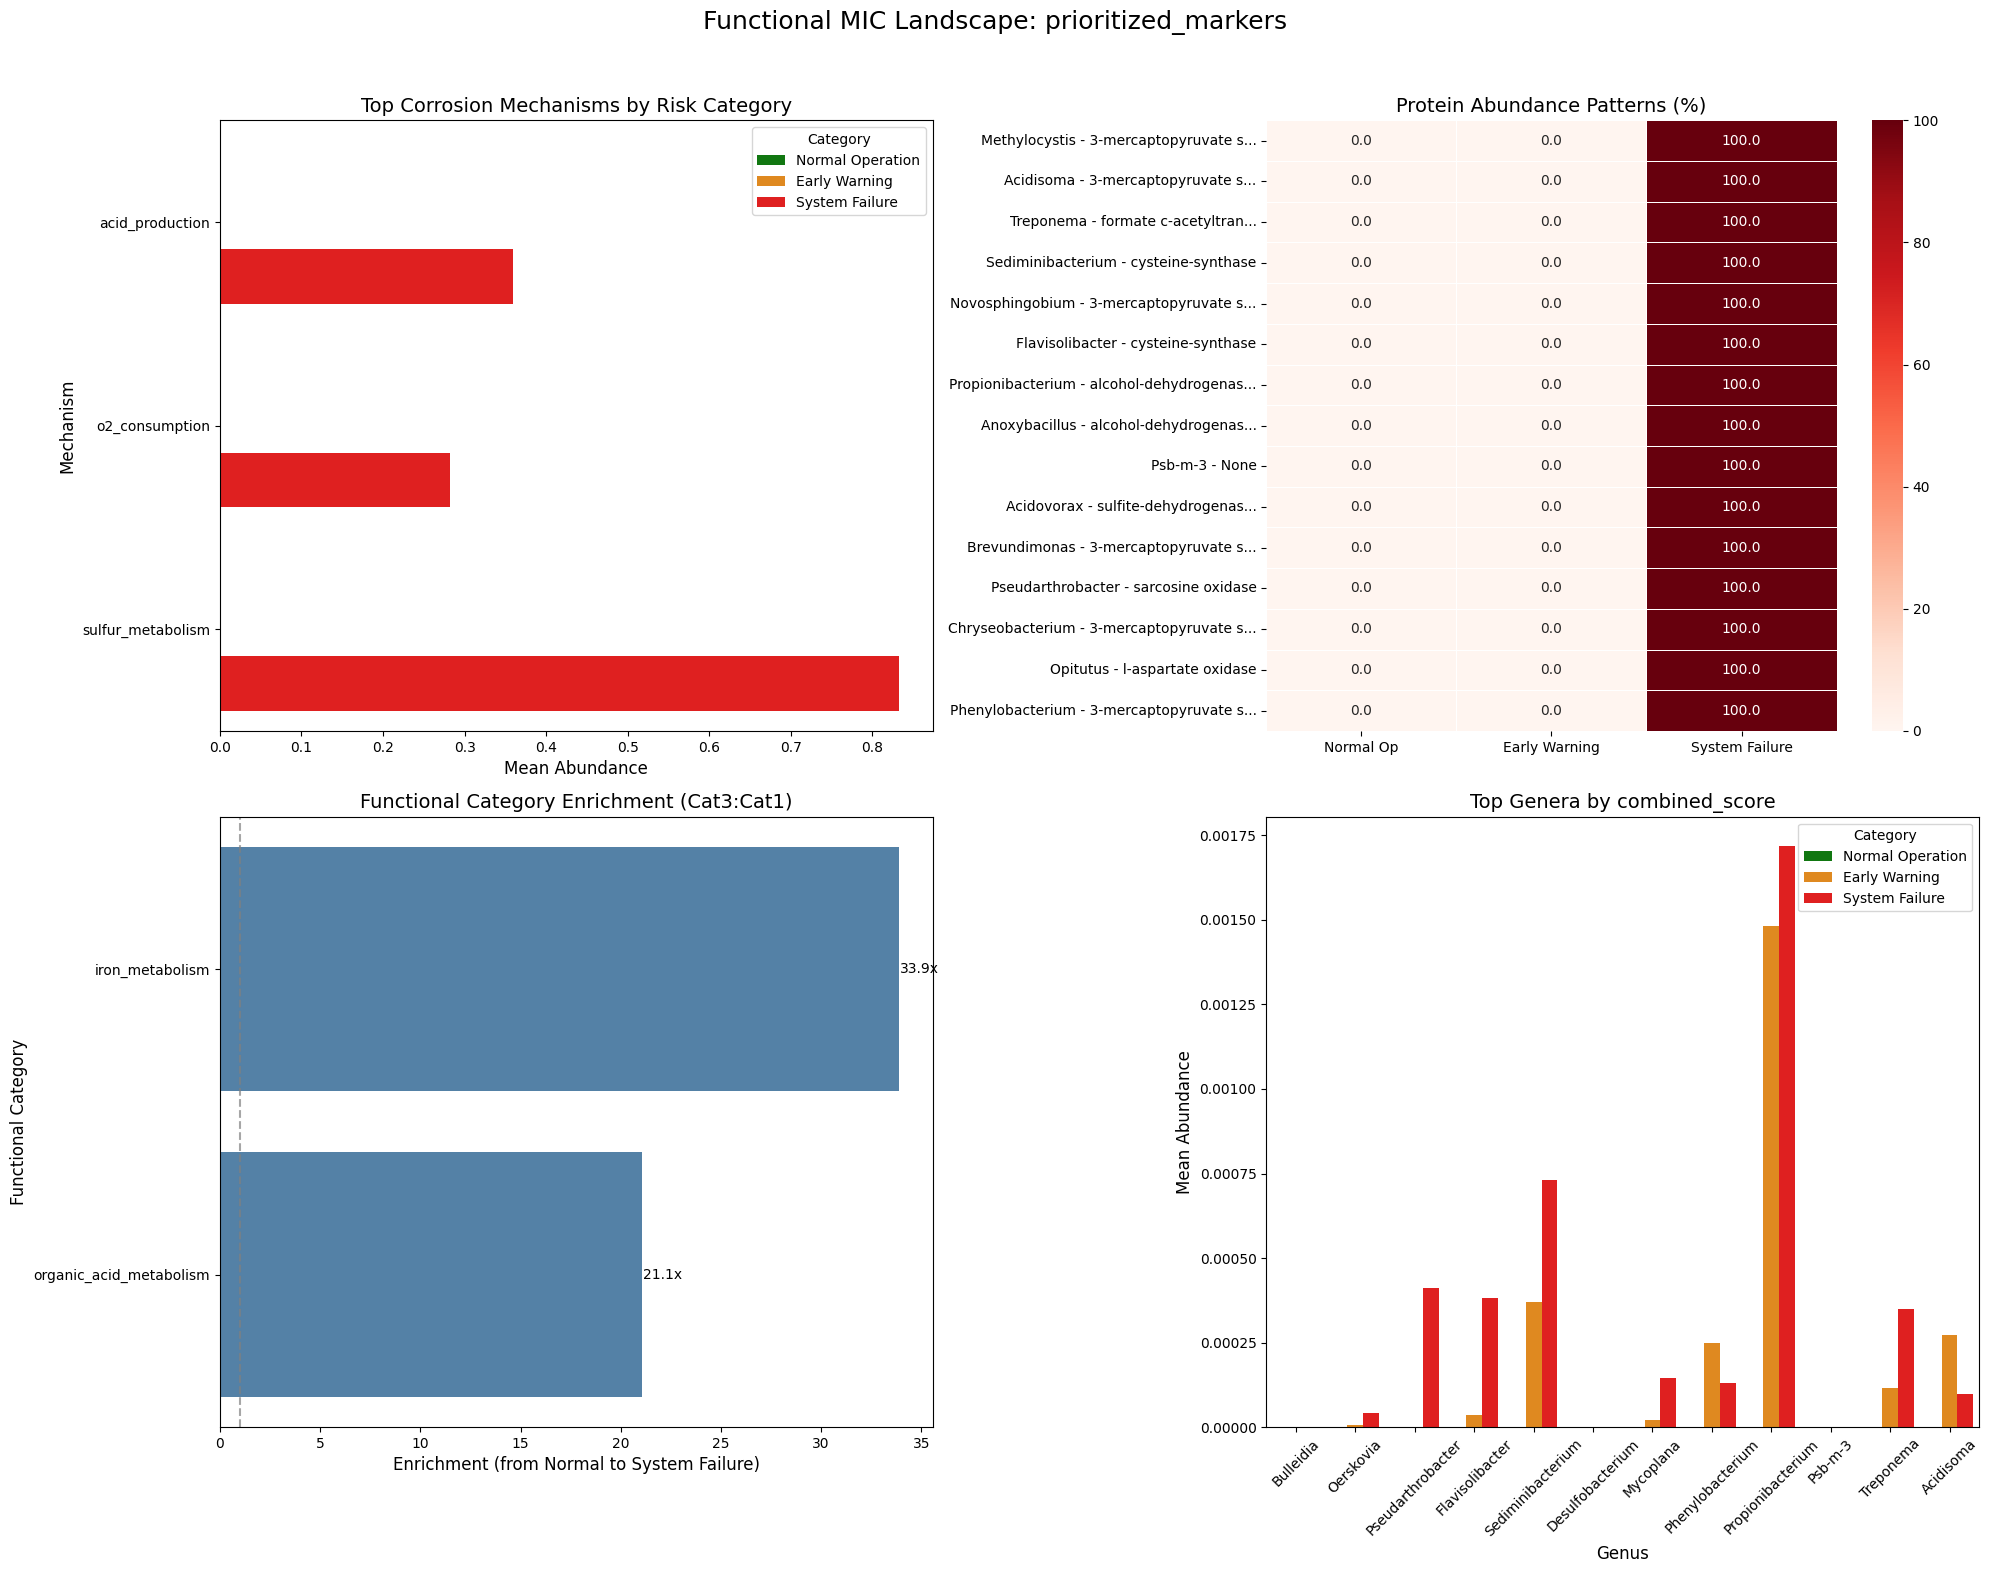

In [14]:
plot_multiview_functional_landscape(prioritized_markers,"prioritized_markers",  score_col="combined_score")
output_path = data_visual / "1_land.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

The prioritized_markers dataset (n=849769) represents a subset of microbial functional markers associated with corrosion risk, derived from rigorous multi-stage filtering and enrichment analysis. Starting from 1.39 million protein-genus pairs across 70 sampling sites, markers were first classified by abundance patterns across three corrosion severity categories (normal operation, early warning, system failure), retaining only those exhibiting significant increasing trends with corrosion severity (n=1,009,299). These candidates were then integrated with comprehensive metadata from BRENDA, MetalPDB, and KEGG databases to assign functional categories, metal-binding properties, metabolic pathways, and corrosion mechanisms to each marker. Pathway specificity analysis classified markers as either ubiquitous (present across all sites) or niche-specific (site-adapted), with 87% showing niche specificity. The subset has only the increasing patterns and last the prioritized markers top left shows biofilm formation and oxigen consumption as the highest mechanism at this bigger level, which contrast with more focus group in the following plot which correspond to a subset of the data high corrosion relevance with 199 markers. These have been further selected protein-genus pairs exceeding site-specific knee-point abundance thresholds while maintaining taxonomic diversity through balanced representation (top 10 markers per genus) and furhter reduction to obtain this group of high corrosion relevance. This group exhibit highet metabolism in acid production keeping biofilm formation as second mechanism. Catalasa protein is present in the larger group prioritized markers with other proteins more important as the group is filtered down to most relevant proteins on corrosion such as formate c acetyltransferasa, pyruvate carboxilase, thiosulphate dehydrogenase, acetate kinase, sarcosine oxidase, and alcohol dehydrogenase. Enrichment varies different on the general group there is 
strong enrichment in key corrosion-associated functions: biofilm formation  (>32% enrichment) and organic acid metabolism (>28 %). Whiles for the filtered group metal binding chelation enrichment predominates by more than 50%. Dominant genera for the first group highlight Propionibacterium, whiles the more specific group highlight Micrococcus and Staphylococcus, Desulphomicrobium and Clostridium. 

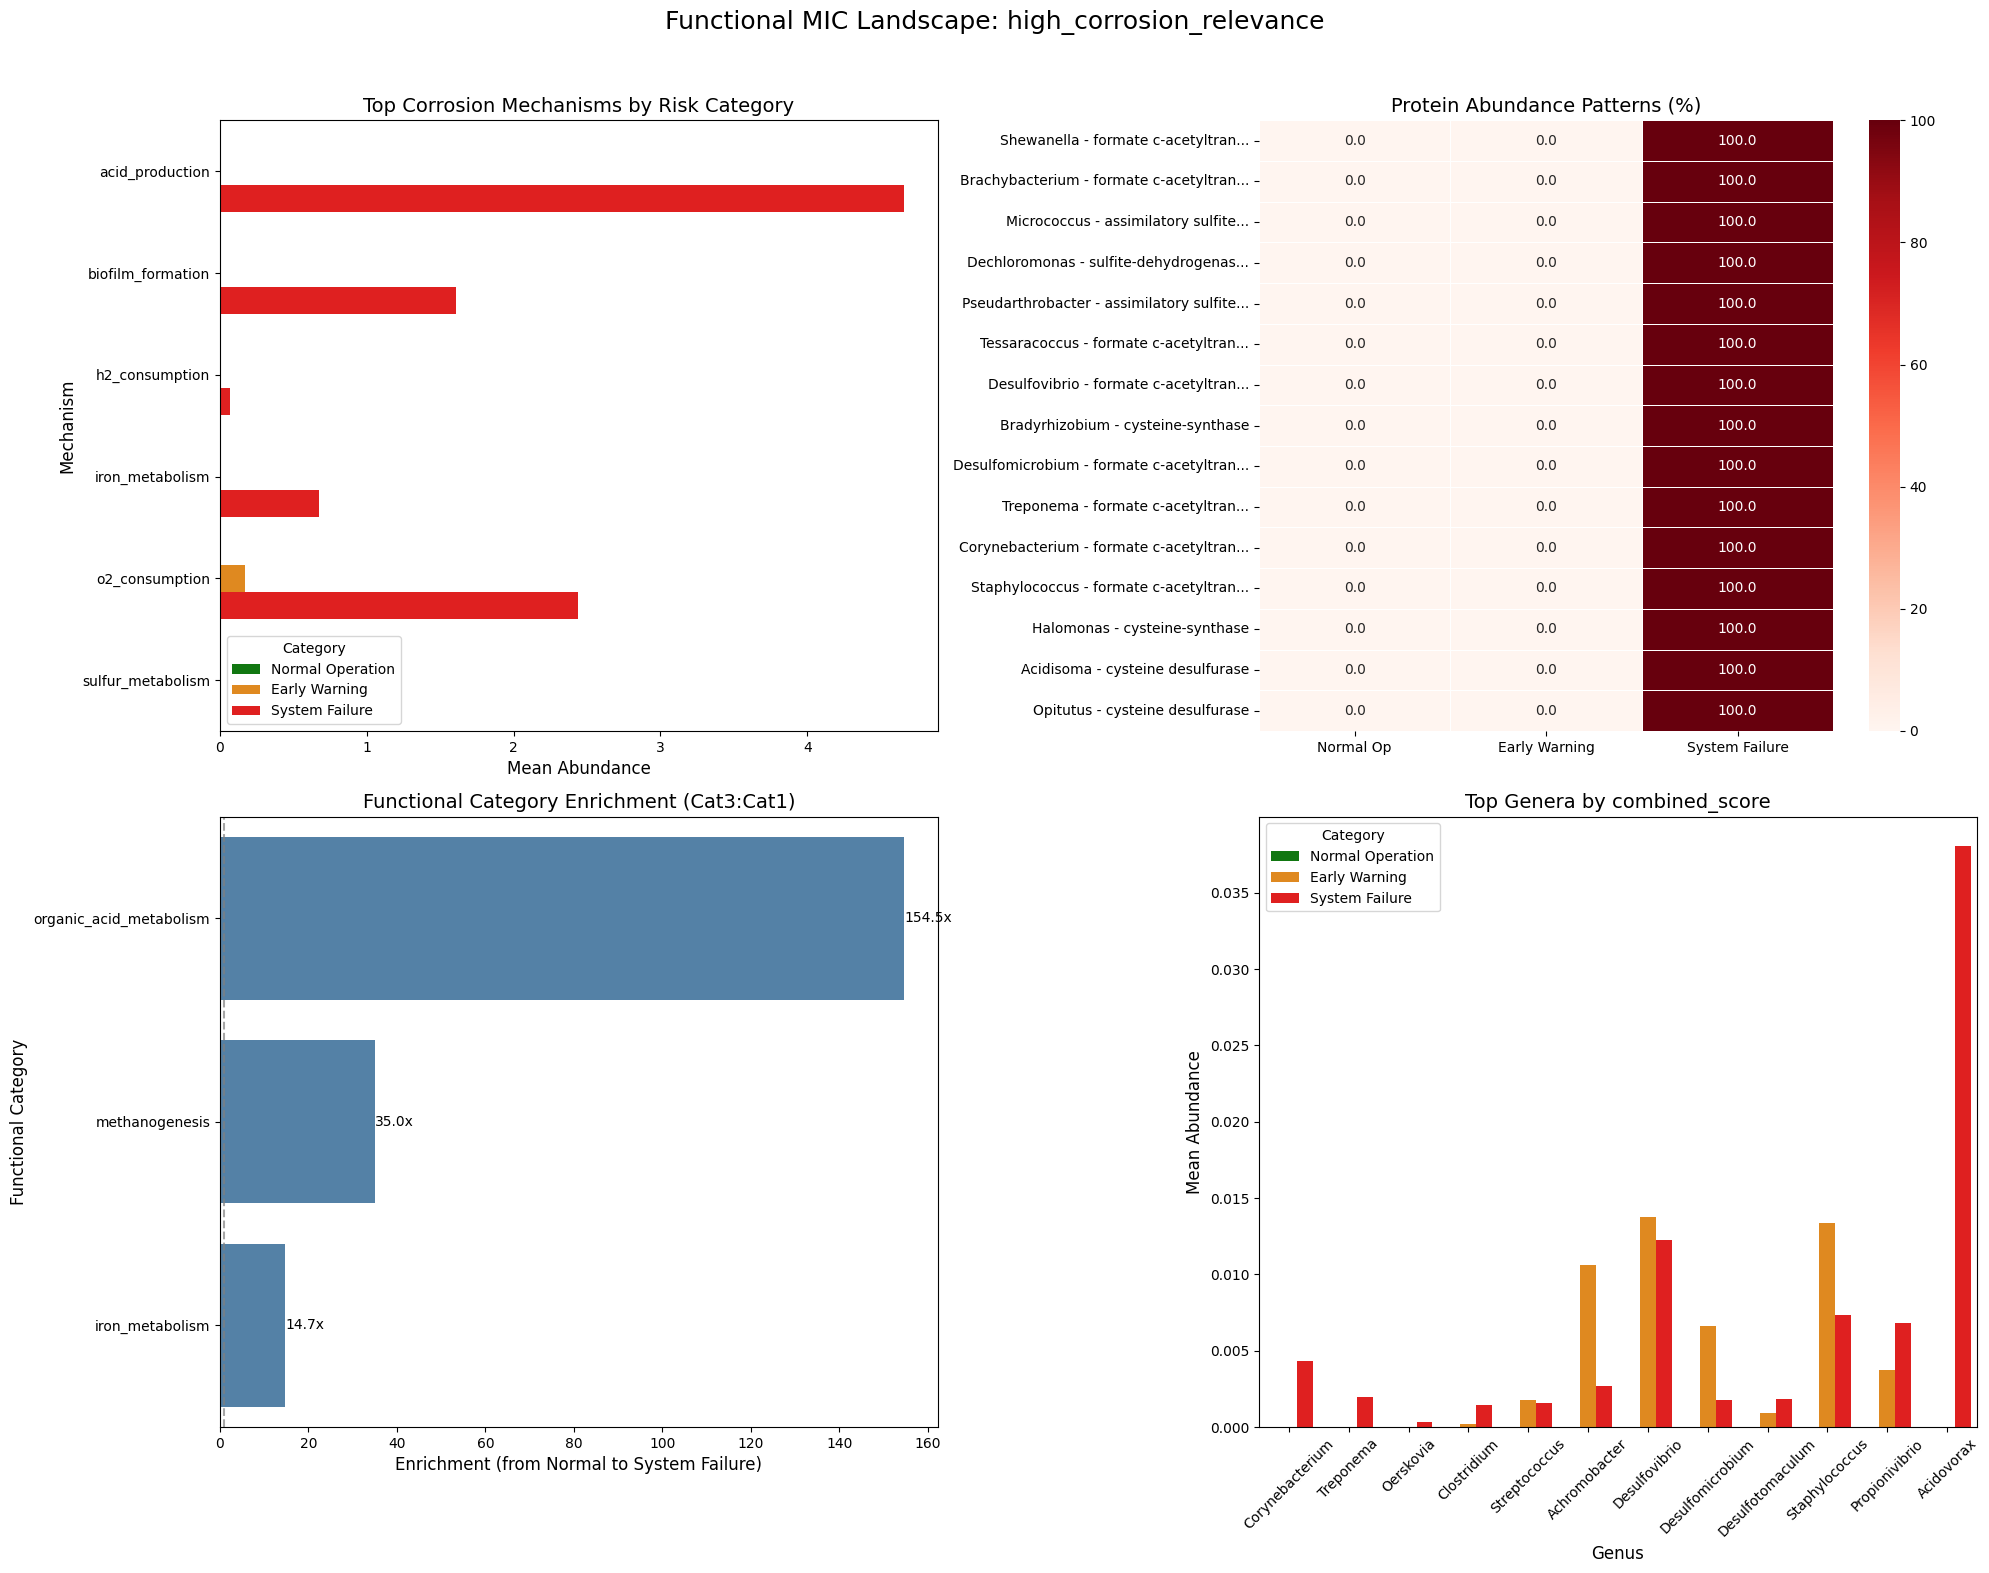

In [15]:
plot_multiview_functional_landscape(high_corrosion_relevance,"high_corrosion_relevance",  top_n=50, score_col="combined_score")

output_path = data_visual / "2_land.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight') 

## 3.2. Comparison of Mechanism by Category methodology

In [16]:
def corrosion_mechanism_original_vs_mean(top_markers, name="Comparison", top_n=10):
    """
    Create a comparison plot showing corrosion mechanisms using:
    1. Original Category (left subplot)
    2. Mean categories (right subplot)
    
    Parameters:     top_markers : DataFrame   containing the data with columns:   Category, corrosion_mechanisms, norm_abund_contri, mean_cat1, mean_cat2, mean_cat3
    name : str, optional to include in the plot title, by default "Comparison"
    top_n : int, optional    Number of top mechanisms to display, by default 10
    save_path : str, optional    Path to save the output figure, by default None
        
    Returns:  fig : matplotlib.figure.Figure  
    """
    
    # Define colors for mean categories
    mean_colors = {
        'mean_cat1': '#008800',  # Dark green
        'mean_cat2': '#FF8C00',  # Dark orange
        'mean_cat3': '#FF0000'   # Red
    }
    
    # Mean category labels for the legend
    mean_labels = {
        'mean_cat1': 'Normal Operation (Mean)',
        'mean_cat2': 'Early Warning (Mean)',
        'mean_cat3': 'System Failure (Mean)'
    }
    
    # Select top markers by score
    top_markers = top_markers.copy(deep=False)
    
    # Ensure Category is there and integer type to prevent mapping issues
    if 'Category' not in top_markers.columns:
        top_markers['Category'] = top_markers['Sites'].map(category_dict)
    top_markers['Category'] = top_markers['Category'].astype(int)
    
    # Create figure with multiple subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. FIRST PLOT: Original Category (left)
    mech_by_category = []
    for _, row in top_markers.iterrows():
        if isinstance(row.get('mechanisms_sub'), str) and row['mechanisms_sub'] and pd.notna(row['norm_abund_contri']):
            mechanisms = [row['mechanisms_sub']]
            for mech in mechanisms:
                if mech:  # Ensure mechanism is not empty
                    mech_by_category.append({
                        'Mechanism': mech,
                        'Category': int(row['Category']),  # Ensure integer type
                        'norm_abund_contri': row['norm_abund_contri']
                    })
    
    # Convert to DataFrame and aggregate
    mech_df = pd.DataFrame(mech_by_category)
    
    # Check if we have mechanisms data to plot
    if not mech_df.empty:
        # Group by mechanism and original category, summing abundance
        agg_mech = mech_df.groupby(['Mechanism', 'Category'])['norm_abund_contri'].sum().reset_index(name='Abundance')
        
        # Sort by abundance and get top mechanisms
        top_mechanisms = agg_mech.groupby('Mechanism')['Abundance'].sum().nlargest(top_n).index
        agg_mech = agg_mech[agg_mech['Mechanism'].isin(top_mechanisms)]
        
        # Create the plot with consistent category colors
        sns.barplot(
            data=agg_mech,
            x='Abundance',
            y='Mechanism',
            hue='Category',
            palette=category_colors,
            ax=ax1
        )
        
        # Ensure legend shows categories with proper labels
        handles, labels = ax1.get_legend_handles_labels()
        ax1.legend(handles=handles, labels=[categories_labels[int(label)] for label in labels])
        ax1.set_title(f"Top Corrosion Mechanisms - {name}\nBy Original Category", fontsize=14)
        ax1.set_xlabel('Abundance', fontsize=12)
        ax1.set_ylabel('Mechanism', fontsize=14)
    else:
        ax1.text(0.5, 0.5, "No mechanism data available", ha='center', va='center', fontsize=14)
        ax1.set_title('Top Corrosion Mechanisms by Original Category', fontsize=14)
    
    # 2. SECOND PLOT: Mean categories (right)
    mech_by_mean = []
    for _, row in top_markers.iterrows():
        if isinstance(row.get('mechanisms_sub'), str) and row['mechanisms_sub'] and pd.notna(row['norm_abund_contri']):
            mechanisms = [row['mechanisms_sub']]
            
            # Get mean values
            mean_cat1 = row.get('mean_cat1', 0)
            mean_cat2 = row.get('mean_cat2', 0)
            mean_cat3 = row.get('mean_cat3', 0)
            
            for mech in mechanisms:
                if mech:  # Ensure mechanism is not empty
                    # Add entry for each category with its corresponding mean value
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat1',
                        'Abundance': mean_cat1 * row['norm_abund_contri']
                    })
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat2',
                        'Abundance': mean_cat2 * row['norm_abund_contri']
                    })
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat3',
                        'Abundance': mean_cat3 * row['norm_abund_contri']
                    })
    
    # Convert to DataFrame for mean categories
    mean_mech_df = pd.DataFrame(mech_by_mean)
    
    # Second plot - mean categories
    if not mean_mech_df.empty:
        # Use the same top mechanisms as in the first plot for consistency
        # Aggregate by mechanism and mean category
        agg_mean_mech = mean_mech_df.groupby(['Mechanism', 'Mean_Category'])['Abundance'].sum().reset_index()
        
        # Filter to the same top mechanisms from the first plot for consistency
        agg_mean_mech = agg_mean_mech[agg_mean_mech['Mechanism'].isin(top_mechanisms)]
        
        # Create the plot with mean category colors
        sns.barplot(
            data=agg_mean_mech,
            x='Abundance',
            y='Mechanism',
            hue='Mean_Category',
            palette=mean_colors,
            ax=ax2
        )
        
        # Update legend with readable mean category labels
        handles, labels = ax2.get_legend_handles_labels()
        ax2.legend(handles=handles, labels=[mean_labels[label] for label in labels])
        
        ax2.set_title(f"Top Corrosion Mechanisms - {name}\nBy Mean Categories", fontsize=14)
        ax2.set_xlabel('Abundance', fontsize=14)
        ax2.set_ylabel('', fontsize=14)  
    else:
        ax2.text(0.5, 0.5, "No mechanism data available", ha='center', va='center', fontsize=14)
        ax2.set_title('Top Corrosion Mechanisms by Mean Categories', fontsize=14)
    
    plt.tight_layout(pad=2)
    
    return fig

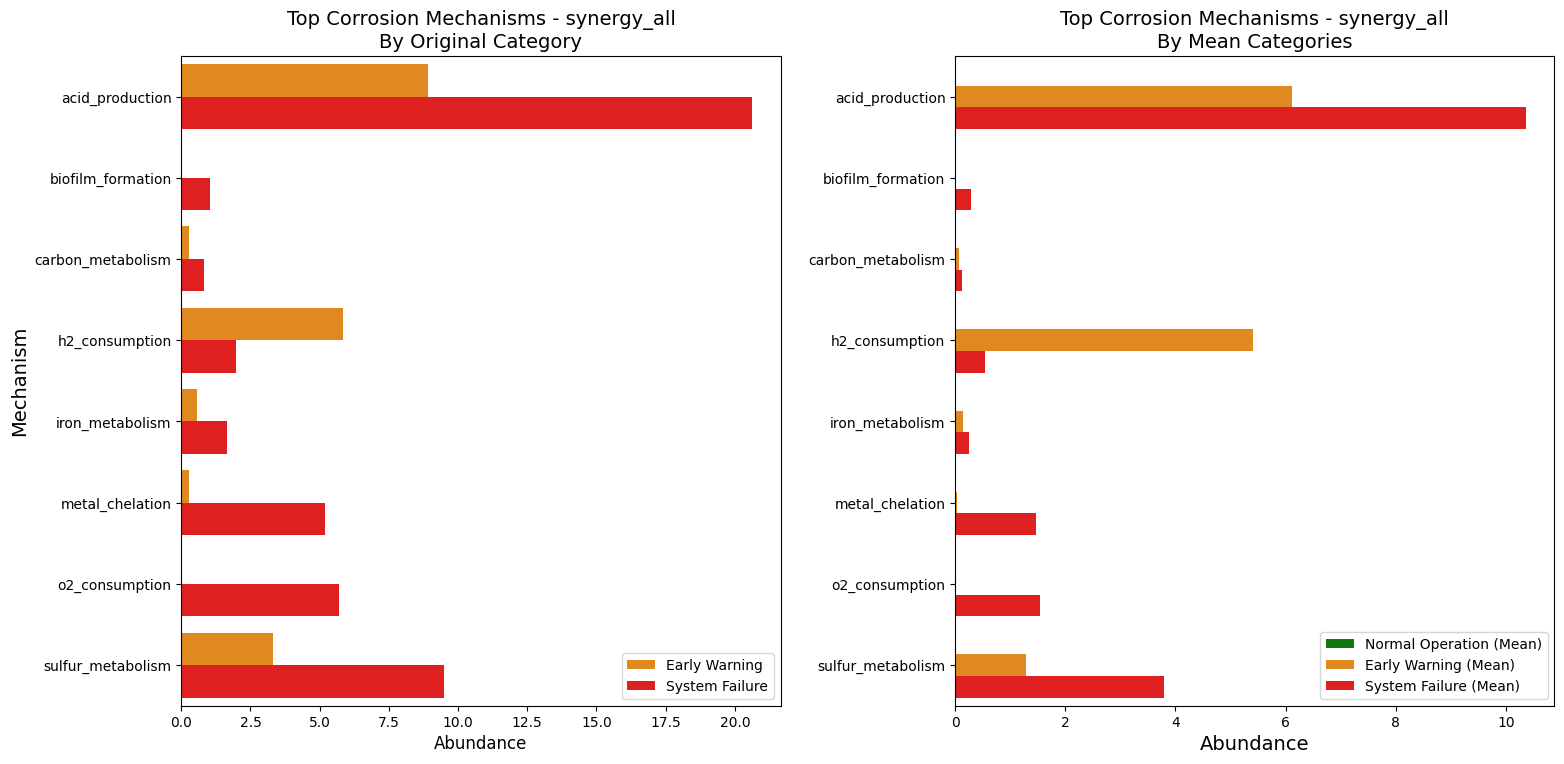

In [17]:
#Calling the function:
fig = corrosion_mechanism_original_vs_mean(synergy_all, "synergy_all",  top_n=150)

output_path = data_visual / "3_mech.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

This figure presents a quality control comparison of corrosion mechanism distributions in top_markers, contrasting original category stratification (left) against mean category aggregation (right). The left panel shows mechanism abundance as stacked bars for Early Warning (orange) and System Failure (red), with acid production dominating system failure conditions (n≈30). The right panel aggregates all three severity categories, demonstrating that proportional representation remains consistent: acid production maintains dominance (mean≈20), followed by oxygen consumption and sulfur metabolism at intermediate levels (mean≈7-8). This concordance validates the use of mean aggregation for downstream analyses, confirming that averaging across severity categories preserves the mechanistic hierarchy without introducing systematic bias.

## 3.3 Pathway Data across Risk Categories MultiPathway Analysis

In [18]:
def plot_pathway_analysis(data_df, name, top_n=100, score_col='combined_score', 
                         pathway_source='niche_specific_pathways'):
    """
    Comprehensive pathway analysis with improved visualizations.
    Uses EXPLODED columns (no splitting needed).
    
    Parameters:
    -----------
    pathway_source : str
        Column to use for pathway analysis. Options:
        - 'niche_specific_pathways' : Specific pathways from PICRUSt2
        - 'pathways' : All pathway child terms
        - 'functional_sub' : Functional subcategories (cleaner)
        - 'mechanisms_sub' : Mechanism subcategories
    """
    df = data_df.copy() 
    # Make copy and select top markers
    if 'pathways' in df.columns:
        # Apply the new single-value function across the entire 'pathways' Series
        df['pathways'] = df['pathways'].apply(rename_pathway_single)

    # Handle different scoring scenarios
    if score_col in df.columns:
        top_markers = df.sort_values(score_col, ascending=False).head(top_n)
    else:
        top_markers = df.sort_values('mean_cat3', ascending=False).head(top_n)
        print(f"Warning: {score_col} not found, using mean_cat3 for sorting")
    # change some names of the pathways rows on pathways column
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # === COLLECT PATHWAY DATA FROM EXPLODED COLUMN ===
    pathway_data = []
    
    # Check if pathway source column exists
    if pathway_source not in top_markers.columns:
        print(f"Error: Column '{pathway_source}' not found. Available columns: {top_markers.columns.tolist()}")
        return None, {}
    
    # Collect data - NO SPLITTING since columns are already exploded
    for _, row in top_markers.iterrows():
        pathway_val = row[pathway_source]
        
        # Filter out NaN, empty strings, and 'nan' strings
        if pd.notna(pathway_val) and str(pathway_val).strip() and str(pathway_val).strip().lower() != 'nan':
            pathway_data.append({
                'Category': str(pathway_val).strip(),
                'Genus': row.get('Genus', 'Unknown'),
                'Cat1': row.get('mean_cat1', 0),
                'Cat2': row.get('mean_cat2', 0), 
                'Cat3': row.get('mean_cat3', 0),
                'Score': row.get(score_col, 0)
            })
    
    if not pathway_data:
        print(f"No valid pathway data found in column '{pathway_source}'")
        fig.text(0.5, 0.5, f'No pathway data available in {pathway_source}', 
                ha='center', va='center', fontsize=16)
        return fig, {}
    
    pathway_df = pd.DataFrame(pathway_data)
    print(f"\nFound {len(pathway_df)} pathway entries from {pathway_df['Category'].nunique()} unique pathways")
    print(f"Top 10 pathways by frequency:")
    print(pathway_df['Category'].value_counts().head(10))
    
    # === PLOT 1: Pathway Category Distribution ===
    # Count occurrences and get top categories
    category_counts = pathway_df['Category'].value_counts().head(15)
    
    # Create horizontal bar plot
    sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        palette='viridis',
        ax=axes[0, 0]
    )
    
    # Add count labels
    for i, (cat, count) in enumerate(category_counts.items()):
        axes[0, 0].text(count + 0.5, i, str(count), 
                       va='center', ha='left', fontweight='bold', fontsize=10)
    
    axes[0, 0].set_title(f'Most Frequent Pathways ({pathway_source})', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Frequency in Top Markers', fontsize=12)
    axes[0, 0].set_ylabel('Pathway', fontsize=12)
    
    # === PLOT 2: Risk Category Progression ===
    # Aggregate by pathway category across risk levels
    risk_progression = pathway_df.groupby('Category')[['Cat1', 'Cat2', 'Cat3']].sum()
    # Normalize by number of proteins to make comparable across datasets
    n_proteins = len(pathway_df)
    risk_progression = risk_progression / n_proteins
    
    # Get top categories by Cat3 abundance
    top_categories = risk_progression.sort_values('Cat3', ascending=False).head(8)
    
    # Prepare data for line plot
    progression_data = []
    for category in top_categories.index:
        for i, (col, label) in enumerate(zip(['Cat1', 'Cat2', 'Cat3'], categories_labels)):
            progression_data.append({
                'Category': category,
                'Risk_Level': label,
                'Risk_Level_Num': i+1,
                'Abundance': top_categories.loc[category, col]
            })
    
    prog_df = pd.DataFrame(progression_data)
    
    # Create line plot showing progression
    for category in top_categories.index[:6]:  # Limit to 6 for readability
        cat_data = prog_df[prog_df['Category'] == category]
        axes[0, 1].plot(cat_data['Risk_Level_Num'], cat_data['Abundance'], 
                       marker='o', linewidth=2, markersize=8, 
                       label=category[:30] + ('...' if len(category) > 30 else ''))
    
    axes[0, 1].set_xticks([1, 2, 3])
    axes[0, 1].set_xticklabels(categories_labels, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Mean Abundance', fontsize=12)
    axes[0, 1].set_title('Pathway Progression Across Risk Levels', fontsize=14, fontweight='bold')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # === PLOT 3: Enrichment Analysis ===
    # Calculate enrichment ratios
    enrichment_data = pathway_df.groupby('Category').agg({
        'Cat1': 'sum',
        'Cat3': 'sum',
        'Score': 'mean'
    }).reset_index()
    # Normalize by dataset size
    n_proteins = len(pathway_df)
    enrichment_data['Cat1'] = enrichment_data['Cat1'] / n_proteins
    enrichment_data['Cat3'] = enrichment_data['Cat3'] / n_proteins
    
    # Calculate enrichment (Cat3:Cat1 ratio)
    enrichment_data['Enrichment'] = enrichment_data.apply(
        lambda x: (x['Cat3'] + 0.01) / (x['Cat1'] + 0.01), axis=1
    )
    
    # Filter for meaningful enrichment and get top enriched
    significant_enrichment = enrichment_data[
        (enrichment_data['Cat1'] > 0.01) | (enrichment_data['Cat3'] > 0.01)
    ].sort_values('Enrichment', ascending=False).head(12)
    
    if not significant_enrichment.empty:
        # Create enrichment plot with color coding
        colors = ['#d62728' if x > 2 else '#ff7f0e' if x > 1.5 else '#2ca02c' 
                 for x in significant_enrichment['Enrichment']]
        
        bars = axes[1, 0].barh(range(len(significant_enrichment)), 
                              significant_enrichment['Enrichment'],
                              color=colors, alpha=0.7)
        
        # Add enrichment value labels
        for i, (idx, row) in enumerate(significant_enrichment.iterrows()):
            axes[1, 0].text(row['Enrichment'] + 0.1, i, 
                           f"{row['Enrichment']:.1f}x",
                           va='center', ha='left', fontweight='bold', fontsize=10)
        
        axes[1, 0].set_yticks(range(len(significant_enrichment)))
        axes[1, 0].set_yticklabels([cat[:35] + ('...' if len(cat) > 35 else '') 
                                   for cat in significant_enrichment['Category']], fontsize=10)
        axes[1, 0].axvline(x=1, color='gray', linestyle='--', alpha=0.7, linewidth=2)
        axes[1, 0].set_xlabel('Enrichment Ratio (from Normal to System Failure)', fontsize=12)
        axes[1, 0].set_title('Pathway Enrichment in High Risk', fontsize=14, fontweight='bold')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # === PLOT 4: Genus-Pathway Network ===
    if len(pathway_df) > 10:
        # Create network graph
        G = nx.Graph()
        
        # Get top genera and pathways
        top_genera = pathway_df['Genus'].value_counts().head(10).index
        top_pathways = pathway_df['Category'].value_counts().head(12).index
        
        # Add nodes
        for genus in top_genera:
            genus_score = pathway_df[pathway_df['Genus'] == genus]['Score'].mean()
            G.add_node(f"G_{genus}", node_type='genus', score=genus_score)
        
        for pathway in top_pathways:
            pathway_score = pathway_df[pathway_df['Category'] == pathway]['Score'].mean()
            # Truncate long pathway names
            pathway_short = pathway[:25] if len(pathway) > 25 else pathway
            G.add_node(f"P_{pathway_short}", node_type='pathway', score=pathway_score)
        
        # Add edges based on co-occurrence
        edge_weights = defaultdict(int)
        for _, row in pathway_df.iterrows():
            if row['Genus'] in top_genera and row['Category'] in top_pathways:
                genus_node = f"G_{row['Genus']}"
                pathway_short = row['Category'][:25] if len(row['Category']) > 25 else row['Category']
                pathway_node = f"P_{pathway_short}"
                edge_weights[(genus_node, pathway_node)] += 1
        
        # Add edges to graph
        for (u, v), weight in edge_weights.items():
            if weight > 0:  # Show all connections
                G.add_edge(u, v, weight=weight)
        
        if len(G.nodes()) > 0 and len(G.edges()) > 0:
            # Layout with better spacing
            pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
            
            # Draw nodes
            genus_nodes = [n for n in G.nodes() if n.startswith('G_')]
            pathway_nodes = [n for n in G.nodes() if n.startswith('P_')]
            
            if genus_nodes:
                nx.draw_networkx_nodes(G, pos, nodelist=genus_nodes, 
                                     node_color='lightcoral', node_size=1000,
                                     alpha=0.8, ax=axes[1, 1])
            
            if pathway_nodes:
                nx.draw_networkx_nodes(G, pos, nodelist=pathway_nodes,
                                     node_color='lightblue', node_size=800,
                                     alpha=0.8, ax=axes[1, 1])
            
            # Draw edges with varying thickness
            edges = G.edges()
            if edges:
                weights = [G[u][v]['weight'] for u, v in edges]
                max_weight = max(weights) if weights else 1
                nx.draw_networkx_edges(G, pos, width=[w/max_weight * 3 for w in weights],
                                     alpha=0.5, ax=axes[1, 1])
            
            # Draw labels with better formatting
            labels = {n: n[2:18] + ('...' if len(n) > 20 else '') for n in G.nodes()}
            nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=axes[1, 1])
            
            axes[1, 1].set_title('Genus-Pathway Network\n(Red=Genera, Blue=Pathways)', 
                               fontsize=14, fontweight='bold')
        
        axes[1, 1].axis('off')
    
    # Overall styling
    plt.suptitle(f"Pathway Analysis: {name} (source: {pathway_source})", 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Return results
    results = {
        'pathway_df': pathway_df,
        'category_counts': category_counts,
        'enrichment_data': enrichment_data,
        'top_categories': top_categories
    }
    
    return fig, results


Found 67 pathway entries from 2 unique pathways
Top 10 pathways by frequency:
Category
superpathway of N-acetylneuraminate degradation    65
creatinine degradation II                          2 
Name: count, dtype: int64


/tmp/ipykernel_452/2985027161.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


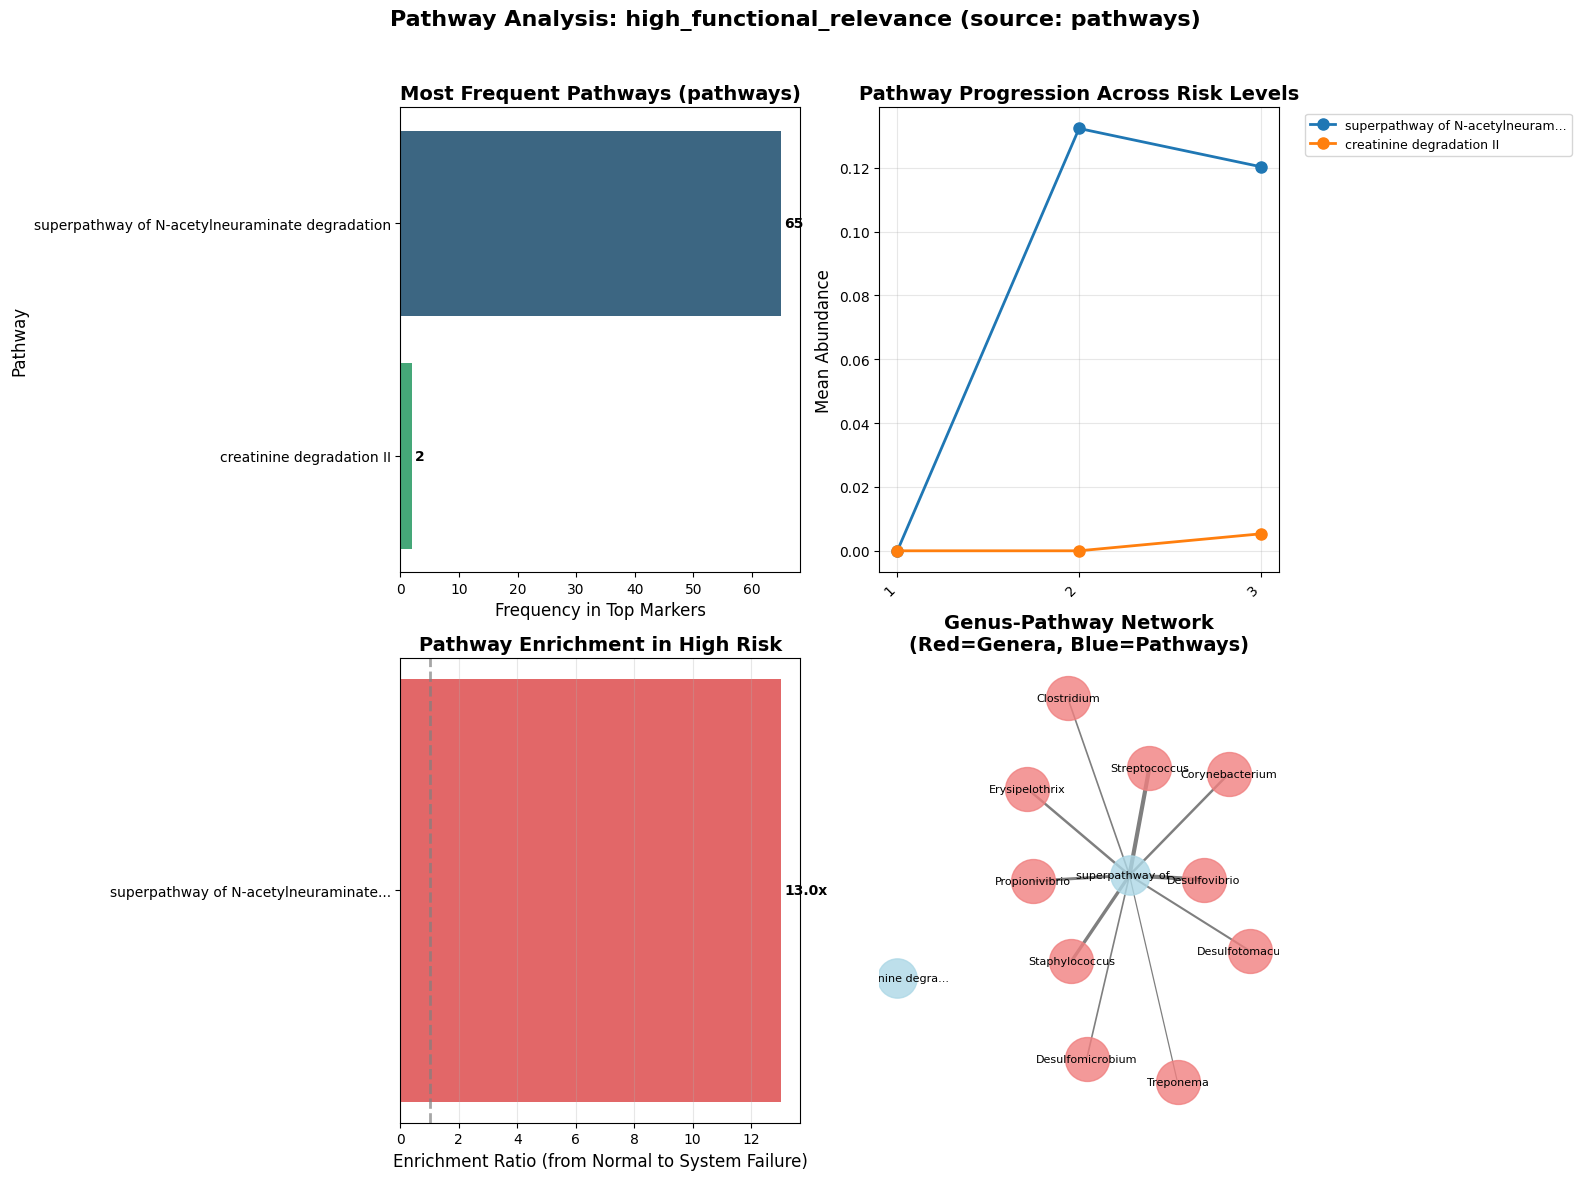

<Figure size 640x480 with 0 Axes>

In [19]:
fig, results = plot_pathway_analysis(high_functional_relevance, "high_functional_relevance", top_n=100, score_col='combined_score', 
                                     pathway_source='pathways')

output_path = data_visual / "4_pathws.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

The plot back on repo 2_Micro, Notebook 6_picrust_functional, section 7.3. showed the distribution of pathway abundances. It was seen there the general classification without any further classification, on the contrary this plot present a more filtered pathways. The present plot presents pathway-level functional enrichment analysis for the high functional relevance group (n=263), revealing specialized metabolic profiles distinct from the universal housekeeping pathways observed in the unfiltered dataset. Unlike the general pathway distribution back in notebook 6, dominated by aerobic respiration and glycolysis, this filtered subset highlights corrosion-associated pathways enriched in system failure conditions: superpathway of N-acetylneuraminate degradation (48), Phenylethanol biosynthesis (12) and acetobutylicum solventogenic fermentation (6). The abundance heatmap demonstrates that most pathways are exclusive to Category 3 (system failure), with select pathways showing intermediate emergence in Category 2 (early warning)—notably N-acetylneuraminate degradation, same one in the enrichment plot. The genus-pathway network reveals taxonomic associations, that will be better expanded later on the notebook. This targeted enrichment validates the corrosion protein pipeline's ability to filter background metabolism and identify MIC-specific functional profiles.


Found 150 pathway entries from 12 unique pathways
Top 10 pathways by frequency:
Category
superpathway of N-acetylneuraminate degradation            69
Superpathway of CDP-diacylglycerol Biosynthesis            17
acetobutylicum solventogenic fermentation                  15
Superpathway of sulfide oxidation                          11
Acetyl-CoA Fermentation Pathway                            7 
superpathway of sulfur oxidation (Acidianus ambivalens)    6 
Phenylethanol biosynthesis                                 6 
L-1,2-propanediol degradation                              6 
Sucrose degradation (anaerobic)                            5 
Superpathway of sulfur metabolism                          3 
Name: count, dtype: int64


/tmp/ipykernel_452/2985027161.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


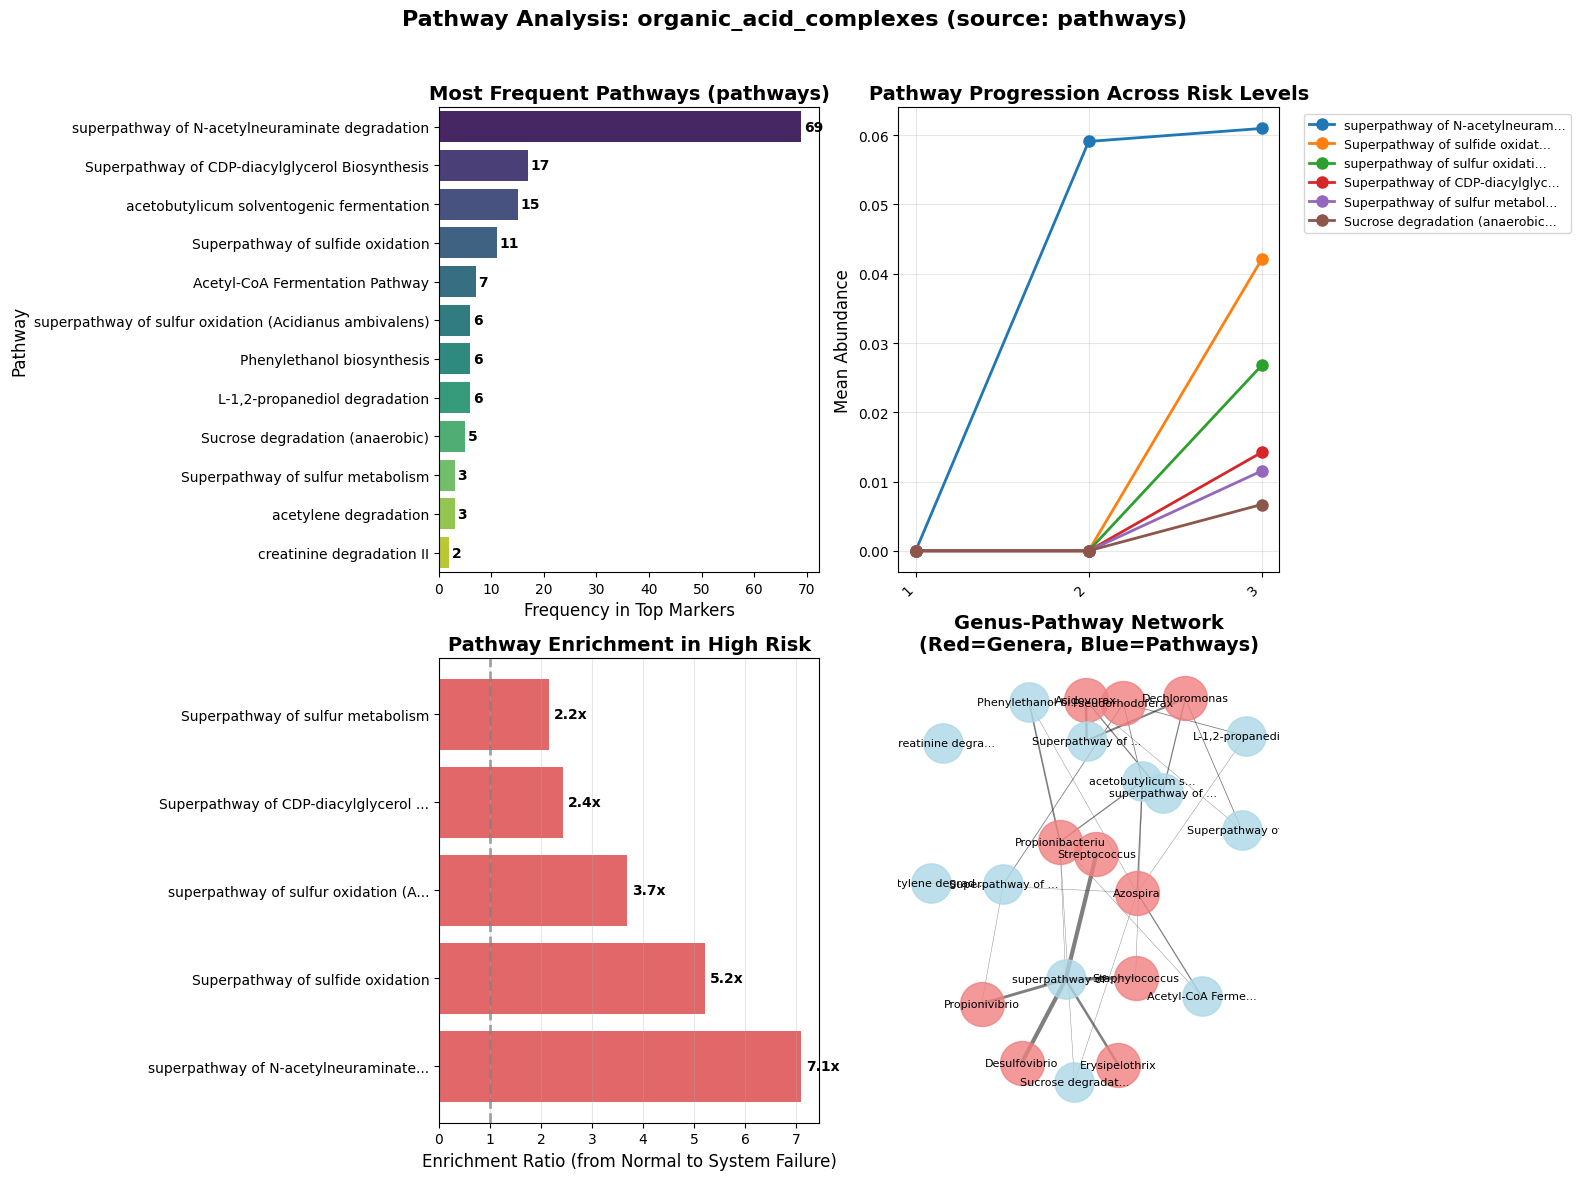

<Figure size 640x480 with 0 Axes>

In [20]:
fig, results = plot_pathway_analysis(organic_acid_complexes, "organic_acid_complexes", top_n=200, score_col='combined_score', 
                                     pathway_source='pathways')

output_path = data_visual / "4_pathways_organic.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

Most important pathways are Superpathway of UDP-GlcA Biosynthesis (12), glycerol degradation to butanol (9) and L-arabinose degradation IV (5). Why those 3 pathways converge on this group? they all contribute to the poll of organic acid formation which in turns degradates the metal which is central to the corrosion process.  Their convergence indicates a metabolic strategy in the biofilm community that maximizes (1) structural defense and detoxification, (2) localized acidic attack, and (3) redox control, all of which directly contribute to the microbially influenced corrosion (MIC) process and subsequent metal degradation.
The Superpathway of UDP-GlcA Biosynthesis, is fundamentally anabolic/detoxification. Its primary role is the continuous production of nucleotide sugar precursors, including UDP-GlcA, UDP-Galacturonic Acid (UDP-GalA), and UDP-Xylose (UDP-Xyl), which are essential for synthesizing complex biopolymers such as glycans, using up NAD+. These compounds from the building blocks of the EPS matrix. Additionally it is critical for glucoronidation, serving a direct detoxification function increasing the solibility to the xenobiotic/foraneous compounds in solution aiding in their excretion. The pathway Glycerol Degradation to Butanol, is catsfsfabolic, characteristic of specialized anaerobic microorganisms like Clostridia. The process involves an obligatory acidogenesis phase where small organic acids—namely acetate and butanoate—are rapidly generated, requiring NAD+. This local accumulation of weak acids directly causes a significant pH drop at the metal interface, accelerating the direct dissolution of the passive oxide layer and contributing to localized pitting corrosion. 
Last pathway contribuying corresponds to  L-Arabinose Degradation IV, which is a catabolic route to the production of short chain fatty acids SCFA. The three pathways also converge on the regulatory competition for the oxidized cofactor NAD+. This competition is crucial: the high NAD+ consumption in the anabolic UDP-GlcA pathway limits the NAD+ required for efficient catabolism in the glycerol pathway, directly affecting acid and solvent yields. 
Enrichment analysis proposes the glicerol degradation to be amplified on the fold 1 to 3 more than the other two pathways.This enrichment is highly significant in the context of corrosion, suggesting the microbial community is actively prioritizing the production of the highly localized, corrosive C2 (acetate) and C4 (butanoate) organic acids above its anabolic and specialized pentose utilization needs. The genus-pathway network reveals critical taxonomic associations, which will be better seen in the next plots.

## 3.4. Temporal Transition and Mechanisms Distribution by Risk Categories

In [21]:
def temporal_transition(prioritized_markers: pd.DataFrame, name: str, weight_mode: str = "composite", normalize: bool = True,
                        category_dict: dict = None, abundance_col: str = "norm_abund_contri") -> go.Figure:
    """ Create a Sankey diagram: mechanism -> dominant risk category.
    Parameters    - prioritized_markers: DataFrame with columns: 'mechanisms_sub', 'mean_cat1','mean_cat2','mean_cat3', 'significance_score', 'max_abs_log2fc'
        and an abundance column (e.g., 'norm_abund_contri')
    - name: title suffix for the figure
    - weight_mode: 'composite' (default), 'composite_abs', 'significance', 'magnitude', 'counts'
      - composite: normalized product of (sig * mag * abundance)
      - composite_abs: normalized sig and mag, multiplied by ABSOLUTE abundance from abundance_col
      - significance: use significance_score alone
      - magnitude: use max_abs_log2fc alone
      - counts: each row contributes 1
    - normalize: if True, min-max normalization is applied to sig/mag when used. If normalize=False and weight_mode='composite', raw columns are multiplied.
    - category_dict: optional mapping Sites -> Category (used if 'Category' missing)
    - abundance_col: column name to use as the absolute abundance input 
    Returns: Plotly Figure (always a Figure; never None)
    """

    df = prioritized_markers.copy(deep=False)
    if isinstance(normalize, str):
        normalize = normalize.strip().lower() in ('1', 'true', 't', 'yes', 'y')
    def _empty_fig(title, message):
        fig = go.Figure()
        fig.update_layout(
            title=title,
            annotations=[dict(text=message, showarrow=False, x=0.5, y=0.5, xref='paper', yref='paper')]
        )
        return fig

    # Ensure Category exists or map if possible
    if 'Category' not in df.columns and category_dict is not None and 'Sites' in df.columns:
        df['Category'] = df['Sites'].map(category_dict)

    # Required mean columns
    required_mean_cols = ['mean_cat1', 'mean_cat2', 'mean_cat3']
    if not all(c in df.columns for c in required_mean_cols):
        return _empty_fig("No Sankey: missing mean_cat columns",
                          "Missing one of mean_cat1 / mean_cat2 / mean_cat3")

    # Compute dominant category (same logic as before)
    df['dominant_category_col'] = df[required_mean_cols].idxmax(axis=1)
    df['dominant_category'] = df['dominant_category_col'].map({
        'mean_cat1': 'Category 1',
        'mean_cat2': 'Category 2',
        'mean_cat3': 'Category 3'
    })
    df['dominant_value'] = df[required_mean_cols].max(axis=1)

    # Mechanism column
    if 'mechanisms_sub' not in df.columns and 'mechanisms' not in df.columns:
        return _empty_fig("No Sankey: missing mechanisms column",
                          "No 'mechanisms_sub' or 'mechanisms' column found.")
    mech_col = 'mechanisms_sub' if 'mechanisms_sub' in df.columns else 'mechanisms'

    # Check significance/magnitude
    if 'significance_score' not in df.columns:
        return _empty_fig("No Sankey: missing significance_score",
                          "Missing 'significance_score' column.")
    if 'max_abs_log2fc' not in df.columns:
        df['max_abs_log2fc'] = df['dominant_value'].abs()

    # USE CATEGORY-SPECIFIC ABUNDANCE for flows
    # Instead of one abundance value, use the actual mean_cat value for the dominant category
    df['category_specific_abundance'] = df.apply(
        lambda row: row.get(row['dominant_category_col'], 0) if pd.notna(row.get('dominant_category_col')) else 0,
        axis=1
    )

    # This is the abundance that matches where the flow goes!
    raw_ab = df['category_specific_abundance']
    # Normalization helpers
    def _safe_minmax(s):
        s = pd.to_numeric(s, errors='coerce').fillna(0.0)
        mn, mx = s.min(), s.max()
        if mx == mn:
            # constant series -> return series of ones (or small positive) so composite doesn't zero-out
            if mx == 0:
                return s.fillna(0.0)
            return pd.Series(1.0, index=s.index)
        return (s - mn) / (mx - mn)

    #================================================
    # Ensure abundance is normalized or raw, ready for use
    if abundance_col in ('norm_abund_contri', 'frequency_score') and normalize:
        # Use existing normalized column or normalize it
        norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
    elif normalize:
        # Normalize any other abundance column
        norm_ab = _safe_minmax(df[abundance_col])
    else:
        # Use raw abundance if normalization is turned off
        norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
    #==================================================
    # 94. Compute weights according to requested mode
    if weight_mode == 'counts':
        df['flow_weight'] = 1.0
        # NEW ROBUST MODE: Average Quality * Raw Abundance
    elif weight_mode == 'weighted_flow':
        # 1. Normalize Significance and Magnitude (always 0-1)
        norm_sig = _safe_minmax(df['significance_score'])
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs())

        # 2. Calculate the average QUALITY score (normalized 0-1)
        avg_quality = (norm_sig + norm_mag) / 2.0
        
        # 3. Scale the quality by the RAW abundance contribution
        # This is the key: it uses absolute abundance (raw_ab) as the scale factor.
        df['flow_weight'] = avg_quality * raw_ab
        
    # Introduce the new, robust weighting mode
    elif weight_mode == 'averaged_composite':
        # Always normalize Sig and Mag for fairness in an average calculation
        norm_sig = _safe_minmax(df['significance_score'])
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs())
        
        # Calculate the AVERAGE of the three normalized components
        df['flow_weight'] = (norm_sig + norm_mag + norm_ab) / 3.0
    
    # Existing 'composite' mode (multiplication)
    elif weight_mode == 'composite':
        norm_sig = _safe_minmax(df['significance_score']) if normalize else pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs()) if normalize else df['max_abs_log2fc'].abs().astype(float)
        
        # This is the original, punitive multiplication:
        df['flow_weight'] = norm_sig * norm_mag * norm_ab 
        
    elif weight_mode == 'composite_abs': #================================================================
        # keep sig and mag normalized to 0..1, but multiply by the absolute abundance (raw)
        norm_sig = _safe_minmax(df['significance_score']) if normalize else pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        norm_mag = (pd.to_numeric(df['max_abs_log2fc'], errors='coerce').abs().fillna(0.0) / 10.0).clip(0.0, 1.0) if normalize else df['max_abs_log2fc'].abs().astype(float)
        if abundance_col in ('norm_abund_contri', 'frequency_score'):
            norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
        else:
            norm_ab = _safe_minmax(df[abundance_col])
        df['flow_weight'] = norm_sig * norm_mag * norm_ab

    elif weight_mode == 'absolute_flow':
        # NO NORMALIZATION - uses raw values for cross-dataset comparison
        raw_sig = pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        raw_mag = pd.to_numeric(df['max_abs_log2fc'], errors='coerce').fillna(0.0).abs()
        
        # Simple average of raw scores times raw abundance
        df['flow_weight'] = ((raw_sig + raw_mag) / 2.0) * raw_ab

    else:
        return _empty_fig("No Sankey: unknown weight_mode",
                          f"Unknown weight_mode '{weight_mode}'. Supported: counts, significance, magnitude, composite, composite_abs")

    df['flow_weight'] = df['flow_weight'].fillna(0.0)

    # Build mechanisms set and order
    mechanisms_set = set(df[mech_col].dropna().unique().tolist())
    if len(mechanisms_set) == 0:
        return _empty_fig("No Sankey: no mechanisms", "All mechanisms_sub values are NA or empty.")

    mechanism_order = [
        "o2_consumption",           # +820 mV, highest energy yield
        "nitrogen_metabolism",      # +750 to +420 mV (NO3- → NO2- → N2O → N2)
        "iron_metabolism",          # +770 mV (Fe3+ → Fe2+), but lower than N compounds
        "manganese_metabolism",     # +500 mV (Mn4+ → Mn2+), but less common
        "sulfur_metabolism",        # +150 to -240 mV (SO4^2- → SO3^2- → S0 → H2S)
        "h2_consumption",           # -420 mV (H+ → H2), but couples with other acceptors
        "carbon_metabolism",        # -240 to -280 mV (CO2 → organics)
        "acid_production",          # Metabolic byproduct, not primary energy
        "metal_chelation",          # Binding process, minimal energy requirement
        "biofilm_formation",        # Structural process, energy cost not yield     
    ]
    mechanisms = [m for m in mechanism_order if m in mechanisms_set]
    other_mechs = sorted(list(mechanisms_set - set(mechanisms)))
    mechanisms.extend(other_mechs)

    categories = ['Category 1', 'Category 2', 'Category 3']
    all_nodes = mechanisms + categories
    node_indices = {n: i for i, n in enumerate(all_nodes)}

    # Construct flows (one mechanism string per row)
    flow_rows = []
    for _, r in df.iterrows():
        mech = r.get(mech_col)
        tgt = r.get('dominant_category')
        if pd.isna(mech) or pd.isna(tgt):
            continue
        if mech not in node_indices or tgt not in node_indices:
            continue
        flow_rows.append({'source': mech, 'target': tgt, 'value': float(r['flow_weight'])})

    flow_df = pd.DataFrame(flow_rows)
    if flow_df.empty:
        return _empty_fig("No Sankey: no valid flows",
                          "After filtering, no mechanism→category flows could be constructed.")

    agg = flow_df.groupby(['source', 'target'], as_index=False)['value'].sum()

    # Diagnostics
    print("Distribution by dominant category:", df['dominant_category'].value_counts().to_dict())
    print("Unique mechanisms:", len(mechanisms_set), "Aggregated flows:", len(agg), f"Total weight: {agg['value'].sum():.4f}")
    #category_colors = {1: '#008800',  2: '#FF8C00', 3: '#FF0000'}   # Red

    #categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}

    # get the colormap object (single-arg API)
    cmap = colormaps.get_cmap('viridis')

    n = len(mechanisms)
    if n == 0:
        mech_colors = {}
    elif n == 1:
        mech_colors = {mechanisms[0]: rgb2hex(cmap(0.0)[:3])}
    else:
        mech_colors = {
            m: rgb2hex(cmap(i / (n - 1))[:3])  # evenly spaced colors on [0,1]
            for i, m in enumerate(mechanisms)
        }

    category_name_to_num = {'Category 1': 1, 'Category 2': 2, 'Category 3': 3}
    node_colors = [mech_colors.get(node, '#9467bd') if node in mechanisms
                 else category_colors.get(category_name_to_num.get(node, 1), '#1f77b4') for node in all_nodes]
    
    agg['source_idx'] = agg['source'].map(node_indices)
    agg['target_idx'] = agg['target'].map(node_indices)

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            hovertemplate="<b>%{label}</b><extra></extra>"
        ),
        link=dict(
            source=agg['source_idx'],
            target=agg['target_idx'],
            value=agg['value'],
            hovertemplate="<b>%{source.label}</b> → <b>%{target.label}</b><br>Weight: %{value:.3f}<extra></extra>"
        )
    )])

    fig.update_layout(
        title_text=f"Mechanisms → Risk Categories (weights={weight_mode}; abundance_col={abundance_col}) — {name}",
        title_font_size=16,
        font_size=13,
        height=800,
        width=1200,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    return fig

In [22]:
fig = temporal_transition(balanced_markers, "balanced_markers",
        weight_mode='counts',            #     "counts",  "composite", "composite_abs"       # use absolute abundance in composite
        abundance_col='norm_abund_contri',   #  or any column with abundance
        normalize=False,                      # True for min-max on sig/mag but keep abundance raw (see below)
        category_dict=category_dict, 
    )
fig.show()
output_path = data_visual / "10_sankey.png"
fig.write_image(output_path, width=1200, height=800)

"""Notes: - "composite" (default) = norm(significance) * norm(magnitude) * norm(Frequency)  (all min-max normalized)
 - "composite_abs" = norm(significance) * norm(magnitude) * ABS_ABUNDANCE
     -> ABS_ABUNDANCE is taken from abundance_col (no min-max on abundance by default, preserving absolute abundance)
 - For product of raw values (no normalization at all), pass normalize=False with weight_mode="composite".
 - Matplotlib colormap usage uses matplotlib.colormaps.get_cmap to avoid deprecation warnings."""

Distribution by dominant category: {'Category 3': 588, 'Category 2': 192}
Unique mechanisms: 8 Aggregated flows: 16 Total weight: 735.0000


'Notes: - "composite" (default) = norm(significance) * norm(magnitude) * norm(Frequency)  (all min-max normalized)\n - "composite_abs" = norm(significance) * norm(magnitude) * ABS_ABUNDANCE\n     -> ABS_ABUNDANCE is taken from abundance_col (no min-max on abundance by default, preserving absolute abundance)\n - For product of raw values (no normalization at all), pass normalize=False with weight_mode="composite".\n - Matplotlib colormap usage uses matplotlib.colormaps.get_cmap to avoid deprecation warnings.'

In [23]:
fig = temporal_transition(high_corrosion_relevance, "high_corrosion_relevance",
        weight_mode='counts',            #     "counts",  "composite", "composite_abs" 
        abundance_col='norm_abund_contri',   #  or any column with abundance
        normalize= True,                      # True for min-max on sig/mag but keep abundance raw (see below)
        category_dict=category_dict, 
    )
fig.show()
output_path = data_visual / "11_sankey.png"
fig.write_image(output_path, width=1200, height=800)

Distribution by dominant category: {'Category 3': 130, 'Category 2': 58}
Unique mechanisms: 7 Aggregated flows: 12 Total weight: 188.0000


acid productions
biofilm formation

The Sankey diagram for balanced_markers (n=779 protein-genus pairs across 85 genera) reveals the distribution of corrosion mechanisms across risk categories, reflecting an ecological succession model dominated by mid-to-late stage metabolic profiles. Category 3 (system failure) captures the majority of mechanism flows, with biofilm formation accounting for approximately one-third of all transitions and organic acid metabolism representing the second most prevalent mechanism. This distribution pattern indicates that the dataset predominantly reflects systems in active fermentative metabolism for this group which is already filtered. In contrat the plot of the more narrowed filtered group namely high corrosion relevance notably, contains less markers with oxigen consumption metabolism, and in comparison to the first group the acid production increases, whiles the biofilm formation decreased. High-energy mechanisms (O2 consumption, nitrogen metabolism, iron metabolism, sulfur metabolism) show relatively more representation on the first plot, and in the second the systems have progressed to more stable less energy metabolisms.  Category 3 (System Failure) exhibits exclusive enrichment in specialized anaerobic pathways sulfur metabolism, H2 consumption, and there is a predilection of acid formation mechanims The mechanism hierarchy arranged by redox potential (O2 > N > Fe > S > H2 > C) demonstrates a thermodynamic progression where acid production and biofilm formation, as lower-energy structural processes, accumulate as metabolic endpoints rather than primary energy-yielding reactions. This pattern supports a succession model: aerobic respiration (underrepresented) → fermentative acid production (Category 3 dominant) → anaerobic respiration (Category 3 exclusive), with the 85-genera filtered dataset capturing communities that have established mature, metabolically diverse consortia characteristic of chronic MIC conditions in industrial water systems.

## 3.5. Functional Categories Distribution across Risk Category

In [24]:
def plot_functional_distribution(prioritized_markers, name):
    """
    Creates stacked bar charts showing functional category distribution across risk categories.
    Uses existing mean columns, summing across proteins per category.
    """
    category_colors = {1: '#2E7D32', 2: '#F57C00', 3: '#D32F2F'}   
    categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    # Use functional_sub as the column
    functional_data = []
    for _, row in prioritized_markers.iterrows():
        if pd.notna(row['functional_sub']) and row['functional_sub']:
            functional_category = row['functional_sub']
            
            functional_data.append({
                'functional': functional_category,
                'mean_cat1': row.get('mean_cat1', 0),
                'mean_cat2': row.get('mean_cat2', 0),
                'mean_cat3': row.get('mean_cat3', 0)
            })
    
    if not functional_data:
        print("No functional category data available")
        return None
    
    # Convert to DataFrame
    functional_df = pd.DataFrame(functional_data)
    
    # Aggregate by functional category - SUM to get total contribution
    grouped = functional_df.groupby('functional', as_index=False).agg({
        'mean_cat1': 'sum',
        'mean_cat2': 'sum',
        'mean_cat3': 'sum'
    })
    
    # Calculate total abundance and get top 50
    grouped['total'] = grouped['mean_cat1'] + grouped['mean_cat2'] + grouped['mean_cat3']
    grouped = grouped.sort_values('total', ascending=False).head(50)
    
    # Prepare data for stacked bar chart
    data = []
    for risk_category in [1, 2, 3]:
        column_name = f'mean_cat{risk_category}'
        data.append(
            go.Bar(
                name=categories_labels[risk_category],
                x=grouped['functional'],
                y=grouped[column_name],
                text=grouped[column_name].round(2),
                textposition='auto',
                marker_color=category_colors[risk_category]
            )
        )
    
    # Create figure
    fig = go.Figure(data=data)
    
    # Update layout
    fig.update_layout(
        barmode='stack',
        title=f"Top 50 Functional Categories (sub Terms) for Group {name} by Risk Category",
        xaxis_title='Functional Categories',
        yaxis_title='Total Abundance',
        legend_title='Risk Category',
        hovermode='x',
        height=600,
        width=1000
    )
    
    return fig

In [25]:
fig = plot_functional_distribution(functional_all, "functional_all")

fun_path = data_visual / "11_func.png"
plt.savefig(str(fun_path), dpi=300, bbox_inches='tight')
fig.show()

<Figure size 640x480 with 0 Axes>

Functional_all is a very representative group that represents the data classified by functional categories, the top 50 of them show to be involved mostly with biofilm formation, followed by organic acid metabolism and metal binding chelation. Interestingly nitrogen as functional category is showing only on the system failure no being present on the early sysem warning data.

## 3.7  Dinamic Cluster Analysis UMAP visualizations colored by protein metadata 
_ former 3.6 A 
The dataset includes categorical features (e.g., functional categories, genus, or pathways) and numerical features (e.g., mean, abundance, fold change). UMAP uses the numerical features to calculate pairwise distances between samples and projects them into a two-dimensional space while preserving structural relationships (McInnes, Healy, & Melville, 2018). Each point represents a sample whose position reflects numerical similarity, and categorical annotations can be overlaid to reveal biological associations (Becht et al., 2019)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

def create_enhanced_umap_dashboard(marker_data, category_dict):
    """
    Create interactive UMAP dashboard with biological context
    
    Parameters:
    marker_data: DataFrame with Genus-protein pairs and their features
    category_dict: Dictionary mapping Sites to risk Categories (1, 2, 3)
    """
    
    # Initialize the Dash app
    app = dash.Dash(__name__)
    
    # Define color schemes
    category_colors = {1: '#008800', 2: '#FF8C00', 3: '#FF0000'}
    categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    # Ensure Category column exists
    if 'Category' not in marker_data.columns and 'Sites' in marker_data.columns:
        marker_data['Category'] = marker_data['Sites'].map(category_dict)
    if 'pathways' in marker_data.columns:
        marker_data['pathways'] = marker_data['pathways'].apply(rename_pathway_single)
    
    # Define available numerical features for UMAP
    numerical_features = {
        'Abundance Patterns': ['mean_cat1', 'mean_cat2', 'mean_cat3'],
        'Fold Changes': ['log2fc_2vs1', 'log2fc_3vs2', 'log2fc_3vs1', 'max_abs_log2fc'],
        'Biological Scores': [
            'overall_functional_score',
            'overall_metal_score', 
            'overall_synergy_score',
            'corrosion_relevance_score',
            'pathways_score'
        ],
        'Statistical Metrics': [
            'significance_score',
            'p_value_score',
            'combined_score'
        ]
    }
    
    # Flatten and filter features that exist in data
    all_numerical_features = []
    for group, features in numerical_features.items():
        all_numerical_features.extend([f for f in features if f in marker_data.columns])
    
    # Default features for UMAP
    default_features = [
        'mean_cat1', 'mean_cat2', 'mean_cat3',
        'overall_functional_score',
        'overall_metal_score',
        'overall_synergy_score'
    ]
    default_features = [f for f in default_features if f in marker_data.columns]
    
    # Define categorical features for visualization
    categorical_options = []
    if 'Category' in marker_data.columns:
        categorical_options.append({'label': 'Risk Category', 'value': 'Category'})
    if 'functional_sub' in marker_data.columns:
        categorical_options.append({'label': 'Functional Sub', 'value': 'functional_sub'})
    if 'functional_child' in marker_data.columns:
        categorical_options.append({'label': 'Functional Child', 'value': 'functional_child'})
    if 'mechanisms_sub' in marker_data.columns:
        categorical_options.append({'label': 'Mechanism Sub', 'value': 'mechanisms_sub'})
    if 'synergy_child_list' in marker_data.columns:
        categorical_options.append({'label': 'synergy_child_list', 'value': 'synergy_child_list'})
    if 'pathways' in marker_data.columns:
        categorical_options.append({'label': 'Pathways', 'value': 'pathways'})
    if 'hierarchy' in marker_data.columns:
        categorical_options.append({'label': 'Hierarchy', 'value': 'hierarchy'})
    if 'enzyme_class' in marker_data.columns:
        categorical_options.append({'label': 'Enzyme Class', 'value': 'enzyme_class'})

    # Add continuous color options
    #continuous_options = []
    #if 'combined_score' in marker_data.columns:
    #    continuous_options.append({'label': 'Combined Score', 'value': 'combined_score'})
    #if 'corrosion_relevance_score' in marker_data.columns:
    #    continuous_options.append({'label': 'Corrosion Relevance Score', 'value': 'corrosion_relevance_score'})

    color_options = categorical_options # + continuous_options

    # Define size options
    size_options = [{'label': 'Uniform', 'value': 'uniform'}]
    if 'combined_score' in marker_data.columns:
        size_options.append({'label': 'Combined Score', 'value': 'combined_score'})
    if 'significance_score' in marker_data.columns:
        size_options.append({'label': 'Significance Score', 'value': 'significance_score'})
    if 'synergy_combi_score' in marker_data.columns:
        size_options.append({'label': 'Synergy Combined Score', 'value': 'synergy_combi_score'})
    if 'corrosion_relevance_score' in marker_data.columns:
        size_options.append({'label': 'Corrosion Relevance Score', 'value': 'corrosion_relevance_score'})
    
    app.layout = html.Div([
        html.H1("UMAP Projection of Protein-Genus Pairs with Biological Context", 
                style={'textAlign': 'center', 'marginBottom': 10, 'marginTop': 10}),
        #================= Control Panel =================
        ######
        # UMAP Parameters
        html.Div([
            html.H4("Parameters:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Label("Neighbors:", style={'fontSize': 12}),
                    dcc.Slider(id='n-neighbors', min=5, max=50, step=5, value=15,
                            marks={i: str(i) for i in [5, 15, 30, 50]}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),
                
                html.Div([
                    html.Label("Min Distance:", style={'fontSize': 12}),
                    dcc.Slider(id='min-dist', min=0.0, max=0.5, step=0.05, value=0.1,
                            marks={0: '0', 0.25: '0.25', 0.5: '0.5'}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),
                
                html.Div([
                    html.Label("Top N:", style={'fontSize': 12}),
                    dcc.Slider(id='top-n', min=20, max=500, step=20, value=100,
                            marks={20: '20', 100: '100', 300: '300', 500: '500'}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block'}),
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),

        # Visualization Controls
        html.Div([
            html.H4("Visualization:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Label("Color:", style={'fontSize': 12}),
                    dcc.Dropdown(
                        id='color-by',
                        options=color_options,
                        value='Category',
                        style={'width': '200px', 'fontSize': 12}
                    ),
                ], style={'display': 'inline-block', 'marginRight': 20}),
                
                html.Div([
                    html.Label("Size:", style={'fontSize': 12}),
                    dcc.Dropdown(
                        id='size-by',
                        options=size_options,
                        value='combined_score' if 'combined_score' in marker_data.columns else 'uniform',
                        style={'width': '200px', 'fontSize': 12}
                    ),
                ], style={'display': 'inline-block', 'marginRight': 20}),
                
                html.Div([
                    html.Button('Run UMAP', id='run-umap-btn', n_clicks=0,
                            style={'backgroundColor': '#4CAF50', 'color': 'white', 
                                    'padding': '8px 16px', 'fontSize': 14,
                                    'border': 'none', 'cursor': 'pointer', 'borderRadius': 4}),
                    html.Button('Find Clusters', id='find-clusters-btn', n_clicks=0,
                            style={'backgroundColor': '#2196F3', 'color': 'white',
                                    'padding': '8px 16px', 'fontSize': 14,
                                    'border': 'none', 'cursor': 'pointer', 'marginLeft': 10, 'borderRadius': 4}),
                ], style={'display': 'inline-block', 'verticalAlign': 'bottom'}),
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),
        # Feature Selection Panel
        html.Div([
            html.H4("UMAP Features:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Strong(group_name, style={'fontSize': 13, 'marginBottom': 5, 'display': 'block'}),
                    dcc.Checklist(
                        id=f'feature-group-{i}',
                        options=[{'label': f' {feat}', 'value': feat} 
                                for feat in features if feat in marker_data.columns],
                        value=[f for f in features if f in default_features and f in marker_data.columns],
                        style={'fontSize': 11}
                    )
                ], style={'width': '23%', 'display': 'inline-block', 'verticalAlign': 'top', 'marginRight': '2%'})
                for i, (group_name, features) in enumerate(numerical_features.items())
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),
        #=======================
                
        # Graph
        dcc.Loading(
            id="loading-umap",
            type="default",
            children=dcc.Graph(id='umap-plot', style={'height': '700px'}, config={'doubleClick': 'reset'})
        ),
        
        # Store components for data
        dcc.Store(id='umap-data'),
        dcc.Store(id='cluster-labels'),
        
        # Info panel
        html.Div(id='info-panel', 
                style={'marginTop': 20, 'padding': 20, 'backgroundColor': '#e8f4f8', 
                       'borderRadius': 5, 'fontSize': 14})
    ], style={'padding': 10, 'maxWidth': '1800px', 'margin': '0 auto'})
    
    @app.callback(
        [Output('umap-data', 'data'),
         Output('info-panel', 'children')],
        [Input('run-umap-btn', 'n_clicks')],
        [State(f'feature-group-{i}', 'value') for i in range(len(numerical_features))] +
        [State('n-neighbors', 'value'),
         State('min-dist', 'value'),
         State('top-n', 'value')]
    )
    def run_umap(n_clicks, *args):
        if n_clicks == 0:
            return None, "Configure features and parameters, then click 'Run UMAP Projection' to generate visualization"
        
        # Combine selected features from all groups
        selected_features = []
        for feature_list in args[:-3]:  # All except last 3 args (which are parameters)
            if feature_list:
                selected_features.extend(feature_list)
        
        n_neighbors, min_dist, top_n = args[-3:]
        
        if not selected_features or len(selected_features) < 2:
            return None, "⚠️ Please select at least 2 numerical features for UMAP projection"
        
        # Get top N data
        data_subset = marker_data.head(int(top_n)).copy()
        
        # Extract feature matrix
        try:
            X = data_subset[selected_features].values
        except KeyError as e:
            return None, f"⚠️ Feature not found in data: {e}"
        
        # Handle missing values
        if np.isnan(X).any():
            X = np.nan_to_num(X, nan=0.0)
        
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # UMAP projection
        try:
            reducer = umap.UMAP(
                n_neighbors=int(n_neighbors),
                min_dist=float(min_dist),
                n_components=2,
                random_state=42,
                verbose=False
            )
            embedding = reducer.fit_transform(X_scaled)
        except Exception as e:
            return None, f"⚠️ UMAP failed: {str(e)}"
        
        # Store results
        data_subset['umap_1'] = embedding[:, 0]
        data_subset['umap_2'] = embedding[:, 1]
        
        info_text = html.Div([
            html.Strong("✓ UMAP Projection Complete"),
            html.Br(),
            f"Observations: {len(data_subset)} Genus-protein pairs",
            html.Br(),
            f"Features used: {len(selected_features)} numerical features ({', '.join(selected_features[:5])}{'...' if len(selected_features) > 5 else ''})",
            html.Br(),
            f"Parameters: n_neighbors={n_neighbors}, min_dist={min_dist}"
        ])
        
        return data_subset.to_json(date_format='iso', orient='split'), info_text
    
    @app.callback(
        Output('cluster-labels', 'data'),
        [Input('find-clusters-btn', 'n_clicks')],
        [State('umap-data', 'data')]
    )
    def find_clusters(n_clicks, umap_json):
        if n_clicks == 0 or umap_json is None:
            return None
        
        data = pd.read_json(umap_json, orient='split')
        
        # DBSCAN clustering on UMAP coordinates
        clustering = DBSCAN(eps=0.5, min_samples=3)
        clusters = clustering.fit_predict(data[['umap_1', 'umap_2']].values)
        
        return clusters.tolist()
    
    @app.callback(
        Output('umap-plot', 'figure'),
        [Input('umap-data', 'data'),
         Input('cluster-labels', 'data'),
         Input('color-by', 'value'),
         Input('size-by', 'value')]
    )
    def update_plot(umap_json, clusters, color_by, size_by):
        print(f"DEBUG: color_by = {color_by}, size_by = {size_by}")  # Debug line
        
        if umap_json is None:
            # Empty plot with instructions
            fig = go.Figure()
            fig.add_annotation(
                text="Click 'Run UMAP Projection' to begin<br>Select numerical features above",
                xref="paper", yref="paper",
                x=0.5, y=0.5, showarrow=False,
                font=dict(size=18, color='#666')
            )
            fig.update_layout(
                xaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
                yaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
                height=800
            )
            return fig
        
        data = pd.read_json(umap_json, orient='split')
        
        # Add clusters if available
        if clusters is not None:
            data['Cluster'] = clusters
            data['Cluster'] = data['Cluster'].astype(str)
            data.loc[data['Cluster'] == '-1', 'Cluster'] = 'Noise'
        
        # Create hover text
        data['hover_text'] = (
            '<b>Genus:</b> ' + data['Genus'].astype(str) + '<br>' +
            '<b>Protein:</b> ' + data['protein_name'].astype(str) + '<br>' +
            '<b>Function:</b> ' + data['functional_sub'].fillna('N/A').astype(str) + '<br>' +
            '<b>Score:</b> ' + data['combined_score'].round(2).astype(str) + '<br>' +
            '<b>Risk:</b> ' + data['Category'].astype(str)
        )
        
        # Prepare size
        if size_by == 'uniform':
            size_values = None
        else:
            if size_by in data.columns:
                size_values = data[size_by].fillna(0)
                # Normalize to reasonable range
                if size_values.max() > size_values.min():
                    size_values = (size_values - size_values.min()) / (size_values.max() - size_values.min()) * 40 + 10
                else:
                    size_values = 25
            else:
                size_values = None
        
        # Create figure
        fig = go.Figure()
        
        # Handle coloring based on color_by selection
        if color_by == 'Category':
            # Risk category with specific colors
            for cat_num, cat_color in category_colors.items():
                mask = data['Category'] == cat_num
                if mask.any():
                    fig.add_trace(go.Scatter(
                        x=data.loc[mask, 'umap_1'],
                        y=data.loc[mask, 'umap_2'],
                        mode='markers',
                        marker=dict(
                            size=size_values[mask] if size_values is not None else 10,
                            color=cat_color,
                            line=dict(width=0.5, color='DarkSlateGrey')
                        ),
                        hovertext=data.loc[mask, 'hover_text'],
                        hovertemplate='%{hovertext}<extra></extra>',
                        name=categories_labels[cat_num]
                    ))
        
        elif color_by in data.columns:
            # Check if continuous or categorical
            if data[color_by].dtype in ['float64', 'float32', 'int64', 'int32']:
                # Continuous color scale
                fig.add_trace(go.Scatter(
                    x=data['umap_1'],
                    y=data['umap_2'],
                    mode='markers',
                    marker=dict(
                        size=size_values if size_values is not None else 10,
                        color=data[color_by],
                        colorscale='Viridis',
                        showscale=True,
                        colorbar=dict(title=color_by),
                        line=dict(width=0.5, color='DarkSlateGrey')
                    ),
                    hovertext=data['hover_text'],
                    hovertemplate='%{hovertext}<extra></extra>',
                    showlegend=False
                ))
            else:
                # Categorical - plot each category separately
                unique_vals = data[color_by].dropna().unique()
                # Limit to reasonable number of categories
                if len(unique_vals) > 20:
                    print(f"WARNING: {color_by} has {len(unique_vals)} categories - too many for effective visualization")
                
                for val in unique_vals[:20]:  # Limit to first 20 categories
                    mask = data[color_by] == val
                    if mask.any():
                        fig.add_trace(go.Scatter(
                            x=data.loc[mask, 'umap_1'],
                            y=data.loc[mask, 'umap_2'],
                            mode='markers',
                            marker=dict(
                                size=size_values[mask] if size_values is not None else 10,
                                line=dict(width=0.5, color='DarkSlateGrey')
                            ),
                            hovertext=data.loc[mask, 'hover_text'],
                            hovertemplate='%{hovertext}<extra></extra>',
                            name=str(val)
                        ))
        else:
            # Default single color
            fig.add_trace(go.Scatter(
                x=data['umap_1'],
                y=data['umap_2'],
                mode='markers',
                marker=dict(
                    size=size_values if size_values is not None else 10,
                    color='#1f77b4',
                    line=dict(width=0.5, color='DarkSlateGrey')
                ),
                hovertext=data['hover_text'],
                hovertemplate='%{hovertext}<extra></extra>',
                showlegend=False
            ))
        
        fig.update_layout(
            title=dict(
                text=f"UMAP Projection (colored by {color_by})",
                font=dict(size=18)
            ),
            height=800,
            hovermode='closest',
            xaxis_title='UMAP Dimension 1',
            yaxis_title='UMAP Dimension 2',
            plot_bgcolor='white',
            xaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
            yaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99
            )
        )
        
        return fig
    
    return app

# To run the dashboard:
app = create_enhanced_umap_dashboard(corrosion_critical, category_dict)
app.run(debug=True, port=8050)

DEBUG: color_by = Category, size_by = combined_score


The UMAP projection reveals biologically meaningful clustering patterns when combining abundance profiles (mean_cat3), biological relevance scores (functional, metal, synergy), and statistical metrics (significance, p-value, combined score). The separation by enzyme_class demonstrates that proteins group according to their catalytic mechanisms - oxidoreductases acting on CH-OH groups of donors form the largest distinct cluster, spatially separated from enzymes acting on peroxide as acceptor, sulfur groups, and CH-NH groups, with minimal mixing between classes. This spatial organization corresponds closely to functional_sub categories: carbon metabolism proteins overlap with CH-OH-acting enzymes, metal-binding proteins align with peroxide acceptors, and organic acid metabolism proteins cluster with sulfur-acting enzymes, reflecting the intrinsic relationship between catalytic activity and metabolic function. The dominance of mean_cat3 over mean_cat1 and mean_cat2 in driving separation is expected given that this analysis focuses on proteins enriched in high-risk environments (Category 3), where abundance in lower-risk categories approaches zero. Notably, the inclusion of statistical metrics proves essential for achieving clear separation - projections using only abundance patterns or biological scores alone produce substantially more overlap, suggesting that confidence measures (significance, p-value) capture orthogonal information about protein reliability as biomarkers. Synergistic interaction patterns (synergy_child_list) reveal additional complexity: proteins sharing the same functional category but different synergistic partners (e.g., carbon metabolism with versus without acetate-ferredoxin coupling) occupy distinct spatial regions, indicating that co-occurrence patterns encode mechanistic context beyond primary metabolic function. This multi-dimensional feature integration successfully resolves proteins into functionally coherent groups that reflect both biochemical activity and ecological context in corrosion environments.

## 3.9 Static  Cluster Analysis UMAP visualizations colored by protein metadata- static
3.6  B

In [27]:
def create_simple_umap_visualization(marker_data, name, top_n=20, 
	n_neighbors=30, min_dist=0.3, spread=1.5, point_size=40, random_state=42):
	"""
	Creates a scaled UMAP visualization colored by dominant category.
	Includes parameter tuning for better separation and interpretability.
	"""
	import umap
	import matplotlib.pyplot as plt
	from matplotlib.lines import Line2D
	from sklearn.preprocessing import StandardScaler

	# Define category colors and labels
	category_colors = {1: '#008800', 2: '#FF8C00', 3: '#FF0000'}
	categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}

	# Get top N entries
	marker_data = marker_data.head(top_n).copy()
	if 'Category' not in marker_data:
		marker_data['Category'] = marker_data['Sites'].map(category_dict)

	# Select and standardize numerical features
	numerical_cols = [col for col in marker_data.columns if col.startswith('mean_')]
	X = marker_data[numerical_cols].values
	X = StandardScaler().fit_transform(X)

	# Compute UMAP embedding with balanced parameters
	umap_model = umap.UMAP(
		n_neighbors=n_neighbors, 
		min_dist=min_dist,
		spread=spread,
		random_state=random_state
	)
	embedding = umap_model.fit_transform(X)

	# Create plot
	fig, ax = plt.subplots(figsize=(14, 10))
	dominant_cats = marker_data['Category'].values
	colors = [category_colors.get(cat, '#000000') for cat in dominant_cats]

	# Scatter plot
	ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=point_size, alpha=0.6)

	# Legend
	legend_elements = [
		Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
			   label=label, markersize=10)
		for color, label in zip(category_colors.values(), categories_labels.values())
	]
	ax.legend(handles=legend_elements, title="Risk Category",
			  bbox_to_anchor=(1.05, 1), loc='upper left')

	# Annotate selectively (avoid clutter)
	for i, (_, row) in enumerate(marker_data.iterrows()):
		label = f"{row['Genus']}-{str(row['protein_name'])[:10]}"
		if i % 3 == 0:  # label 1/3 points for readability
			ax.text(embedding[i, 0], embedding[i, 1], label,
					fontsize=8, ha='right', va='top',
					bbox=dict(facecolor='white', alpha=0.3, pad=0.6))

	# Titles and layout
	ax.set_title(f"UMAP Projection of Protein Data for group {name}", fontsize=16)
	ax.set_xlabel('UMAP Dimension 1', fontsize=14)
	ax.set_ylabel('UMAP Dimension 2', fontsize=14)
	plt.tight_layout()
	return fig

/home/beatriz/MIC/3_combined/.venv_combi/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



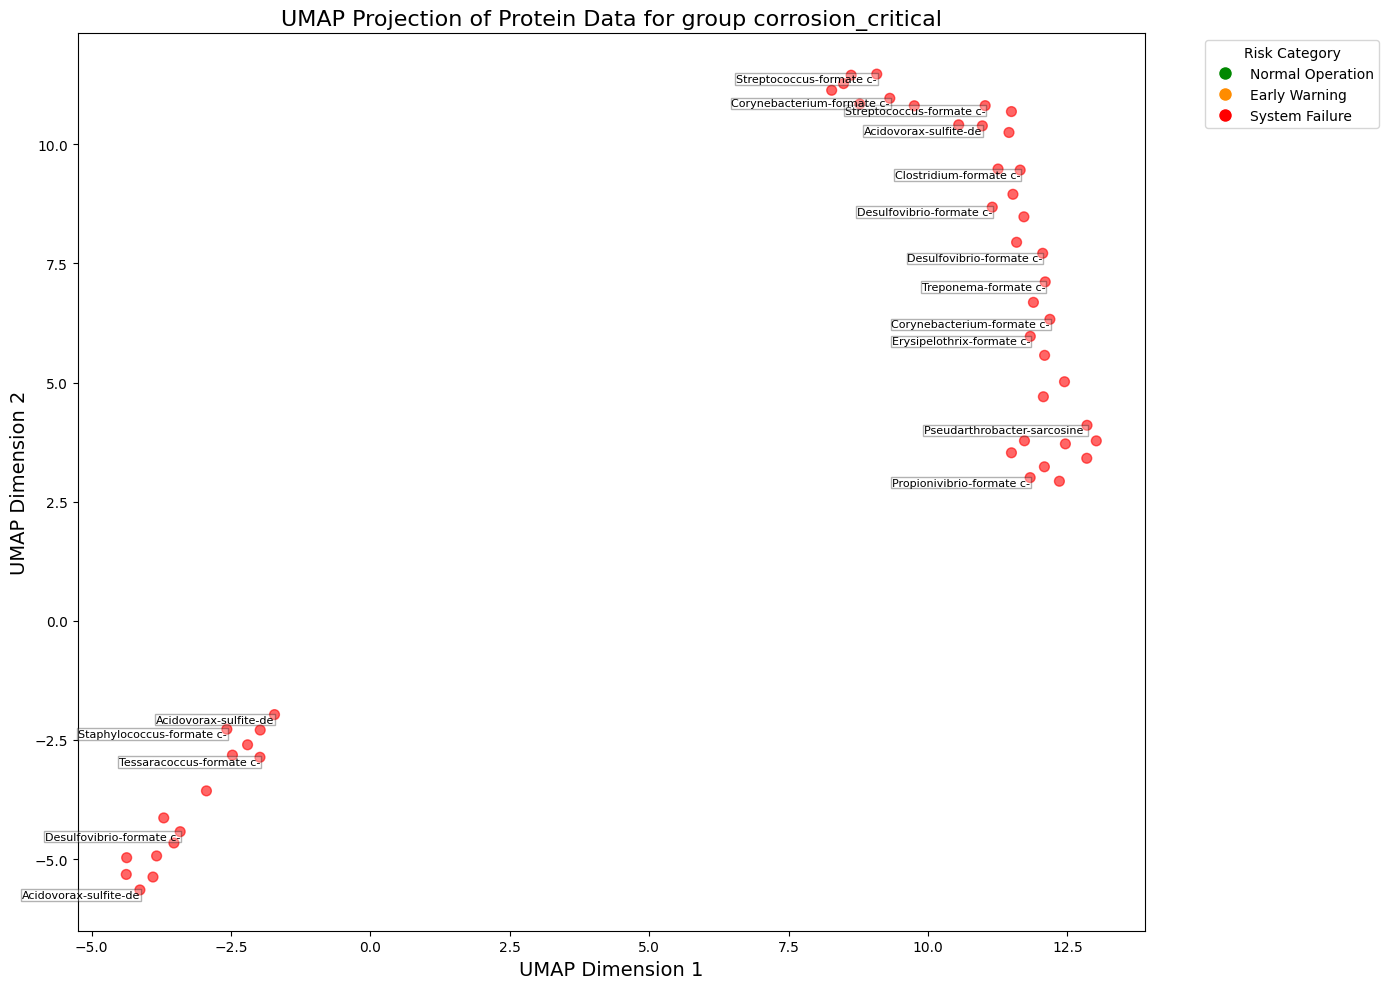

In [28]:
plot = create_simple_umap_visualization(corrosion_critical, "corrosion_critical", 50, n_neighbors=15, min_dist=0.1, point_size=50)
# Display the figure

umap_path = data_visual / "15_umap_corrosion_critical.png"
plt.savefig(umap_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

The UMAP (Uniform Manifold Approximation and Projection) visualization presented in the Figure 47 illustrates the dimensional reduction of 50 protein-genus pairs belonging to the corrosion-critical group. This dimensionality reduction technique effectively transforms the complex multivariate relationships between these pairs into a two-dimensional representation, allowing for the identification of potential clustering patterns and functional relationships.
Formate acetyltransferase FCT expression concentration creates a diagonal spread of sites capturing a single gradient of the protein expression and risk scalation from early colonizers to stablished corrosion communities. FCT is central to C1 metabolism, enabling organisms to utilize formate or CO2 and H2. In the pioneer species (Desulfovibrio, Desulfotomaculum) it reduces the redox balance allowing them to consume hydrogen or formate formed from the metal surface. Removal of H2 accelerates pitting Pioneer species expression of FCT indicates active metabolism linked to the Wood-Ljungdahl Pathway (WLP) (Ragsdale & Pierce, 2008) and the utilization of H2 or formate. The established corrosion communities (Clostridium, Staphylococcus, Corynebacterium) with biofilm environment often dominated by fermenters and acid-producers (acidogenesis). These organisms rely on the WLP to fix carbon and survive in the low-redox anaerobic environment created by the established biofilm. Transitional genera like Corynebacterium appear across both Category 2 and 3, differentiated only by abundance level confirming this is a continuous gradient, not a categorical shift. Pseudarthrobacter expressing sarcosine at the boundary of the advanced corrosion stage (System Failure) down left, far away from the early warning pairs, corresponds to C1 detoxification niche, which is a catabolic metabolism notably releasing formaldehyde a corrosive intermediate that further increases the toxicity and oxidative stress of the local environment (Imlay, 2003).

/home/beatriz/MIC/3_combined/.venv_combi/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



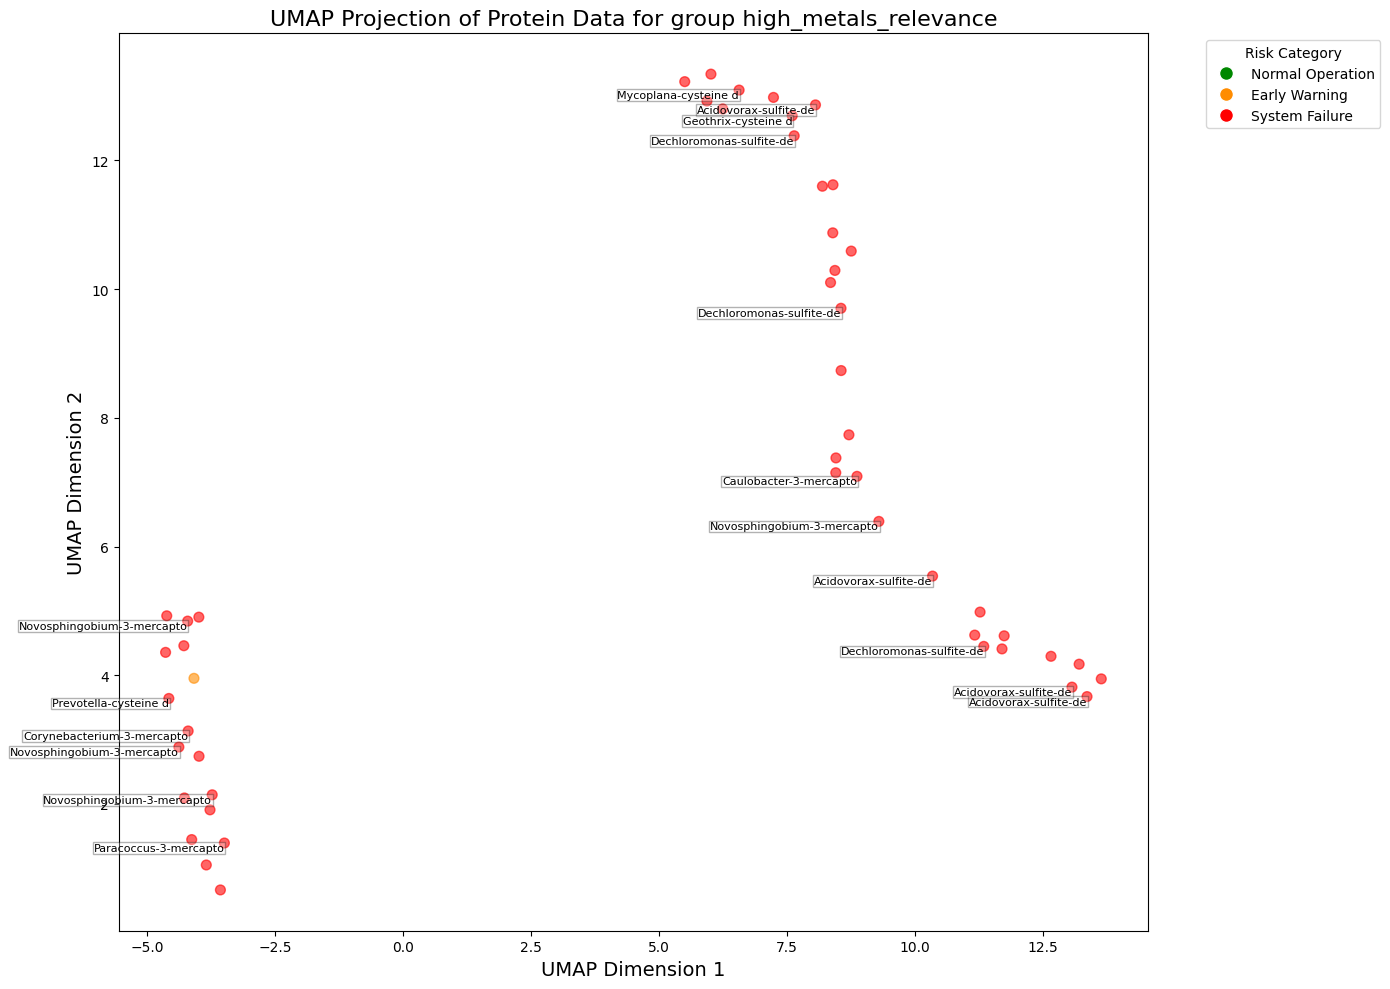

In [29]:
plot = create_simple_umap_visualization(high_metals_relevance, "high_metals_relevance", 50, n_neighbors=10, min_dist=0.1, point_size=50)
# Display the figure

umap_path = data_visual / "14_umap_high_metals_relevance.png"
plt.savefig(umap_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

There are two different not overlapping groups, suggesting two different main mechanims in play. THe FTC is in this group also the main driver and continue to have the same spacial distribution suggesting a sucession in abundance rather than in mechanisms. However the two differenciated groups could mean two different mechanism, more inferencia will be no really possible at this point.


## 3.10. Genus-functional category relationships with pathways annotations (fallback to functional_child)

In [30]:
def plot_functional_group_scatter(classified_results, name, top_n=None, max_genera=8):
    """    Create scatter plot showing genus-functional category relationships.
    Dot size = count of markers, dot color = pathway classification.
    Labels show pathway name (fallback to functional_child if pathway is NaN).
        Parameters:
        classified_results: DataFrame with classified pathways
        name: Name of the group for title
        top_n: Number of top markers to use (default: None = use all rows)
        max_genera: Maximum number of genera to display (default: 8)
    
    Returns:
        matplotlib figure
    """
    # make sure pathways are complete:
    if 'pathways' in classified_results.columns:
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)
    # Use all rows if top_n is None, otherwise take top N by score
    if top_n is not None:
        top_markers = classified_results.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = classified_results.sort_values('combined_score', ascending=False)
    
    # Validate we have data
    if top_markers.empty or 'functional_sub' not in top_markers.columns:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Filter to top N genera by average combined_score
    top_genera = top_markers.groupby('Genus')['combined_score'].mean().nlargest(max_genera).index.tolist() #max_genera
    top_markers = top_markers[top_markers['Genus'].isin(top_genera)]
    
    # Extract observed functional subcategories and genera
    functional_subs = sorted(top_markers['functional_sub'].dropna().unique())
    genera = sorted(top_genera)
    
    # Check if we have any data to plot
    if len(functional_subs) == 0 or len(genera) == 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No functional categories or genera found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Group by (Genus, functional_sub) and aggregate
    plot_data = []
    for genus in genera:
        genus_markers = top_markers[top_markers['Genus'] == genus]
        for func_sub in functional_subs:
            func_markers = genus_markers[genus_markers['functional_sub'] == func_sub]
            if len(func_markers) > 0:
                # Get pathway classification (most common)
                classification = func_markers['pathway_classification'].mode()[0] if len(func_markers['pathway_classification'].mode()) > 0 else 'unknown'
                
                # Get label: try pathway first, fallback to functional_child
                best_marker = func_markers.loc[func_markers['combined_score'].idxmax()]
                
                # Try pathway first
                label = ''
                if 'pathways' in func_markers.columns:
                    pathway = str(best_marker['pathways'])
                    if pd.notna(pathway) and pathway not in ['nan', '', 'None', '<NA>']:
                        label = pathway[:35]
                
                # Fallback to functional_child if pathway is empty
                if not label and 'functional_child' in func_markers.columns:
                    func_child = str(best_marker['functional_child'])
                    if pd.notna(func_child) and func_child not in ['nan', '', 'None', '<NA>']:
                        label = func_child[:30]
                
                count = len(func_markers)
                plot_data.append({
                    'genus': genus,
                    'functional_sub': func_sub,
                    'classification': classification,
                    'label': label,
                    'count': count
                })
    
    # Convert to DataFrame for easier plotting
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No valid combinations found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Dynamic figure width based on number of functional subcategories
    fig_width = max(10, len(functional_subs) * 2)
    fig_height = max(6, len(genera) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Color mapping for pathway classification
    color_map = {
        'universal': '#3498db',      # Blue
        'niche-specific': '#e67e22', # Orange
        'mixed': '#95a5a6',          # Gray
        'unknown': '#cccccc'         # Light gray
    }
    
    # Create numeric mappings for x and y axes
    func_sub_to_x = {cat: i for i, cat in enumerate(functional_subs)}
    genus_to_y = {g: i for i, g in enumerate(genera)}
    
    # Plot each point
    for classification in plot_df['classification'].unique():
        subset = plot_df[plot_df['classification'] == classification]
        x = [func_sub_to_x[fs] for fs in subset['functional_sub']]
        y = [genus_to_y[g] for g in subset['genus']]
        sizes = subset['count'] * 100  # Scale for visibility
        
        ax.scatter(x, y, s=sizes, c=color_map.get(classification, '#cccccc'),
                  alpha=0.6, edgecolors='black', linewidth=0.5,
                  label=classification, zorder=2)
    
    # Add labels on dots with alternating positions to reduce overlap
    for idx, row in plot_df.iterrows():
        if row['label']:  # Only annotate if label exists
            x = func_sub_to_x[row['functional_sub']]
            y = genus_to_y[row['genus']]
            
            # Alternate positions based on row index to reduce overlap
            if idx % 2 == 0:
                xytext = (6, 6)   # Upper right
            else:
                xytext = (6, -10)  # Lower right
                
            ax.annotate(row['label'], 
                       xy=(x, y), 
                       xytext=xytext,
                       textcoords='offset points',
                       fontsize=7,
                       alpha=0.8,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
                       zorder=3)
    
    # Set axis labels and ticks
    ax.set_xticks(range(len(functional_subs)))
    ax.set_xticklabels(functional_subs, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(genera)))
    ax.set_yticklabels(genera, fontsize=10)
    
    # Labels and title
    ax.set_xlabel('Functional Subcategory', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Genus (Top {max_genera} by Avg Score)', fontsize=12, fontweight='bold')
    
    # Title shows row count used
    title_suffix = f"Top {top_n} markers" if top_n else f"All {len(top_markers)} markers"
    ax.set_title(f'Genus-Functional Category Relationships: {name}\n({title_suffix}, dot size = count), Annotations: pathways (fallback functional_child)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # Legend
    legend = ax.legend(title='Annotations: pathways (fallback functional_child)', loc='lower right', bbox_to_anchor=(1, 0),
                      bbox_transform=fig.transFigure, frameon=True, fancybox=True, shadow=True)
    
    # Grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    ax.set_axisbelow(True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig

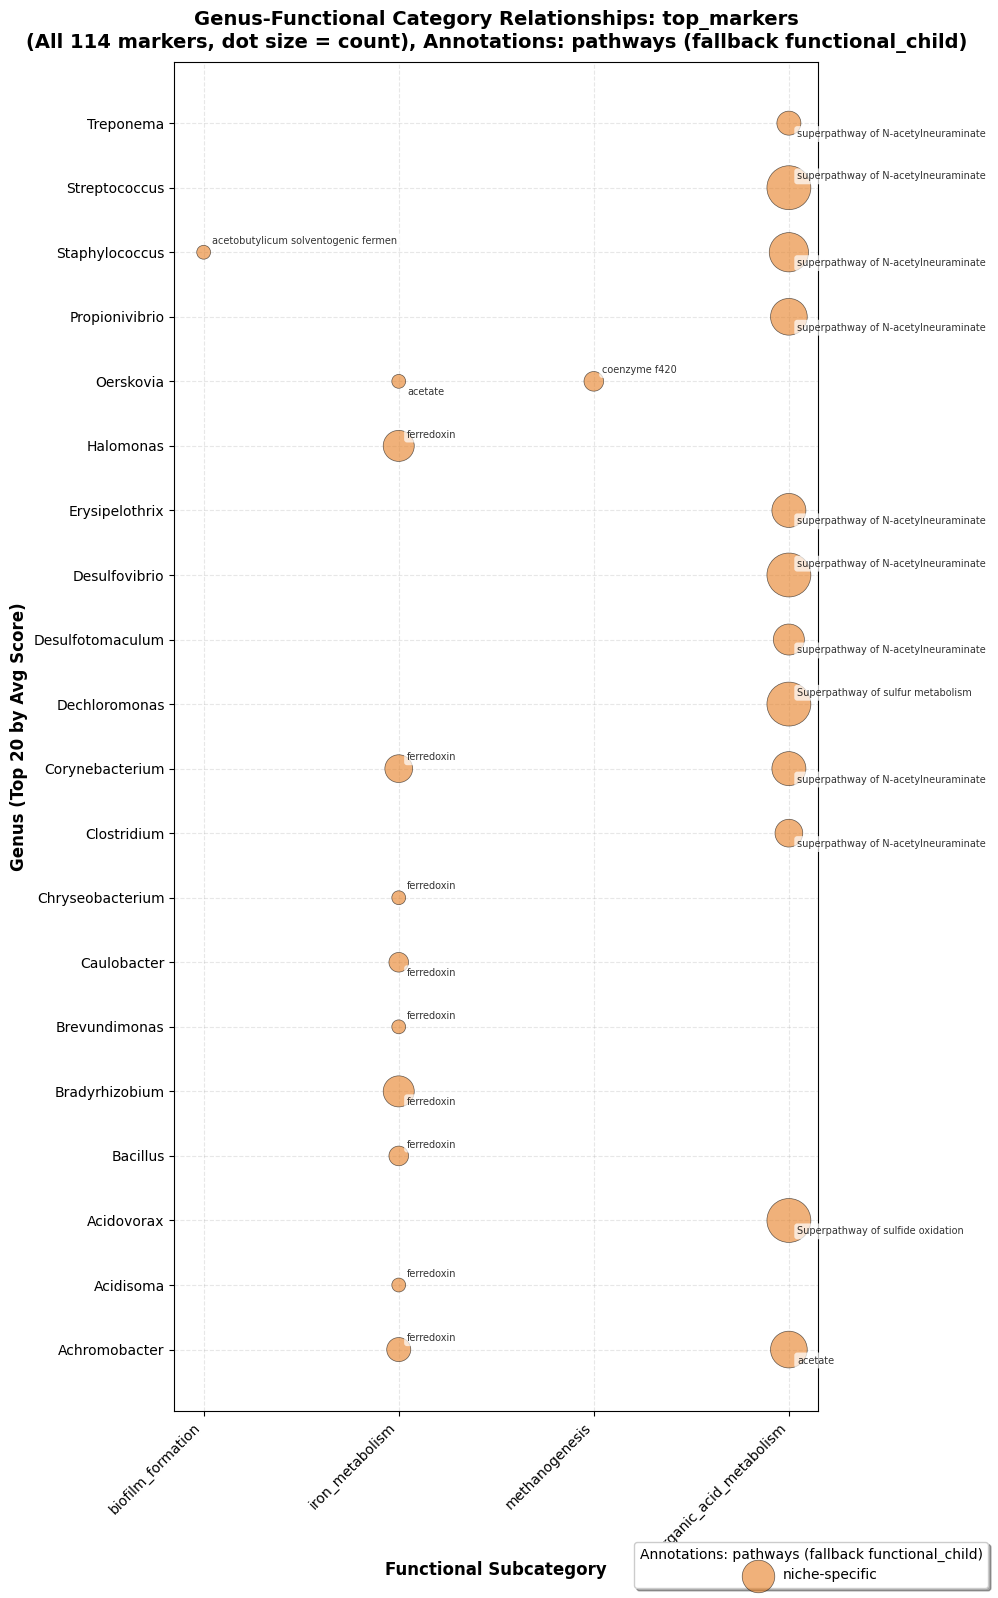

<Figure size 640x480 with 0 Axes>

In [31]:
fig = plot_functional_group_scatter(top_markers, "top_markers", max_genera=20)
plt.show()
opath = data_visual/"16_functional_pathways.png"
plt.savefig(opath, dpi=300, bbox_inches='tight')

Functional Specialization Analysis
Genus-functional category relationships with pathways annotations (fallback to functional_child) plot reveals the functional specialization strategies of the top 20 highest-scoring genera in the top markers group. Three functional categories dominate: biofilm formation, metal binding chelation, nitrogen metabolism and organic acid metabolism.
The genus-functional category relationships plot reveals the functional specialization strategies of the top 20 highest-scoring genera in the top markers group. Four functional categories dominate: biofilm formation, metal binding/chelation, nitrogen metabolism, and organic acid metabolism. The prevalence of alginate biosynthesis across nearly all genera (Novosphingobium, Propionibacterium, Desulfovibrio, Corynebacterium, etc.) reflects a fundamental survival strategy in corrosive environments. Biofilms create localized microenvironments where pH can differ by more than three units from the bulk phase, and the diffusional resistance of EPS makes it impossible to accurately assess acid concentration at the metal surface from bulk measurements (Javaherdashti, 2017). This universal adoption of alginate-based EPS production suggests convergent adaptation to industrial water conditions, as biofilm establishment fundamentally alters the interface chemistry where corrosion processes occur.

The superpathway of N-acetylneuraminic acid appearing in multiple genera (Treponema, Streptococcus, Staphylococcus, Desulfovibrio, Corynebacterium, Clostridium) indicates that metal chelation capability may be a prerequisite for persistence in these systems. The clustering of both known corrosion-associated bacteria (Desulfovibrio) and opportunistic colonizers aligns with established electrochemical principles of MIC where electron transfer mechanisms create microenvironments conducive to accelerated corrosion (Enning & Garrelfs, 2014).

The pathway diversification observed—L-1,2-propanediol degradation (Streptococcus), L-arabinose degradation (Oerskovia), Acetyl-CoA fermentation (Staphylococcus), and solventogenesis (Clostridium)—indicates multiple metabolic routes for organic acid production. This functional redundancy ensures continuous acidogenesis even as community composition shifts across corrosion categories, consistent with the M-MIC (metabolite MIC) mechanism where secreted organic acids oxidize metals extracellularly (Javaherdashti, 2017).

Nitrogen Metabolism Isolation: The singular representation of coenzyme F420 (associated with Oerskovia) suggests nitrogen metabolism occupies a specialized niche rather than being broadly distributed, potentially reflecting the limited availability of alternative electron acceptors in these industrial water systems

References
Enning, D., & Garrelfs, J. (2014). Corrosion of iron by sulfate-reducing bacteria: New views of an old problem. Applied and Environmental Microbiology, 80(4), 1226–1236. https://doi.org/10.1128/AEM.02848-13
Javaherdashti, R. (2017). Microbiologically influenced corrosion: An engineering insight (2nd ed.). Springer. https://doi.org/10.1007/978-3-319-44306-5


# 4. Proteins 
## 4.1. Protein Abundance Trajectories across risk categories

Fold change thresholds are standard practice (Love et al., 2014; DESeq2) the idea is to calculate which and how much the protein have an increase when changing the risk category from one lower to a high category. 
Reference
Love, M. I., Huber, W., & Anders, S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. Genome Biology, 15(12), 550. https://doi.org/10.1186/s13059-014-0550-8).

In [32]:
def plot_abundance_across_categories(marker_group, name, top_n=25, sort_by='combined_score'):
    """
    Plot abundance patterns across corrosion categories for top markers.
    Uses global term dictionaries and pre-calculated fold change columns.
    
    Parameters:
        marker_group: DataFrame containing marker data
        name: Name of the group for the title
        top_n: Number of top markers to display
        sort_by: Column name to sort markers by (default: 'combined_score')
        
    Returns:
        Plotly figure object with the abundance plot
    """
    # Make a copy to avoid modifying the original
    markers_df = marker_group.copy()
    
    # Get mean columns
    mean_cols = [col for col in markers_df.columns if col.startswith('mean_cat')]
    if not mean_cols:
        raise ValueError("No mean abundance columns found (should start with 'mean_cat')")
    
    # Sort and get top markers
    if sort_by in markers_df.columns:
        top_markers = markers_df.sort_values(sort_by, ascending=False).head(top_n)
    else:
        # If sort column not found, try combined_score, otherwise sort by first mean column
        if 'combined_score' in markers_df.columns:
            top_markers = markers_df.sort_values('combined_score', ascending=False).head(top_n)
        else:
            top_markers = markers_df.sort_values(mean_cols[0], ascending=False).head(top_n)
    
    # Extract category numbers from column names
    categories = [col.replace('mean_cat', 'Category ') for col in mean_cols]
    category_nums = [int(col.replace('mean_cat', '')) for col in mean_cols]
    
    # Create a list to store traces for each marker
    traces = []
    
    # Add trace for each marker
    for i, (_, row) in enumerate(top_markers.iterrows()):
        # Create shorter, more readable labels
        protein_name = row['protein_name'] if 'protein_name' in row else row.get('Marker', 'Unknown')
        if isinstance(protein_name, str) and len(protein_name) > 20:
            protein_name = protein_name[:25] + "..."
        
        # Add genus for better identification
        label = f"{row.get('Genus', 'Unknown')} - {protein_name}"
        
        # Get abundance values
        values = [row[col] for col in mean_cols]
        
        # Add trace with hover information
        hover_text = []
        for i, cat in enumerate(categories):
            hover_info = f"Category: {cat}<br>Abundance: {values[i]:.4f}"
            if 'Genus' in row:
                hover_info += f"<br>Genus: {row['Genus']}"
            
            # Add fold changes to hover info if available
            if 'fold_change_3vs1' in row and i == 2:  # For category 3
                hover_info += f"<br>FC vs Cat1: {row['fold_change_3vs1']:.2f}"
            if 'fold_change_2vs1' in row and i == 1:  # For category 2
                hover_info += f"<br>FC vs Cat1: {row['fold_change_2vs1']:.2f}"
            if 'fold_change_3vs2' in row and i == 2:  # For category 3
                hover_info += f"<br>FC vs Cat2: {row['fold_change_3vs2']:.2f}"
                
            # Add additional hover information if available

            if 'combined_score' in row:
                hover_info += f"<br>Score: {row['combined_score']:.2f}"    
            if 'pattern' in row:
                hover_info += f"<br>Pattern: {row['pattern']}"

            hover_text.append(hover_info)
        
        # Create trace for this marker
        trace = go.Scatter(
            x=category_nums,
            y=values,
            mode='lines+markers',
            name=label,
            line=dict(width=2),
            marker=dict(size=8),
            hovertext=hover_text,
            hoverinfo='text'
        )
        
        traces.append(trace)
    
    # Create figure
    fig = go.Figure(data=traces) 
    fig.update_layout(title=f'Abundance Patterns of Group {name} Across Corrosion Categories (Top {top_n} Markers)', xaxis=dict(tickfont=dict(size=18, family="Arial"), tickmode='array', tickvals=category_nums, ticktext=categories, domain=[0, 1]), yaxis=dict(title=dict(text='Mean Abundance', font=dict(size=14))), legend=dict(orientation="h", yanchor="bottom", y=-0.8, xanchor="center", x=0.5), margin=dict(t=100, b=150, l=100, r=100), height=700, width=1000, hovermode='closest', annotations=[dict(x=0.5, y=1.05, xref="paper", yref="paper", text="Corrosion Category", showarrow=False, font=dict(size=14))])

    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    
    return fig

In [33]:
abun= plot_abundance_across_categories(top_markers, "top_markers",  top_n=20, sort_by='combined_score')
output_path= data_visual /"18_increase.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
abun.show()

<Figure size 640x480 with 0 Axes>

Ploting the abundance patterns across corrosion categories for fold changes 1 to 2 to 3. The protein being expressed is consistently the same for groups top_markers, core corrosion and high corrosion. Formate c acetyltransferase catalyze the process of acetylation, which is a transfer reaction.
Acetyl-CoA+Substrate⟶CoA+Acetyl-Substrate. Ultimately forming formate which is a strong organic acid driving corrosion.

## 4.2 Protein-Group Heatmap which proteins rank highest in which groups 

In [34]:
def plot_protein_importance_heatmap(groups_dict, top_n_proteins=30, top_n_per_group=50):
    """
    Create heatmap showing which proteins are important across different marker groups.
    
    Parameters:
        groups_dict: Dictionary of {group_name: DataFrame}
        top_n_proteins: Number of unique proteins to show (rows)
        top_n_per_group: Top N markers to consider from each group
        
    Returns:
        matplotlib figure
    """   
    # Collect protein rankings across all groups
    protein_ranks = {}
    
    for group_name, group_df in groups_dict.items():
        # Sort by combined_score and get top N
        sorted_group = group_df.sort_values('combined_score', ascending=False).head(top_n_per_group)
        
        # Create protein identifier (genus + protein_name)
        sorted_group['protein_id'] = sorted_group['Genus'] + ' - ' + sorted_group['protein_name'].str[:20]
        
        # Assign ranks (1 = highest score)
        for rank, (idx, row) in enumerate(sorted_group.iterrows(), start=1):
            protein_id = row['protein_id']
            if protein_id not in protein_ranks:
                protein_ranks[protein_id] = {}
            protein_ranks[protein_id][group_name] = rank
    
    # Convert to DataFrame
    rank_df = pd.DataFrame(protein_ranks).T.fillna(top_n_per_group + 1)  # Non-present = worst rank
    
    # Get proteins that appear in most groups
    protein_appearances = (rank_df < top_n_per_group).sum(axis=1)
    top_proteins = protein_appearances.nlargest(top_n_proteins).index
    
    # Filter to top proteins
    plot_df = rank_df.loc[top_proteins]
    
    # Invert ranks for visualization (lower rank = darker color = more important)
    plot_df = top_n_per_group + 1 - plot_df
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, max(8, len(top_proteins) * 0.4)))
    
    # Create heatmap
    sns.heatmap(plot_df, cmap='YlOrRd', linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'Importance (darker = higher rank)'},
                ax=ax, vmin=1, vmax=top_n_per_group)
    
    ax.set_title(f'Protein Importance Across Marker Groups\n(Top {top_n_proteins} proteins by group prevalence)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Marker Group', fontsize=12, fontweight='bold')
    ax.set_ylabel('Protein (Genus - Name)', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    
    # Print summary
    print(f"\n=== Protein Distribution Summary ===")
    print(f"Total unique proteins across all groups: {len(protein_ranks)}")
    print(f"\nProteins appearing in most groups:")
    for protein, count in protein_appearances.nlargest(10).items():
        print(f"  {protein}: {count}/{len(groups_dict)} groups")
    
    return fig


=== Protein Distribution Summary ===
Total unique proteins across all groups: 63

Proteins appearing in most groups:
  Tessaracoccus - formate c-acetyltran: 16/18 groups
  Staphylococcus - formate c-acetyltran: 16/18 groups
  Propionivibrio - formate c-acetyltran: 16/18 groups
  Clostridium - formate c-acetyltran: 16/18 groups
  Corynebacterium - formate c-acetyltran: 16/18 groups
  Treponema - formate c-acetyltran: 16/18 groups
  Desulfomicrobium - formate c-acetyltran: 16/18 groups
  Erysipelothrix - formate c-acetyltran: 16/18 groups
  Desulfotomaculum - formate c-acetyltran: 16/18 groups
  Desulfovibrio - formate c-acetyltran: 16/18 groups


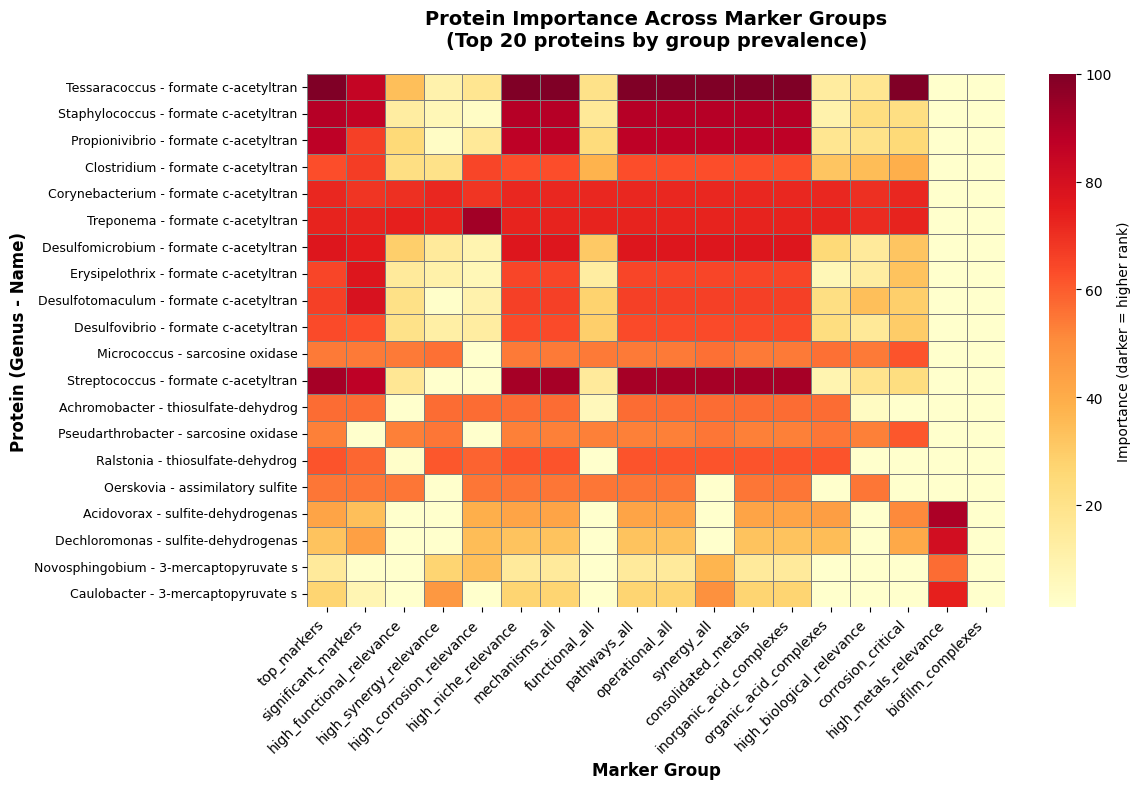

In [35]:
# Supergroups dictionary
groups_dict = {
    'top_markers': top_markers,
    'significant_markers': significant_markers,
    'high_metals_relevance': high_metals_relevance,
    'high_functional_relevance': high_functional_relevance,
    'high_synergy_relevance': high_synergy_relevance,
    'high_corrosion_relevance': high_corrosion_relevance,
    'high_niche_relevance': high_niche_relevance,
    'mechanisms_all': mechanisms_all,
    'functional_all': functional_all,
    'pathways_all': pathways_all,
    'operational_all': operational_all,
    'synergy_all': synergy_all,
    'consolidated_metals': consolidated_metals,
    'inorganic_acid_complexes': inorganic_acid_complexes,
    'organic_acid_complexes': organic_acid_complexes,
    'biofilm_complexes': biofilm_complexes,
    'high_biological_relevance': high_biological_relevance,
    'corrosion_critical': corrosion_critical
}

fig = plot_protein_importance_heatmap(groups_dict, top_n_proteins=20, top_n_per_group=100)
plt.show()

As can be seen in this plot there are redundancy on the information provided by symilar groups [pathways_all, consolidated_metals, funcional all, etc] all produce similar data, then there is another groups like high functional relevance and high biological relevance that also tell similar story. Ultimately the groups would be consolidated so that only some groups would be identify and consolidate the groups on 2-4.

## 4.3. Group Consolidation via Similarity Clustering
Here groups are reduce by identifying which ones tell the same biological story. This is a group similarity problem, no protein importance

In [36]:
def analyze_group_similarity_clustering(groups_dict, top_n_per_group=50, method='average'):
    """
    Cluster marker groups based on protein overlap to identify redundant groups
    and suggest consolidated super-groups.
    
    Parameters:
        groups_dict: Dictionary of {group_name: DataFrame}
        top_n_per_group: Number of top markers to consider from each group
        method: Clustering linkage method ('average', 'complete', 'single', 'ward')
    
    Returns:
        fig: matplotlib figure with dendrogram
        similarity_matrix: DataFrame showing pairwise Jaccard similarities
        cluster_assignments: DataFrame showing which groups belong to which cluster
    """
    
    # Extract top proteins from each group
    group_proteins = {}
    
    for group_name, group_df in groups_dict.items():
        # Sort by combined_score and get top N
        sorted_group = group_df.sort_values('combined_score', ascending=False).head(top_n_per_group)
        
        # Create protein identifier (genus + protein_name)
        protein_ids = set(sorted_group['Genus'] + ' - ' + sorted_group['protein_name'])
        
        group_proteins[group_name] = protein_ids
        print(f"{group_name}: {len(protein_ids)} unique proteins")
    
    # Calculate Jaccard similarity matrix
    group_names = list(group_proteins.keys())
    n_groups = len(group_names)
    similarity_matrix = np.zeros((n_groups, n_groups))
    
    for i, group1 in enumerate(group_names):
        for j, group2 in enumerate(group_names):
            if i == j:
                similarity_matrix[i, j] = 1.0
            else:
                proteins1 = group_proteins[group1]
                proteins2 = group_proteins[group2]
                
                # Jaccard similarity: intersection / union
                intersection = len(proteins1 & proteins2)
                union = len(proteins1 | proteins2)
                
                similarity_matrix[i, j] = intersection / union if union > 0 else 0
    
    # Convert similarity to distance for clustering
    distance_matrix = 1 - similarity_matrix
    
    # Convert to condensed distance matrix for scipy
    condensed_dist = squareform(distance_matrix)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method=method)
    
    # Create dendrogram
    fig, ax = plt.subplots(figsize=(14, 8))
    
    dendrogram(
        linkage_matrix,
        labels=group_names,
        ax=ax,
        leaf_rotation=5,
        leaf_font_size=7, 
        color_threshold=0.001  # Can adjust this to see different cut levels 0.01-0.5
    )

    ax.set_title(f"Hierarchical Clustering of Marker Groups\n(Based {top_n_per_group} Protein Overlap)", 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Marker Group', fontsize=12, fontweight='bold')
    ax.set_ylabel('Distance (1 - Jaccard Similarity)', fontsize=12, fontweight='bold')
    
    # Add horizontal lines showing potential cut points for 3, 4, 5 clusters
    heights = linkage_matrix[:, 2]
    
    # Find distances that would give 3, 4, 5 clusters
    for n_clusters in [3, 4, 5]:
        if n_groups > n_clusters:
            # Get the merge height for n_clusters
            cut_height = heights[-(n_clusters-1)]
            ax.axhline(y=cut_height, color='red', linestyle='--', alpha=0.4, linewidth=1)
            ax.text(0.02, cut_height, f'{n_clusters} clusters',
                   transform=ax.get_yaxis_transform(), fontsize=7, color='red')
    
    plt.tight_layout()
    
    # Create similarity DataFrame for inspection
    similarity_df = pd.DataFrame(similarity_matrix, 
                                 index=group_names, 
                                 columns=group_names)
    
    # Generate cluster assignments for 3, 4, and 5 clusters
    print("\n=== SUGGESTED CLUSTER ASSIGNMENTS ===\n")
    
    cluster_results = {}
    for n_clusters in [3, 4, 5]:
        if n_groups > n_clusters:
            clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            print(f"--- {n_clusters} Clusters ---")
            cluster_dict = {}
            for cluster_id in range(1, n_clusters + 1):
                members = [group_names[i] for i, c in enumerate(clusters) if c == cluster_id]
                cluster_dict[f"Cluster_{cluster_id}"] = members
                print(f"Cluster {cluster_id} ({len(members)} groups):")
                for member in members:
                    print(f"  - {member}")
                print()
            
            cluster_results[n_clusters] = cluster_dict
    
    # Print highest similarity pairs to understand groupings
    print("\n=== HIGHEST SIMILARITY PAIRS ===")
    similarity_pairs = []
    for i in range(n_groups):
        for j in range(i+1, n_groups):
            similarity_pairs.append((group_names[i], group_names[j], similarity_matrix[i, j]))
    
    similarity_pairs.sort(key=lambda x: x[2], reverse=True)
    
    for group1, group2, sim in similarity_pairs[:10]:
        print(f"{group1} <-> {group2}: {sim:.3f} ({sim*100:.1f}% overlap)")
    
    return fig, similarity_df, cluster_results

top_markers: 32 unique proteins
significant_markers: 31 unique proteins
high_metals_relevance: 35 unique proteins
high_functional_relevance: 20 unique proteins
high_synergy_relevance: 29 unique proteins
high_corrosion_relevance: 20 unique proteins
high_niche_relevance: 32 unique proteins
mechanisms_all: 32 unique proteins
functional_all: 20 unique proteins
pathways_all: 32 unique proteins
operational_all: 32 unique proteins
synergy_all: 31 unique proteins
consolidated_metals: 32 unique proteins
inorganic_acid_complexes: 32 unique proteins
organic_acid_complexes: 20 unique proteins
biofilm_complexes: 6 unique proteins
high_biological_relevance: 20 unique proteins
corrosion_critical: 15 unique proteins

=== SUGGESTED CLUSTER ASSIGNMENTS ===

--- 3 Clusters ---
Cluster 1 (16 groups):
  - top_markers
  - significant_markers
  - high_functional_relevance
  - high_synergy_relevance
  - high_corrosion_relevance
  - high_niche_relevance
  - mechanisms_all
  - functional_all
  - pathways_all
  

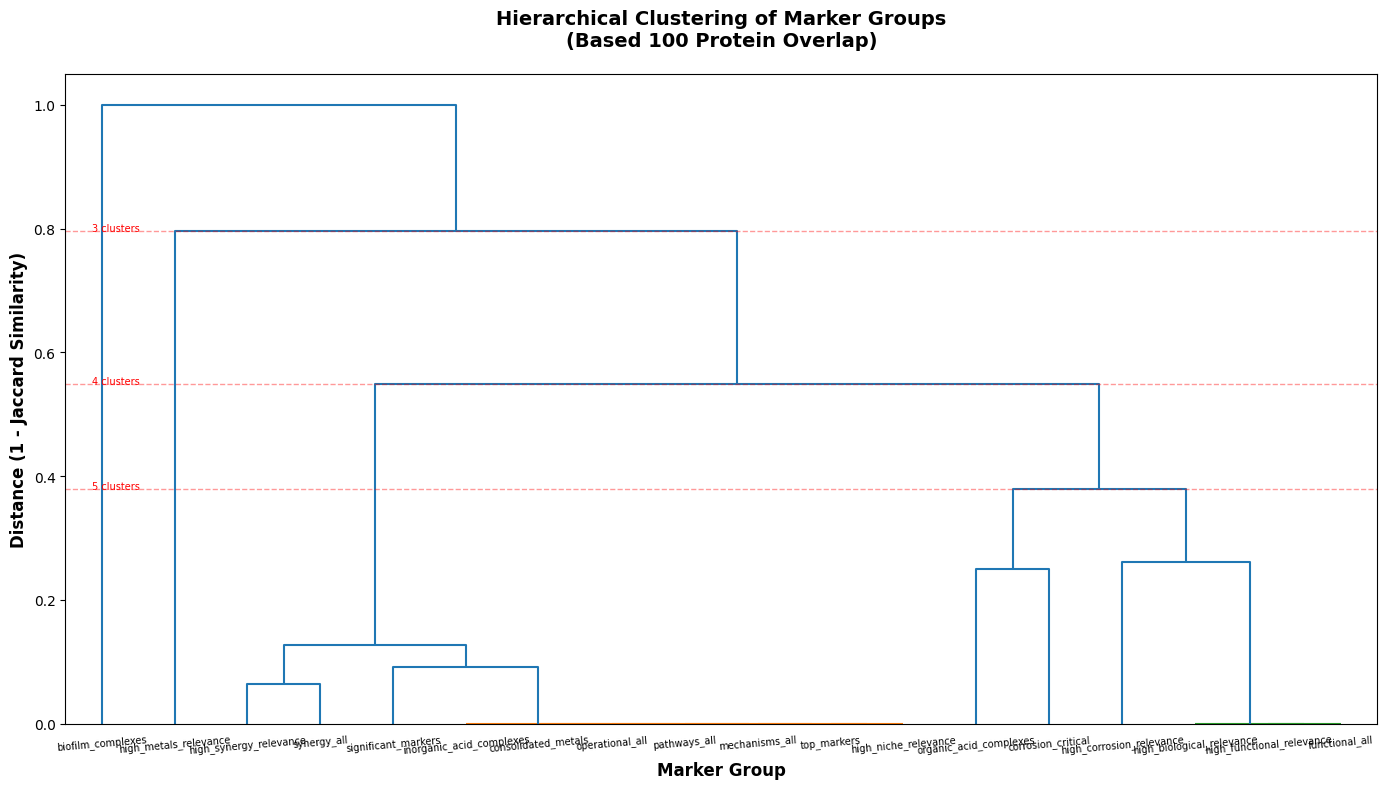


=== FULL SIMILARITY MATRIX ===
                           top_markers  significant_markers  \
top_markers                1.000        0.909                 
significant_markers        0.909        1.000                 
high_metals_relevance      0.314        0.320                 
high_functional_relevance  0.444        0.417                 
high_synergy_relevance     0.906        0.818                 
high_corrosion_relevance   0.486        0.500                 
high_niche_relevance       1.000        0.909                 
mechanisms_all             1.000        0.909                 
functional_all             0.444        0.417                 
pathways_all               1.000        0.909                 
operational_all            1.000        0.909                 
synergy_all                0.853        0.824                 
consolidated_metals        1.000        0.909                 
inorganic_acid_complexes   1.000        0.909                 
organic_acid_complexes 

<Figure size 640x480 with 0 Axes>

In [37]:
fig, similarity_matrix, cluster_results = analyze_group_similarity_clustering(groups_dict, top_n_per_group=100, method='average')# average, single
plt.show()
output_path= data_visual /"10_hierarchi_group.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

# To see the full similarity matrix
print("\n=== FULL SIMILARITY MATRIX ===")
print(similarity_matrix.round(3))

## 4.4. Groups Consolidation Strategy 
In order to regroup in supergroups it is possible to do it by protein which ultimately has been seen to be the critical driver of corrosion identity, however in the microbial ecology context same protein in differnt genera represent different community members performing that function. For instance sarcosine oxidase in Micrococcus is an aerobic and biofilm-former, whiles same protein sarcosine oxidase in Pseudomonas is report as being facultative and  planktonic in escence. These are NOT interchangeable from an ecological perspective. Ultimately, for corrosion biomarks it is required the tracking of the organism in question, so that it could be better specificity, identity and managble.
However make no mistake, these already classified and filtered groups are curated and because of that it is expected that that protein-genus are similar and in consequence implies a definitive similarity on metabolism : prior filtering validates functional equivalence. consolidated_metals: "Which proteins handle multiple corrosion-relevant metals?"

cluster analysis:
|                        Cluster Members                   |                        Thematic Grouping                                                  | 
| :---------------------------------------------------------: | :------------------------------------------------------------------------------------- | 
|Cluster 1 (1 groups) : biofilm_complexes | Unique proteins, likely includes large, diverse structural genes (like EPS or cell wall components) that are distinct from the smaller metabolic/redox proteins driving the other groups.|  
|Cluster 2 (1 group): high_metal_relevance |high relevance scores to metal binding or transformation. |
|Cluster 3 (2 groups)--> synergy_control : high_synergy_relevance, synergy_all |--|
|Cluster 4 (8 groups)--> broad_corrosion: top_markers, significant_markers, high_niche_relevance, mechanisms_all,pathways_all, operational_all, consolidated_metals, inorganic_acid_complexes| This group is the Highly Redundant. All members have 100 % overlap in their top 50 proteins.|  
|Cluster 5 (2 groups)--> core_corrosion : organic_acid_complexes, corrosion_critical|--|
|Cluster 6 (2 groups)--> bio_functional: high_functional_relevance, high_corrosion_relevance, functional_all, high_biological_relevance |This group focuses on the functional role of the genes. It separates groups explicitly related to general biological/functional importance |


In [38]:
def create_consolidated_supergroups(groups_dict, balanced_markers):
    """ Merge redundant groups into consolidated super-groups.
    Parameters:   groups_dict: dict of individual DataFrames (group_name -> DataFrame)
        balanced_markers: original balanced_markers DataFrame (not modified)
    Returns:  supergroups: dict with keys:- biofilm_structural- broad_metabolic- synergy_group- core_corrosion- metal_specific- pathway_specific    """
    supergroups = {}

    # Helper to safely concat a list of group names -> list of DataFrames
    def _concat_groups(names):
        dfs = [groups_dict[g] for g in names if g in groups_dict and groups_dict[g] is not None]
        return pd.concat(dfs, ignore_index=False) if dfs else None
    
    # SUPERGROUP 3: synergy group
    synergy =['high_synergy_relevance','synergy_all']
    sg_con = _concat_groups(synergy)
    if sg_con is not None:
        supergroups['synergy_control'] = sg_con.drop_duplicates(subset=['idx'])
    # SUPERGROUP 4: broad corrosion drivers
    broad_names = ['top_markers', 'significant_markers', 'high_niche_relevance', 'mechanisms_all', 'pathways_all', 'operational_all', 'consolidated_metals', 'inorganic_acid_complexes']
    sg_met = _concat_groups(broad_names)
    if sg_met is not None:
        supergroups['broad_corrosion'] = sg_met.drop_duplicates(subset=['idx'])
    # SUPERGROUP 5: core corrosion drivers
    core_names = ['organic_acid_complexes', 'corrosion_critical']
    sg_path = _concat_groups(core_names)
    if sg_path is not None:
        supergroups['core_corrosion'] = sg_path.drop_duplicates(subset=['idx'])
   
    # SUPERGROUP 6: bio_functional drivers 
    high_names = ['high_functional_relevance', 'high_corrosion_relevance', 'functional_all', 'high_biological_relevance']
    sg_core = _concat_groups(high_names)
    if sg_core is not None:
        supergroups['bio_functional'] = sg_core.drop_duplicates(subset=['idx'])

    return supergroups

In [39]:
supergroups = create_consolidated_supergroups(groups_dict, balanced_markers)
# calling each of the groups individually
core_corrosion = supergroups.get('core_corrosion', pd.DataFrame())
broad_corrosion = supergroups.get('broad_corrosion', pd.DataFrame())
bio_functional = supergroups.get('bio_functional', pd.DataFrame())
synergy_control = supergroups.get('synergy_control', pd.DataFrame())

## 4.5 Three-panel plot showing functional categories for each risk category's sites

In [40]:
def plot_functional_by_site_category(prioritized_markers, name):
    """Three-panel plot showing functional categories for each risk category's sites"""
    
    df = prioritized_markers.copy()
    
    # Ensure Category column exists
    if 'Category' not in df.columns:
        df['Category'] = df['Sites'].map(category_dict)
    
    # Validate all sites have categories
    if df['Category'].isna().any():
        missing_sites = df[df['Category'].isna()]['Sites'].unique()
        print(f"Warning: Sites missing from category_dict: {missing_sites}")
        df = df.dropna(subset=['Category'])
    
    df['Category'] = df['Category'].astype(int)
    
    # Collect data by site and category
    site_data = []
    
    for _, row in df.iterrows():
        site = row['Sites']
        category = row['Category']
        func_cat = row.get('functional_sub', '')
        
        if pd.notna(func_cat) and func_cat:
            # Use the abundance column matching this site's category
            abundance = row.get(f'mean_cat{category}', 0)
            
            site_data.append({
                'Site': site,
                'Category': category,
                'functional_cat': func_cat,
                'abundance': abundance
            })
    
    if not site_data:
        print("No functional_sub data available")
        return None
    
    site_df_agg = pd.DataFrame(site_data)
    
    # Create 3-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    
    category_colors = {1: '#2E7D32', 2: '#F57C00', 3: '#D32F2F'}
    category_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    for i, cat in enumerate([1, 2, 3]):
        cat_data = site_df_agg[site_df_agg['Category'] == cat]
        
        if len(cat_data) == 0:
            axes[i].text(0.5, 0.5, f'No sites in Category {cat}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"{category_labels[cat]}\n(0 sites)")
            continue
        
        # Aggregate by functional category
        func_agg = cat_data.groupby('functional_cat')['abundance'].sum().sort_values(ascending=False).head(15)
        
        axes[i].barh(func_agg.index, func_agg.values, color=category_colors[cat])
        axes[i].set_title(f"{category_labels[cat]}\n({len(cat_data['Site'].unique())} sites)", fontsize=12)
        axes[i].set_xlabel('Total Abundance', fontsize=10)
        axes[i].tick_params(axis='y', labelsize=9)
        
        # Add value labels
        for idx, (func, val) in enumerate(func_agg.items()):
            axes[i].text(val + 0.02, idx, f'{val:.2f}', 
                        va='center', fontsize=8)
        
        if i == 0:
            axes[i].set_ylabel('Functional Category', fontsize=10)
    
    plt.suptitle(f"Functional Categories by Site Risk Category: {name}", fontsize=14, y=0.98)
    plt.tight_layout()
    return fig

/tmp/ipykernel_452/4197808108.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



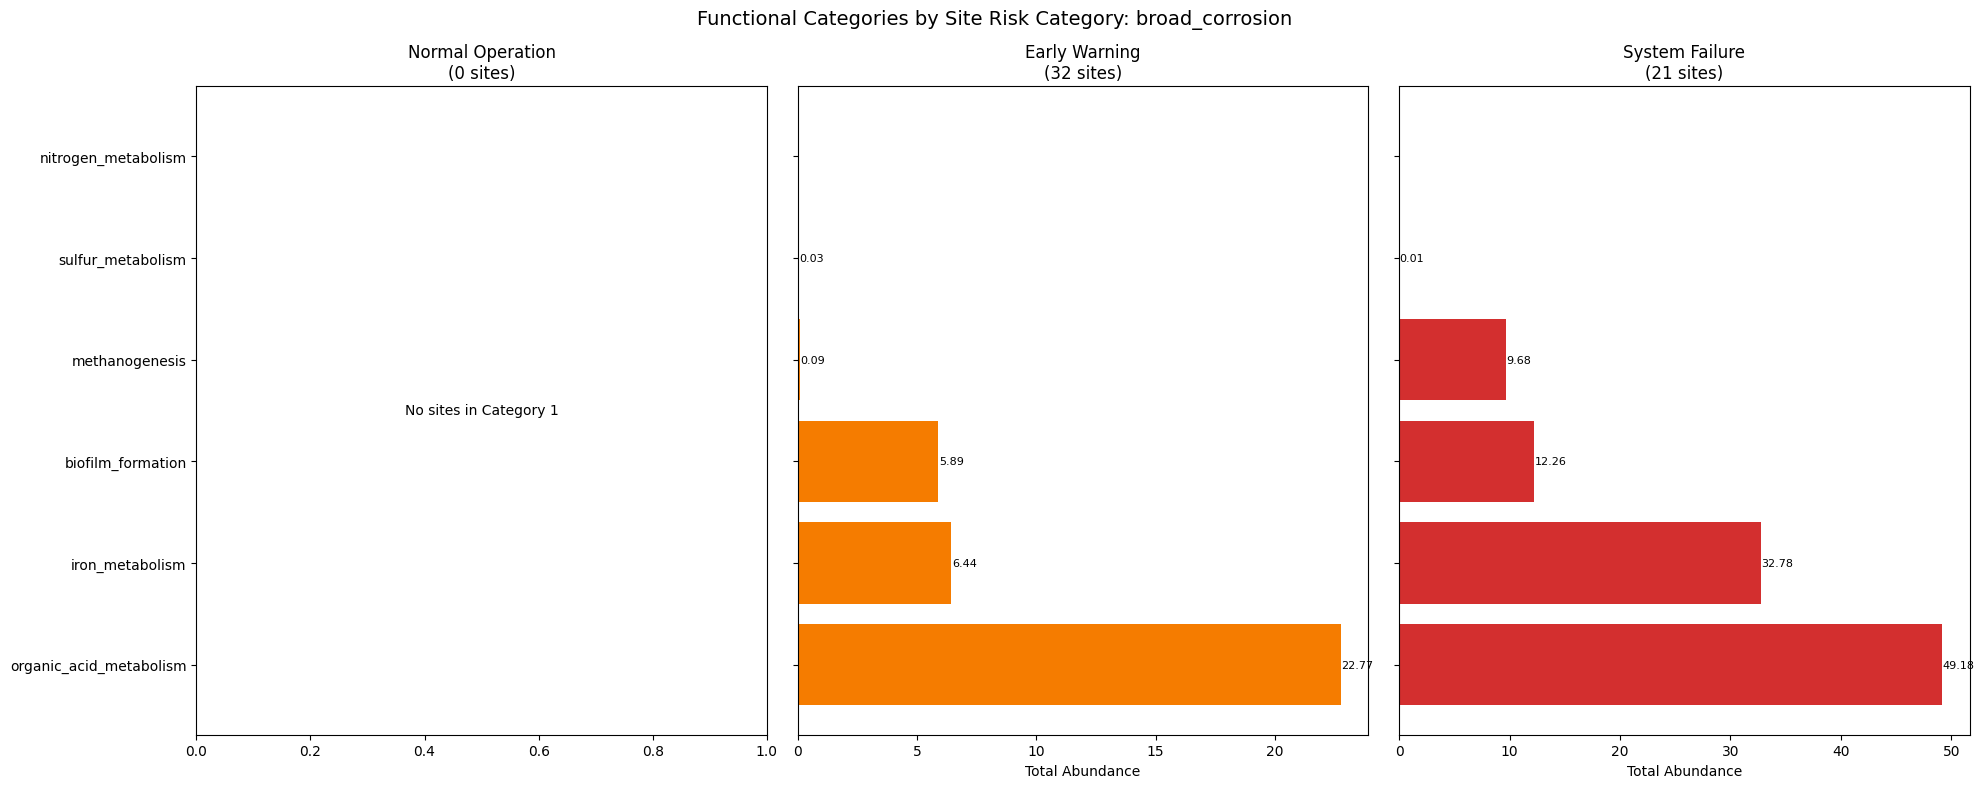

In [41]:
fig_12 = plot_functional_by_site_category(broad_corrosion, 'broad_corrosion')
fc_path = data_visual / "12_func.png"
plt.savefig(str(fc_path), dpi=300, bbox_inches='tight')
fig_12.show()

This three-panel plot shows functional categories for each risk category's sites. Analysing broad corrosion group, organic acid metabolism in system failure risk category duplicates, whiles iron metabolism increases 5 times, biofilm formation also duplicates and the methanogenesis is very much only existing on system failure. All metabolisms have the most dramatic presence on category 3. These are not absolute values and the reader must remain that this study relies on mined data from the databases and could contain errors, however the results seem consistent with these environments.

## 4.6. Top Protein Heatmap

In [42]:
def plot_top_protein_heatmap(df, name, top_proteins=20):
    # Sort by preferred significance metric
    top_proteins = df.sort_values(by='combined_score', ascending=False).head(top_proteins)

    # Select mean value columns for heatmap
    heatmap_data = top_proteins[['mean_cat1', 'mean_cat2', 'mean_cat3']]

    # Truncate long protein names for better visualization
    #truncated_names = top_proteins['protein_name'].apply(lambda x: x if len(x) <= 80 else x[:25] + '...')

    # Create heatmap
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap='viridis',
        yticklabels=top_proteins['protein_name'], #truncated_names,  # Use truncated names
        xticklabels=['Category 1', 'Category 2', 'Category 3']
    )

    plt.title(f" {name} Top Protein Expression Heatmap across Risk Category")
    plt.ylabel("Proteins")
    plt.xlabel("Risk Category")

    # Use tight_layout to minimize empty space
    plt.tight_layout()

    return plt.gcf()

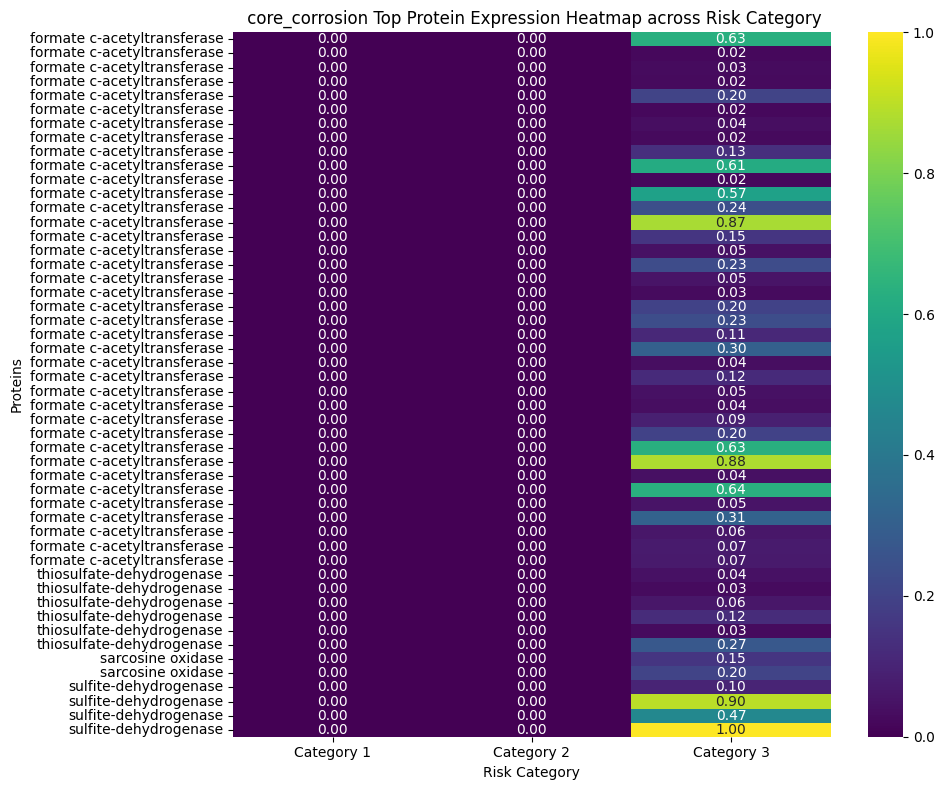

<Figure size 640x480 with 0 Axes>

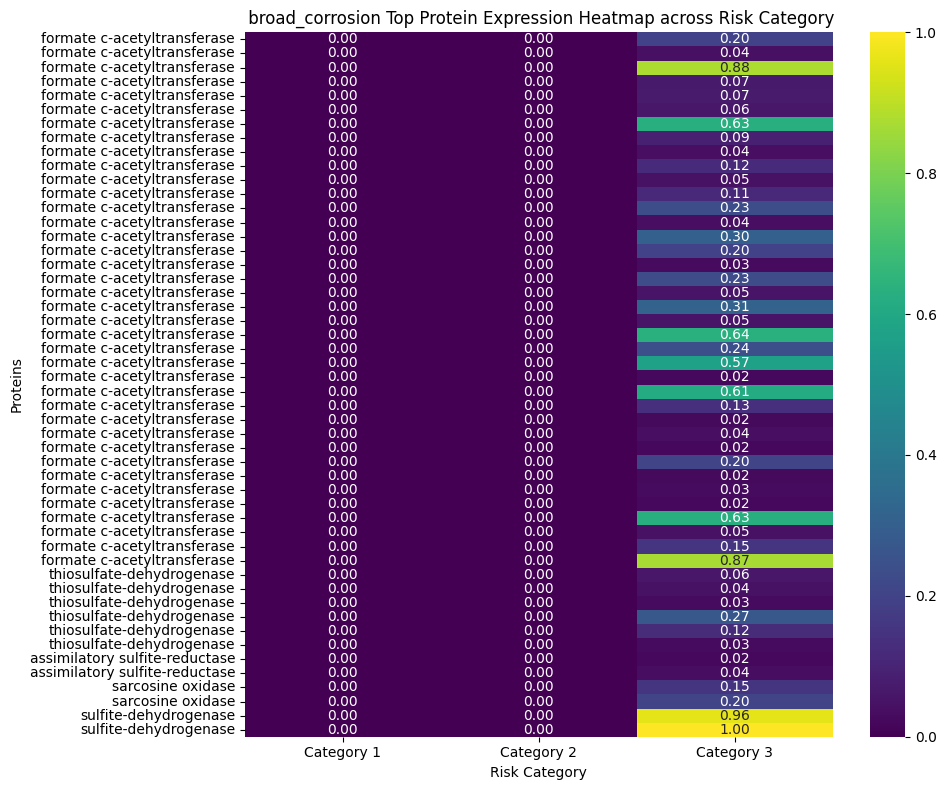

<Figure size 640x480 with 0 Axes>

In [43]:
plot_top_protein_heatmap(core_corrosion, "core_corrosion", 50)
plt.show()
output_path= data_visual /"20_core_protein.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plot_top_protein_heatmap(broad_corrosion, "broad_corrosion", 50)
plt.show()
output_path= data_visual /"21_broad_protein.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

The heatmaps demonstrate that different genera express different metabolic enzymes but converge on the same corrosion-critical proteins at high abundance, validating that substrate utilization capacity depends on expressed protein concentration, not encoded pathway potential. This shifts prevention strategy from targeting specific bacterial taxa or metabolic pathways toward disrupting the expression or function of the convergent protein set that all successful corrosion communities must deploy regardless of their metabolic route to failure. 
There are persistent proteins that are common to several groups and hence are important:
    Formate C-acetyltransferase: core_corrosion, high_corrosion, high_metal_relevance; Assimilatory sulfite reductase: core_corrosion, high_corrosion; high_metal_relevance; Sarcosine oxidase: organic_acid_complexes, high_corrosion, high_metal_relevance; Malate synthase: organic_acid_complexes, high_corrosion

Group-Specific Proteins (unique to one group): Biofilm_complexes: pullulanase, ferredoxin-thioredoxin reductase, serine O-acetyltransferase
Organic_acid_complexes: aldehyde ferredoxin oxidoreductase, glycerol dehydrogenase, pyruvate carboxylase

The redundancy pattern reveals a hierarchical organization of corrosion-relevant functions:

Core metabolic hub (formate C-acetyltransferase, assimilatory sulfite reductase) could represent the fundamental electron flow pathways. Formate C-acetyltransferase enables anaerobic pyruvate metabolism, producing formate which subsequently contributes to cathodic depolarization when oxidized by formate-utilizing organisms or enzymes in the biofilm consortium. While assimilatory sulfite reductase links sulfur cycling to energy metabolism—both central to MIC electrochemistry. ASR reduces sulfite (SO3-2​) to sulfide (S-2) this sulfite produce H2S highly corrosive which compromise Fe as FeS. (Enning & Garrelfs, 2014).

Organic acid production cluster (sarcosine oxidase, malate synthase, pyruvate carboxylase, glycerol dehydrogenase): The convergence in organic_acid_complexes reflects the M-MIC mechanism where multiple catabolic routes feed into acidogenesis. Their partial overlap with high_corrosion validates that acid production correlates with severity (Javaherdashti, 2017).

Biofilm-specific functions (pullulanase, serine O-acetyltransferase): The uniqueness of these proteins to biofilm_complexes suggests they represent specialized EPS modification and cysteine biosynthesis for matrix construction—functions distinct from direct corrosion metabolism but essential for establishing the microenvironment where corrosion occurs.


Making a pause to consider, it can be seen that bacteria are metabolically flexible and can acquire genes via horizontal gene transfer and the same metabolic outcome can be achieved through different pathways. However, the proteins are the functional units that actually perform the corrosive chemistry. And a protein expression is regulated by environmental conditions!. Then the same bacteria can express different protein depending on temperature, pH, other bacteria, substrate abundance, protective biofilm, hence by focusing on protein profile the more nuance de facto information of the system will be given. But ultimately a bacteria muss be able to produce that protein to use it. To stop corrosion, it is a must to stop the reaction
Because of that the focus will be torn towards protein and its association with genus. From the hierarchy study on notebook 5 we can summarise the following 
Based on this plot, I can now help categorize the protein-genus pairs by their predictive value

Ultimately the frequency of occurrence of the protein being express across genera is a more robust measure than combined score. And because of that next plot would reflect that.
  __Corrosion is driven by function, not dominance__  
  __Proteins are the causal agents; genera are carriers__  

|Metric	|Use for|
|--|--|
|High genus count + present in multiple groups |	Universal corrosion markers (always present in deteriorating systems)|
|High genus count + specific to one group	| Mechanism-specific markers |
|Low genus count + high specificity	| Specialized niche indicators|

However there is the case in for some genus that they decrease, the task now it to see if the protein increases even if the genus decrease, that could be conceptually like this:

|Pattern variation| Interpretation| Keep?|
|--|--|--|
|Genus ↑ / Protein ↑|	Pioneer increase on cat 2 and decrease in cat 3  |	✅ Known from hierarchy|
|Genus ↑ / Protein ↑|   Dominant corrosive increase consistently to cat 3 or exist just in cat 3 |✅ Known from hierarchy |
|Genus ↓ / Protein ↑|	Specialist / stress-activated corrosive	|✅ Yes (important) I know this ones from notebook5|
|Genus ↓ / Protein ↓|	Transient / irrelevant	|❌ Can remove, this already are removed|
|Genus ↑ / Protein ↓|	Ecological but not corrosive|	⚠️ Context-dependent, this should be not present on the set |

| Genus trend                    | Protein trend     | Category                   | Interpretation                                               | Keep                        |
| ------------------------------ | ----------------- | -------------------------- | ------------------------------------------------------------ | --------------------------- |
| ↑ Cat2 → ↓ Cat3                | ↑ (pair retained) | **Cat 2 marker**           | Pioneer corrosive; active in transition phase, reduced later | ✅ Known from hierarchy      |
| ↑ Cat3 or present only in Cat3 | ↑ (pair retained) | **Cat 3 marker**           | Dominant late-stage corrosive                                | ✅ Known from hierarchy      |
| ↓ Cat2 → ↓ Cat3                | ↑ (pair retained) | **Stress-response marker** | Low-abundance specialist; survives via high-impact proteins  | ✅ Mechanistically important |
| ↓ Cat2 → ↓ Cat3                | ↓                 | Background                 | Transient or non-corrosive                                   | ❌ Excluded                  |


## 4.7. Top Markers by Score -
Bar chart showing the highest scoring markers

In [44]:
def plot_top_markers_by_score(prioritized_markers, name, top_n=20, figsize=(8, 6)):
    """
    Create a horizontal bar chart of top markers by score
    """
    # Get top markers
    top_markers = prioritized_markers.head(top_n)

    # Create labels
    labels = [f"{row['Genus']} - {row['protein_name'][:100]}"
              for _, row in top_markers.iterrows()]

    # Create figure
    plt.figure(figsize=figsize)

    # Plot horizontal bars
    plt.barh(range(len(labels)), top_markers['combined_score'], color='steelblue')

    # Add labels and title
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Combined Score')
    plt.title(f'{top_n} {name} Markers by Score')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    return plt.gcf()

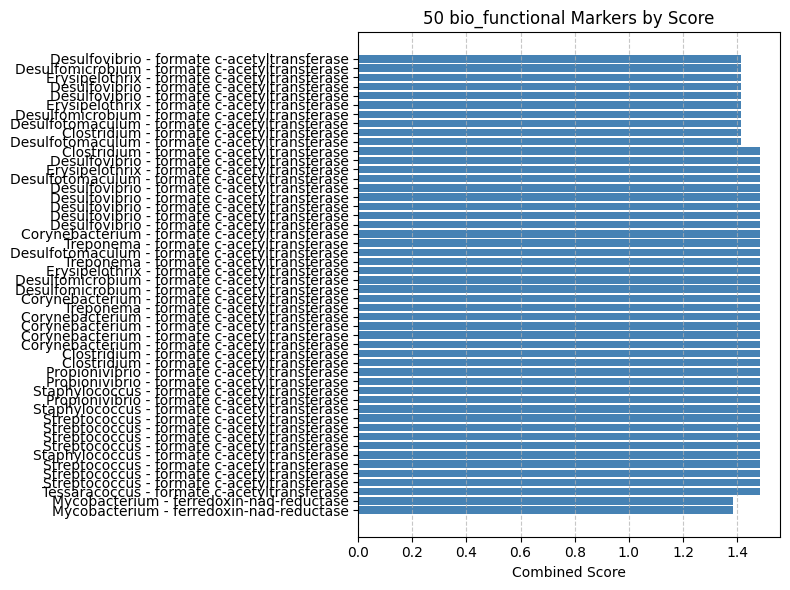

In [45]:
plot_top_markers_by_score(bio_functional, "bio_functional", top_n=50, figsize=(8, 6))

prot_path = data_visual/"22_prot-genus.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

## 4.8. Top Proteins by Shared Genera

In [46]:
def plot_top_proteins_by_shared_genera(prioritized_markers, name, top_n=20, min_score=0, figsize=(12, 8)):
    """
    Create a horizontal bar plot showing proteins and all genera that express them.
    Sorted by combined score with better display of genera information.
    """
    # Filter by minimum score if needed
    if min_score > 0:
        prioritized_markers = prioritized_markers[prioritized_markers['combined_score'] >= min_score]
    
    # Create protein-genus mapping with ALL occurrences
    protein_genus_data = []
    
    for _, row in prioritized_markers.iterrows():
        protein_name = row['protein_name']
        genus = row['Genus']
        score = row['combined_score']
        
        # Standardize protein name
        if isinstance(protein_name, str):
            # Clean up protein names
            protein_name = protein_name.replace('[', '').replace(']', '').strip()
        
        protein_genus_data.append({
            'protein_name': protein_name,
            'genus': genus,
            'combined_score': score
        })
    
    df_mapping = pd.DataFrame(protein_genus_data)
    
    # Group by protein and aggregate ALL genera (don't limit to top_markers only)
    protein_analysis = df_mapping.groupby('protein_name').agg({
        'genus': lambda x: list(x.unique()),
        'combined_score': 'max'
    }).reset_index()
    
    # Add count of unique genera per protein
    protein_analysis['genus_count'] = protein_analysis['genus'].apply(len)
    
    # Sort by combined score and take top N
    protein_analysis = protein_analysis.sort_values('combined_score', ascending=False).head(top_n)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data for plotting
    y_positions = range(len(protein_analysis))
    scores = protein_analysis['combined_score']
    
    # Create horizontal bars
    bars = ax.barh(y_positions, scores, color='steelblue', alpha=0.7)
    
    # Create detailed labels
    labels = []
    for _, row in protein_analysis.iterrows():
        protein_name = row['protein_name']
        # Truncate very long protein names
        if len(protein_name) > 40:
            protein_name = protein_name[:37] + "..."
        
        # Format genera list
        genera = sorted(row['genus'])
        genus_count = row['genus_count']
        
        # Show all genera if 5 or less, otherwise show first 3 and count
        if genus_count <= 5:
            genera_display = ', '.join(genera)
        else:
            genera_display = f"{', '.join(genera[:3])}, ... (+{genus_count-3} more)"
        
        # Combine into label
        labels.append(f"{protein_name}\n({genus_count} genera: {genera_display})")
    
    # Set labels and formatting
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Combined Score', fontsize=11)
    ax.set_title(f' Group {name}:Genera  grouped by Top {top_n} Proteins', fontsize=13)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}', 
                ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    return fig

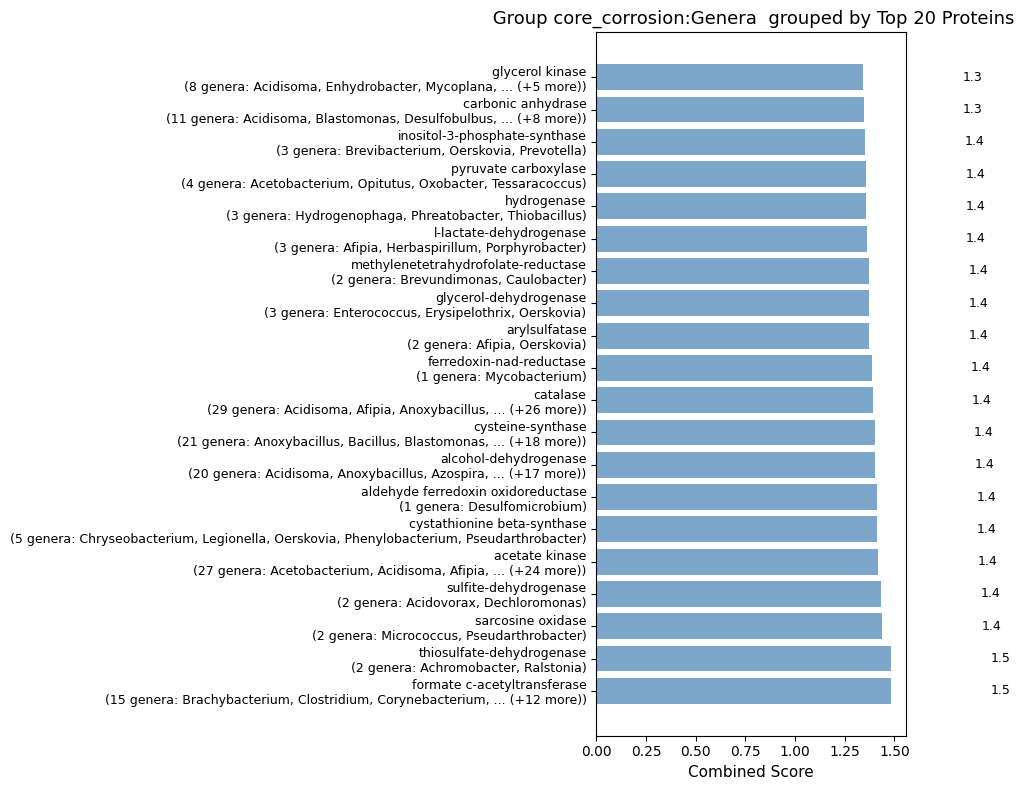

<Figure size 640x480 with 0 Axes>

In [47]:
fig1 = plot_top_proteins_by_shared_genera(core_corrosion,  "core_corrosion", top_n=20)
plt.figure(fig1.number)
plt.show()
prot_path = data_visual/"24_prot-genus.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

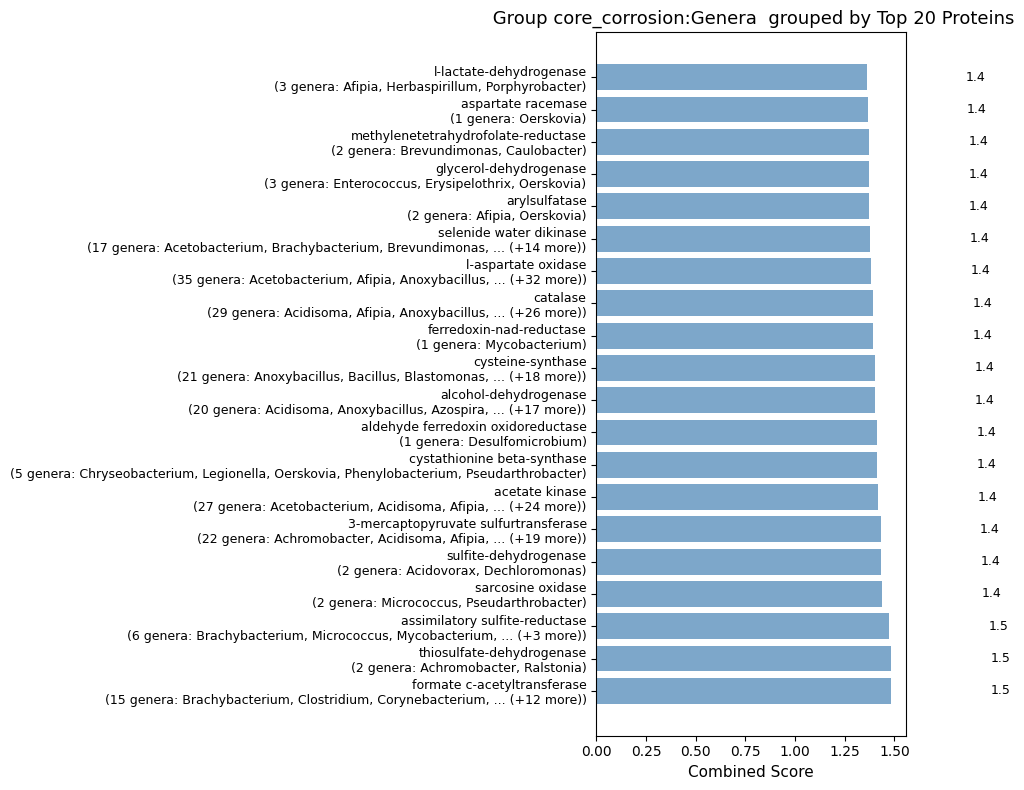

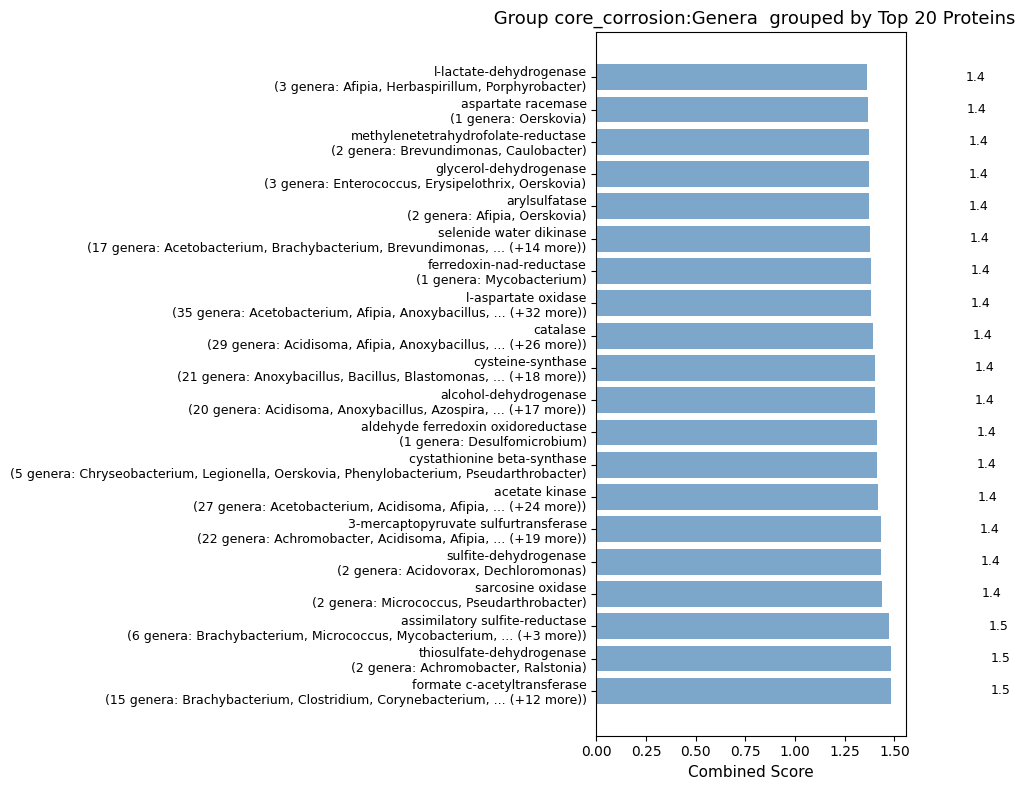

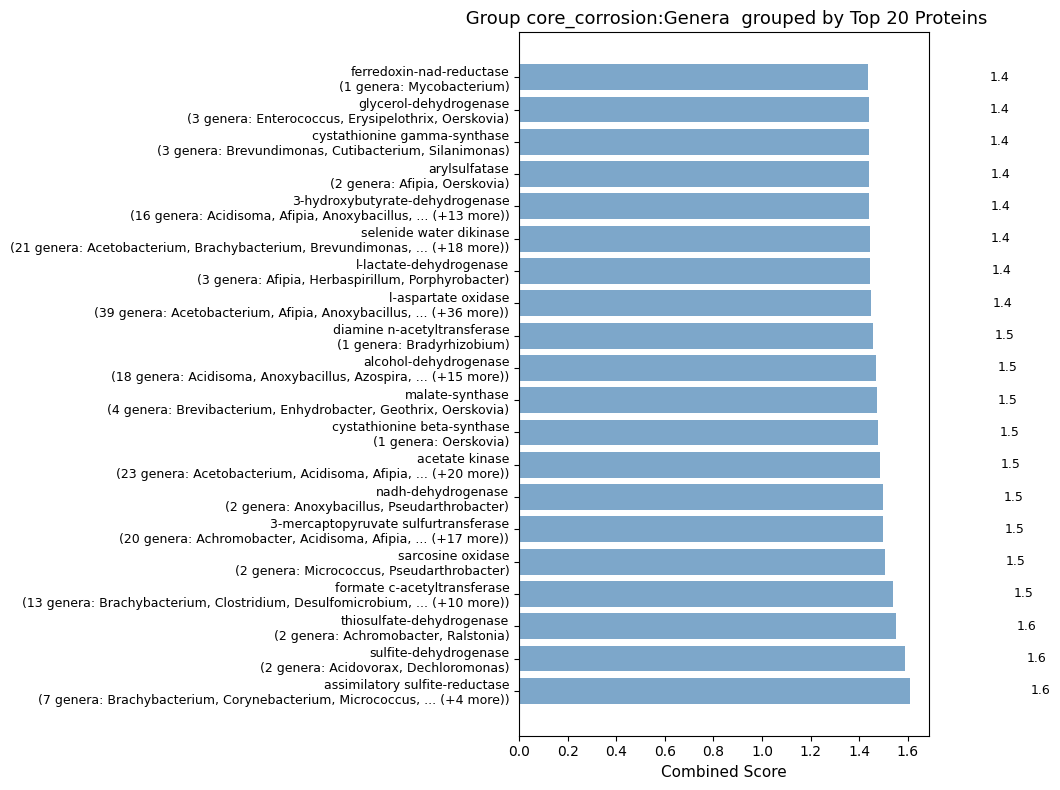

The high_metals_relevance grouping exposes the critical distinction between universal convergent proteins (bacterioferritin: 30 genera, ferroxidase: 10 genera) and genus-specific high-impact proteins (Mycobacterium DNA-binding protein HupB: 1 genus, 0.9 score). The bacterioferritin iron storage protein complex achieve convergence through independent expression across 30+ genera from different lineages, validating that iron sequestration is a non-negotiable requirement for MIC communities regardless of metabolic strategy.

The Mycobacterium DNA-binding protein HupB paradox reveals a critical oversight in metabolism-focused analyses: regulatory proteins that control metabolic gene expression can be as important as the metabolic enzymes themselves. HupB regulates stress response and biofilm formation genes, meaning a single genus expressing this regulator at high levels could coordinate multi-pathway corrosion mechanisms more effectively than multiple genera with constitutive enzyme expression. This suggests MIC success requires both the metabolic toolkit (universal proteins like bacterioferritin) and the regulatory machinery to deploy it appropriately (genus-specific regulators like HupB).

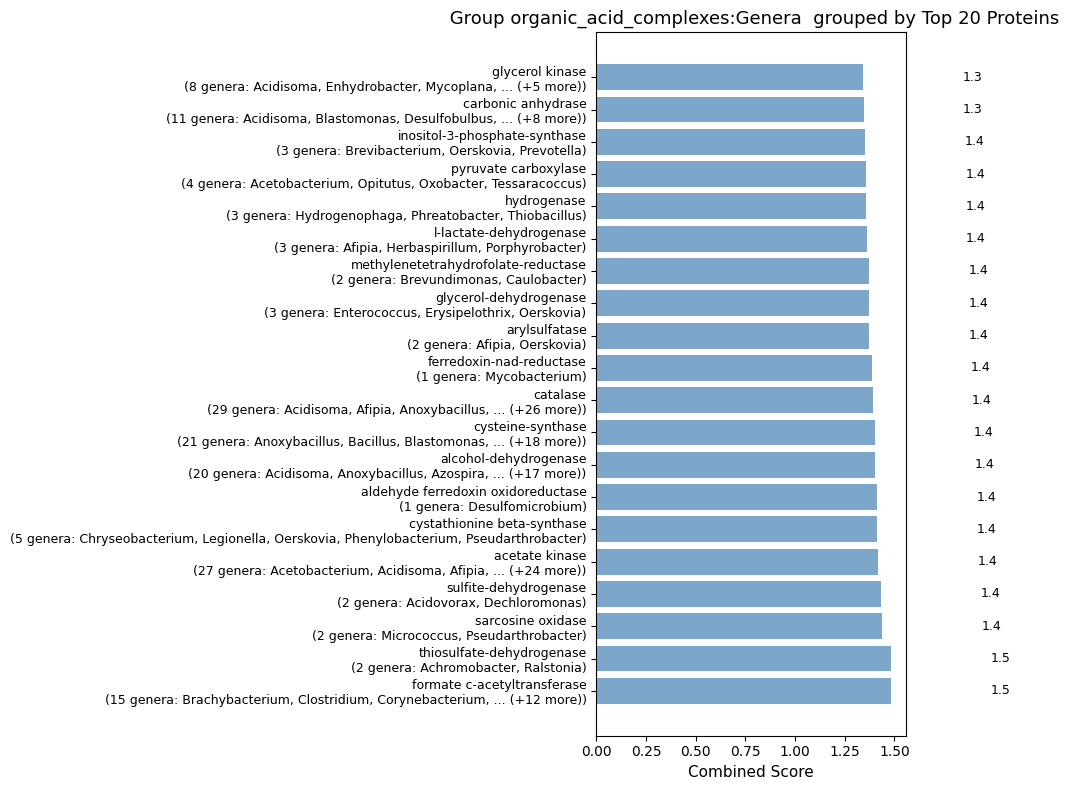

<Figure size 640x480 with 0 Axes>

In [48]:
fig1 = plot_top_proteins_by_shared_genera(organic_acid_complexes,  "organic_acid_complexes", top_n=20)
plt.figure(fig1.number)
plt.show()
prot_path = data_visual/"26_syn_prot-genus.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

The comparative protein-genus distributions across organic_acid_complexes, biofilm_complexes, and unified_synergy expose a hierarchical convergence architecture operating at three distinct levels, all achieving identical combined scores (0.9-1.1) despite radically different taxonomic distributions.
Tier 1: Universal Core (28+ genera) - Bacterioferritin, ferroxidase, and bacterial ferritin appear at the bottom of all three plots regardless of functional specialization, confirming iron sequestration as the non-negotiable foundation that every successful corrosion community must deploy. These proteins achieve convergence through independent horizontal gene transfer or ancient conservation across bacterial lineages.
Tier 2: Functional Specialists (6-12 genera) - Formate acetyltransferases appear in all three groups with moderate distribution, representing pathway-specific enzymes that multiple genera can express but aren't universal requirements. Organic acid complexes additionally show sulfite/sulfate reductases distributed across 1-12 genera, demonstrating that sulfur cycling is common but not obligatory for acid-mediated corrosion. Biofilm complexes show copper-containing nitrite-reductases across 8 genera, indicating that nitrogen metabolism provides an alternative electron acceptor strategy available to multiple lineages but not all.
Tier 3: Genus-Specific Amplifiers (1-3 genera) - Unified synergy reveals the most extreme specialists: sulfite-reductase oxidoreductase exclusive to Ralstonia, piub-related membrane protein exclusive to Caulobacter, and DNA-binding protein HupB exclusive to Mycobacterium. These single-genus high-impact proteins suggest that certain genera achieve disproportionate corrosion acceleration through unique regulatory or catalytic machinery unavailable to other community members, functioning as keystone species that coordinate or amplify the universal processes.
This three-tier architecture validates that convergence doesn't require taxonomic uniformity—communities can succeed through different combinations of universal proteins (all required), broadly-distributed specialists (pathway alternatives), and genus-unique amplifiers (optional but high-impact), explaining why 85 heterogeneous sites converge on failure despite maintaining taxonomic and metabolic diversity

In [ ]:
def get_marker_proteins(prioritized_markers):
    """
    Get unique proteins for Cat 2 and Cat 3 genera
    """
    
    cat2_genera = [
        'Propionibacterium', 'Azospira', 'Phreatobacter', 'Oerskovia', 
        'Bradyrhizobium', 'Desulfovibrio'
    ]
    
    cat3_genera = [
        'Novosphingobium', 'Sphingomonas', 'Sphingopyxis', 'Sphingobium',
        'Caulobacter', 'Brevibacterium', 'Micrococcus', 'Halomonas', 
        'Pseudomonas', 'Legionella', 'Erysipelothrix', 'Clostridium', 
        'Tessaracoccus', 'Corynebacterium', 'Desulfotomaculum', 
        'Oxobacter', 'Desulfosporosinus'
    ]
    
    # Filter and get unique proteins
    cat2_proteins = prioritized_markers[
        prioritized_markers['Genus'].isin(cat2_genera)
    ]['protein_name'].unique()
    
    cat3_proteins = prioritized_markers[
        prioritized_markers['Genus'].isin(cat3_genera)
    ]['protein_name'].unique()
    
    print("EARLY WARNING (Cat 2) - Proteins:")
    print(sorted(cat2_proteins))
    print(f"\nTotal: {len(cat2_proteins)}")
    
    print("\n" + "="*50)
    
    print("\nSYSTEM FAILURE (Cat 3) - Proteins:")
    print(sorted(cat3_proteins))
    print(f"\nTotal: {len(cat3_proteins)}")
    
    return cat2_proteins, cat3_proteins

cat2_proteins, cat3_proteins = get_marker_proteins(prioritized_markers)

EARLY WARNING (Cat 2) - Proteins:
['1 2-phenylacetyl-coa epoxidase subunit b', '1 4-alpha-glucan branching enzyme glgb-glucan bran', '1 4-dihydroxy-2-naphthoate octaprenyltransferase', '1 4-dihydroxy-2-naphthoyl-coa-synthase', '1-5-imidazole-4-carboxamide isomerase', '1-acyl-sn-glycerol-3-phosphate acyltransferase', '1-acylglycerol-3-phosphate o-acyltransferase', '1-aminocyclopropane-1-carboxylate deaminase', '1-deoxy-d-xylulose 5-phosphate reductoisomerase', '1-deoxy-d-xylulose-5-phosphate-synthase', '16s rrna-c)-methyltransferase-)-methyltransferase', '16s rrna-methyltransferase', '16s rrna-n)-methyltransferase', '16s rrna-n)-methyltransferase rsmd', '16s-23s rrna-methyltransferase tlya', '1d-myo-inositol 2-acetamido-2-deoxy-alpha-d-glucop', '2 3 4 5-tetrahydropyridine-2 6-dicarboxylate n-suc', '2 3-bisphosphoglycerate-dependent phosphoglycerate', '2 3-bisphosphoglycerate-independent phosphoglycera', '2 3-dihydro-2 3-dihydroxybenzoate-dehydrogenase', '2 3-dihydroxybenzoate-amp ligase

In [54]:
broad_corrosion['pathway_classification']

67        niche-specific
14        niche-specific
42        niche-specific
69        niche-specific
30        niche-specific
               ...      
125075    niche-specific
125070    niche-specific
125072    niche-specific
127900    niche-specific
334274    niche-specific
Name: pathway_classification, Length: 756, dtype: object

In [52]:
cat2_proteins, cat3_proteins = get_marker_proteins(broad_corrosion)

EARLY WARNING (Cat 2) - Proteins:
['3-mercaptopyruvate sulfurtransferase', 'acetate kinase', 'alcohol-dehydrogenase', 'arylsulfatase', 'aspartate racemase', 'assimilatory sulfite-reductase', 'biotin-synthase', 'catalase', 'cystathionine beta-synthase', 'cysteine-synthase', 'formate c-acetyltransferase', 'glycerol-dehydrogenase', 'hydrogenase', 'inositol-3-phosphate-synthase', 'l-aspartate oxidase']

Total: 15


SYSTEM FAILURE (Cat 3) - Proteins:
['3-hydroxybutyrate-dehydrogenase', '3-mercaptopyruvate sulfurtransferase', 'acetate kinase', 'acid phosphatase', 'alcohol-dehydrogenase', 'assimilatory sulfite-reductase', 'biotin-synthase', 'butyrate kinase', 'carbonic anhydrase', 'catalase', 'cystathionine beta-synthase', 'cysteine desulfurase', 'cysteine-synthase', 'formate c-acetyltransferase', 'glycerol kinase', 'glycerol-dehydrogenase', 'glycine oxidase', 'hydroxylamine-reductase', 'inositol-3-phosphate-synthase', 'l-aspartate oxidase', 'lipoyl-synthase', 'malate-synthase', 'methionine g

In [ ]:
def get_proteins_by_marker_category(prioritized_markers):
    """
    Filter proteins by Early Warning (Cat 2) vs System Failure (Cat 3) genera
    Returns top proteins for each marker category
    """
    
    # Define genera lists from hierarchy plot
    cat2_genera = [
        'Propionibacterium', 'Azospira', 'Phreatobacter', 'Oerskovia', 
        'Bradyrhizobium', 'Desulfovibrio'
    ]
    
    cat3_genera = [
        'Novosphingobium', 'Sphingomonas', 'Sphingopyxis', 'Sphingobium',
        'Caulobacter', 'Brevibacterium', 'Micrococcus', 'Halomonas', 
        'Pseudomonas', 'Legionella', 'Erysipelothrix', 'Clostridium', 
        'Tessaracoccus'
    ]
    
    # Filter dataframe by genera
    cat2_markers = prioritized_markers[
        prioritized_markers['Genus'].isin(cat2_genera)
    ]
    cat3_markers = prioritized_markers[
        prioritized_markers['Genus'].isin(cat3_genera)
    ]
    
    # Get top proteins for each category
    def get_top_proteins(df, top_n=10):
        protein_counts = df.groupby('protein_name').agg({
            'Genus': lambda x: list(x.unique()),
            'combined_score': 'mean'
        }).reset_index()
        protein_counts['genus_count'] = protein_counts['Genus'].apply(len)
        protein_counts = protein_counts.sort_values(
            ['genus_count', 'combined_score'], 
            ascending=[False, False]
        )
        return protein_counts.head(top_n)
    
    cat2_proteins = get_top_proteins(cat2_markers)
    cat3_proteins = get_top_proteins(cat3_markers)
    
    # Create summary table
    summary = pd.DataFrame({
        'Marker Type': ['Early Warning (Cat 2 peak)', 'System Failure (Cat 3 dominant)'],
        'Genera': [
            ', '.join(cat2_genera),
            ', '.join(cat3_genera)
        ],
        'Proteins to Link': [
            ', '.join(cat2_proteins['protein_name'].head(5).tolist()),
            ', '.join(cat3_proteins['protein_name'].head(5).tolist())
        ]
    })
    
    return summary, cat2_proteins, cat3_proteins

## 4.9. Metal Involvement by Genus across Risk Categories
The plot_metal_involvement function creates a heatmap showing the relationship between bacterial genera and the specific metals they interact with, weighted by the combined score from prioritized markers.

In [ ]:
def plot_metal_protein_specificity(prioritized_markers):
    """
    Shows which proteins are SELECTIVE vs PROMISCUOUS for metal ION SPECIES.
    Uses actual ion species from consolidated_metals (Fe+2, Fe+3, SO4-2, etc.)
    Adaptive threshold based on dataset.
    """
    
    metal_protein_data = []
    
    for _, row in prioritized_markers.iterrows():
        metals_val = row.get('consolidated_metals')
        
        if not isinstance(metals_val, (list, np.ndarray)) or len(metals_val) == 0:
            continue
        
        for ion_species in metals_val:
            if not ion_species or pd.isna(ion_species):
                continue
            
            metal_protein_data.append({
                'protein_name': row.get('protein_name', 'Unknown')[:40],
                'ion_species': str(ion_species).strip(),
                'mean_cat3': row.get('mean_cat3', 0)
            })
    
    if not metal_protein_data:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.text(0.5, 0.5, 'No metal-protein data found', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        return fig
    
    df = pd.DataFrame(metal_protein_data)
    
    # Calculate ion species diversity PER PROTEIN
    protein_ion_counts = df.groupby('protein_name')['ion_species'].nunique()
    protein_abundance = df.groupby('protein_name')['mean_cat3'].mean()
    
    # ADAPTIVE THRESHOLD - use 25th percentile of ion diversity
    threshold = int(protein_ion_counts.quantile(0.25))
    threshold = max(threshold, 2)  # At least 2
    
    print(f"\n=== Ion Species-Protein Analysis ===")
    print(f"Total ion-protein associations: {len(metal_protein_data)}")
    print(f"Unique proteins: {df['protein_name'].nunique()}")
    print(f"Ion diversity range: {protein_ion_counts.min()}-{protein_ion_counts.max()}")
    print(f"Adaptive threshold for 'selective': ≤{threshold} ion species")
    
    # Filter: selective proteins (bottom 25% diversity) with high abundance
    selective = protein_ion_counts[protein_ion_counts <= threshold].index
    selective_high = protein_abundance[selective].sort_values(ascending=False).head(20)
    
    if len(selective_high) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.text(0.5, 0.5, 
                f'No proteins found with ≤{threshold} ion species\n'
                f'(All proteins in this group use {protein_ion_counts.min()}+ ion types)', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        return fig
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Plot 1: Metal-selective proteins
    ax1.barh(range(len(selective_high)), selective_high.values, color='darkgreen', alpha=0.7)
    ax1.set_yticks(range(len(selective_high)))
    ax1.set_yticklabels(selective_high.index, fontsize=9)
    ax1.set_xlabel('Mean Cat3 Abundance', fontsize=11)
    ax1.set_title(f'Ion Species-SELECTIVE Proteins\n(≤{threshold} ion types, high abundance)', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Ion preferences
    selective_proteins = selective_high.index
    selective_df = df[df['protein_name'].isin(selective_proteins)]

    if not selective_df.empty:
        ion_by_selective = selective_df.pivot_table(
            index='protein_name', columns='ion_species', 
            values='mean_cat3', aggfunc='mean'
        ).fillna(0)

        if ion_by_selective.shape[0] > 0 and ion_by_selective.shape[1] > 0:
            sns.heatmap(
                ion_by_selective, cmap='Greens', linewidths=0.5, 
                cbar_kws={'label': 'Mean Cat3 Abundance'}, ax=ax2, 
                annot=True, fmt='.1f'
            )
            ax2.set_title(f'Ion Preferences (selective proteins)', fontsize=12)
            ax2.set_xlabel('Ion Species', fontsize=10)
        else:
            ax2.axis('off')
    else:
        ax2.axis('off')

    plt.tight_layout()
    
    print(f"Selective proteins (≤{threshold} species): {len(selective_high)}")
    print(f"\nTop ion species by frequency:")
    print(df['ion_species'].value_counts().head(10))
    
    return fig

In [ ]:
fig = plot_metal_protein_specificity(synergy_control)
plt.figure(fig.number)
plt.show()
prot_path = data_visual/"27_metal_protein.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

In [ ]:
try:
    import plotly.express as px
    _HAS_PLOTLY = True
except Exception:
    _HAS_PLOTLY = False


def _ensure_list(x):
    """Convert x to a python list if it is a string representation of a list."""
    if isinstance(x, np.ndarray):
        return x.tolist()

    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
 
    if isinstance(x, (set, tuple)):
        return list(x)
    # try to parse string-repr like "['As', 'Fe']" or "[As, Fe]" or "As, Fe"
    s = str(x).strip()
    # if it looks like a python list, literal_eval it
    if s.startswith("[") and s.endswith("]"):
        try:
            return list(ast.literal_eval(s))
        except Exception:
            pass
    # split on commas
    parts = [p.strip() for p in re.split(r",\s*", s) if p.strip() != ""]
    return parts

def normalize_metal_name(m: str) -> str:
    """Optional normalization of metal/electrolyte label (strip extra whitespace)."""
    if m is None or pd.isna(m): 
        return ""
    return str(m).strip()


def explode_metals(df: pd.DataFrame, metals_col: str = "consolidated_metals", metal_out_col: str = "metal", keep_original_cols: Optional[List[str]] = None) -> pd.DataFrame:
    """ Explode the consolidated_metals column into one metal per row. Handles lists or string representations of lists. Returns a new DataFrame with column metal_out_col."""

    if metals_col not in df.columns:
        raise KeyError(f"{metals_col} not found in dataframe columns")

    df = df.copy()
    # convert to lists
    df[metals_col] = df[metals_col].apply(_ensure_list)
    # explode
    df_expl = df.explode(metals_col, ignore_index=True)
    # normalize names
    df_expl[metal_out_col] = df_expl[metals_col].apply(normalize_metal_name)
    # optional: drop rows where metal is empty string
    df_expl = df_expl[df_expl[metal_out_col] != ""].reset_index(drop=True)
    return df_expl

def compute_metal_counts(df_exploded: pd.DataFrame, groupby_cols: List[str] = ["protein_name"], metal_col: str = "metal", distinct: bool = True) -> pd.DataFrame:
    """Compute number of distinct metals per group (default per protein_name). Returns df with columns groupby cols + metal_count + selectivity_label. """

    if metal_col not in df_exploded.columns:
        raise KeyError(f"{metal_col} not found in exploded dataframe")
    agg = df_exploded.groupby(groupby_cols)[metal_col].nunique().reset_index()
    agg = agg.rename(columns={metal_col: "metal_count"})
    # label: selective if metal_count == 1, promiscuous if >1
    agg["selectivity"] = np.where(agg["metal_count"] == 1, "SELECTIVE", "PROMISCUOUS")
    return agg

def presence_pivot(df_exploded: pd.DataFrame, index_cols: List[str] = ["Genus", "protein_name"], metal_col: str = "metal") -> pd.DataFrame:
    """ Create a presence (0/1) pivot table: index=index_cols joined with ' - ' and columns=metals. Each cell indicates presence (1) of that metal for that protein/genus pair."""

    df = df_exploded.copy()
    # create a unique index label (protein-genus pair)
    df["_index_label"] = df[index_cols].astype(str).agg(" - ".join, axis=1)
    # presence
    df["_presence"] = 1
    pivot = df.drop_duplicates(subset=["_index_label", metal_col]).pivot_table(index="_index_label", columns=metal_col, values="_presence", aggfunc="max", fill_value=0)
    # sort metals by total prevalence descending
    pivot = pivot.loc[:, pivot.sum(axis=0).sort_values(ascending=False).index]
    return pivot

def abundance_pivot(df_exploded: pd.DataFrame, value_col: str = "mean_cat1", index_cols: List[str] = ["Genus", "protein_name"], metal_col: str = "metal", aggfunc = "median") -> pd.DataFrame:
    """Create pivot table of abundances (value_col) aggregated by index and metal. aggfunc can be 'mean', 'median', 'sum' or a callable. """
    if value_col not in df_exploded.columns:
        raise KeyError(f"{value_col} not in dataframe")
    df = df_exploded.copy()
    df["_index_label"] = df[index_cols].astype(str).agg(" - ".join, axis=1)
    pivot = df.pivot_table(index="_index_label", columns=metal_col, values=value_col, aggfunc=aggfunc, fill_value=0)
    # Optionally order columns
    pivot = pivot.loc[:, pivot.max(axis=0).sort_values(ascending=False).index]
    return pivot

# PLOTTING HELPERS

def plot_metal_counts(df_exploded: pd.DataFrame, metal_col: str = "metal", top_n: int = 30, figsize=(8,5)):
    """Bar chart: number of distinct proteins (or pairs) associated with each metal."""
    counts = df_exploded.groupby(metal_col)["_index_label" if "_index_label" in df_exploded.columns else metal_col].nunique()
    counts = counts.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=figsize)
    sns.barplot(x=counts.values, y=counts.index, palette="viridis")
    plt.xlabel("Distinct protein / protein-Genus pairs")
    plt.ylabel("Metal")
    plt.title("Top metals by number of associated protein (or pair) entries")
    plt.tight_layout()


def plot_presence_heatmap(presence_df: pd.DataFrame, top_proteins: int = 50, figsize=(12,8), cmap="YlGnBu"):
    """
    presence_df: pivot table returned by presence_pivot (index = protein-genus label, columns = metal)
    Shows a heatmap of presence (0/1). Limit to top_proteins rows for readability.
    """
    if presence_df.shape[0] == 0:
        print("Empty presence dataframe")
        return
    sub = presence_df.copy()
    if sub.shape[0] > top_proteins:
        # choose the rows with highest metal diversity
        row_sums = sub.sum(axis=1).sort_values(ascending=False)
        sub = sub.loc[row_sums.index[:top_proteins]]
    plt.figure(figsize=figsize)
    sns.heatmap(sub, cmap=cmap, cbar_kws={'label': 'presence (1)/absence (0)'}, vmin=0, vmax=1)
    plt.xlabel("Metal")
    plt.ylabel("protein Genus - protein_name")
    plt.title(f"Presence heatmap ({sub.shape[0]} proteins shown)")
    plt.tight_layout()


def plot_abundance_dotplot(df_exploded: pd.DataFrame, value_col: str = "mean_cat1", groupby_col: str = "metal", color_by: Optional[str] = None, top_n_metals: int = 20, figsize=(10,6)):
    """ Dot plot with distribution of `value_col` per metal (uses seaborn stripplot + box/violin)."""
    if value_col not in df_exploded.columns:
        raise KeyError(f"{value_col} not in dataframe")
    # take top metals by count
    metal_counts = df_exploded[groupby_col].value_counts().head(top_n_metals).index
    sub = df_exploded[df_exploded[groupby_col].isin(metal_counts)].copy()
    plt.figure(figsize=figsize)
    sns.boxplot(x=groupby_col, y=value_col, data=sub, order=metal_counts, showfliers=False, color="lightgray")
    sns.stripplot(x=groupby_col, y=value_col, data=sub, order=metal_counts, jitter=True, size=3,
                  hue=color_by, dodge=False, palette="tab10" if color_by else None)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribution of {value_col} by metal")
    plt.tight_layout()
    if color_by:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


def plot_selectivity_vs_abundance(selectivity_df: pd.DataFrame, exploded_df: pd.DataFrame, value_col: str = "mean_cat1", groupby_cols: List[str] = ["Genus", "protein_name"], figsize=(8,5)):
    """ Compare abundance distributions for SELECTIVE vs PROMISCUOUS proteins. selectivity_df is output of compute_metal_counts. exploded_df should be used to map values.    """
    # merge selectivity label back to exploded rows per protein (or per pair)
    if len(groupby_cols) == 1 and groupby_cols[0] == "protein_name":
        merged = exploded_df.merge(selectivity_df[["protein_name","selectivity"]], on="protein_name", how="left")
    else:
        merged = exploded_df.copy()
        merged["_index_label"] = merged[groupby_cols].astype(str).agg(" - ".join, axis=1)
        sel = selectivity_df.copy()
        sel["_index_label"] = sel[groupby_cols].astype(str).agg(" - ".join, axis=1)
        merged = merged.merge(sel[["_index_label","selectivity"]], on="_index_label", how="left")
    if value_col not in merged.columns:
        raise KeyError(f"{value_col} not in dataframe")
    plt.figure(figsize=figsize)
    sns.violinplot(x="selectivity", y=value_col, data=merged, inner="quartile", palette="Set2")
    plt.title(f"{value_col} distribution: SELECTIVE vs PROMISCUOUS")
    plt.tight_layout()


def interactive_sunburst(df_exploded: pd.DataFrame, path_cols: List[str] = ["Genus", "protein_name", "metal"], values_col: Optional[str] = None):
    """ Interactive sunburst using plotly (if installed). Shows hierarchy Genus -> protein -> metal. values_col can be e.g., 'norm_abund_contri' to size slices.  """
    
    if not _HAS_PLOTLY:
        raise RuntimeError("plotly is not installed. pip install plotly to use interactive_sunburst")
    df = df_exploded.copy()
    if values_col and values_col in df.columns:
        agg = df.groupby(path_cols)[values_col].sum().reset_index()
        fig = px.sunburst(agg, path=path_cols, values=values_col)
    else:
        agg = df.groupby(path_cols).size().reset_index(name="count")
        fig = px.sunburst(agg, path=path_cols, values="count")
    fig.update_layout(margin=dict(t=10, l=10, r=10, b=10))
    return fig

# Utility: list numeric columns in dataframe
def numeric_columns(df: pd.DataFrame) -> List[str]:
    """Return list of columns in df that are numeric and suitable for plotting as numeric data."""
    return df.select_dtypes(include=[np.number]).columns.tolist()


In [ ]:
# Use the functions without any dashboard
df_exploded = explode_metals(high_corrosion_relevance, metals_col='consolidated_metals')

# Quick plots
plot_metal_counts(df_exploded, top_n=20)
plt.show()

selectivity = compute_metal_counts(df_exploded, groupby_cols=['protein_name'])
print(selectivity.head())

presence = presence_pivot(df_exploded)
plot_presence_heatmap(presence, top_proteins=30)
plt.show()
prot_path = data_visual/"27_prot-metal.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

The results of associating the system failure category with the protein being expressed shows Aspartate oxidase that could participates in acid production and the formation of hydrogen peroxide, depending on the electron acceptor in the reaction. If oxigen is in the scenario (early colonization) the production of H2O2 is facilitated, with oxide production (passive protective layers). If anaerobic conditions oxidative deamination gives succinate as product and further organic acids, which is apparently what is happening on this systems since one of the primary pathways seen previously for specialised groups is the organic acid pathway. The association with metals show As, H2, Fe which are not involved on the functionality but could be concommitant on other processes, if for instance the acid production induce the removal of Fe on these systems. The following major Protein is the Aminodeoxyfutolosine syntetase, which catalise the reduction of protons to H2 in a reductive process, to mantain Fe-S clusters. Then it is the 2 phosphosulfolactate phosphatase all protein major drivers of corrosion apparently on our systems. The co-occurrence of As, Fe, and H2 indicates metal mobilization and hydrogen production as outcomes of metabolic activity, consistent with acid-accelerated corrosion mechanisms.

# 5. Network Analysis

## 5.1 Network Analysis of Functional metabolism

In [ ]:
def create_static_network(
    df, name, center_category='functional_combi', top_n=100,
    gp_threshold=0.0, pf_threshold=0.0,
    normalize_divisor=None,
    show_func_labels="topk",
    func_label_topk=25,
    func_label_bbox=False,
    min_func_len=3,
    node_label_config=None,
    print_protein_info=True
):
    """
    Create static network visualization with integrated protein information report.
    
    Combines:
    - Excellent star/hub network visualization (Image 1 quality)
    - Detailed protein information text output (Image 2 quality)
    
    Args:
        df: DataFrame containing marker data
        name: Name for the network plot
        center_category: 'functional_combi', 'mechanisms_combi', 'operational_combi', 
                        'synergy_combi', 'consolidated_metals'
        top_n: Number of top markers (100+ recommended for density)
        gp_threshold: Genus-protein edge threshold
        pf_threshold: Protein-category edge threshold
        normalize_divisor: Score normalization divisor
        show_func_labels: "topk", "all", or "none"
        func_label_topk: Number of top category labels to show
        func_label_bbox: Add background box to category labels
        min_func_len: Minimum length for category labels
        node_label_config: {'genus': bool, 'protein': bool, 'category': bool}
        print_protein_info: If True, print detailed protein information report
    
    Returns:
        G: NetworkX graph object
    """
    if node_label_config is None:
        node_label_config = {'genus': True, 'protein': True, 'category': True}

    if 'Category' not in df.columns:
        df = df.copy()
        df['Category'] = df['Sites'].map(category_dict)

    required = ['Genus', 'protein_name', 'combined_score', center_category]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"Missing columns: {missing}")
        return None

    top_markers = df.sort_values('combined_score', ascending=False).head(top_n).copy()

    if normalize_divisor is None:
        cs = top_markers['combined_score'].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        p90 = np.percentile(cs, 90) if len(cs) > 0 else 1.0
        normalize_divisor = p90 if p90 > 0 else (cs.max() if cs.max() > 0 else 1.0)

    def norm_score(val):
        try:
            v = float(val)
        except (ValueError, TypeError):
            v = 0.0
        return float(np.clip(max(v, 0.0) / float(normalize_divisor), 0.0, 1.0))

    def flatten_center_category(val):
        """Flatten center_category respecting data types: dict, list, or string."""
        out = []
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return out
        
        if isinstance(val, dict):
            for k, v in val.items():
                if k and str(k).strip() and str(k).strip() != '<NA>':
                    out.append(str(k).strip())
                if isinstance(v, (list, tuple, set)):
                    out.extend([str(x).strip() for x in v if x and str(x).strip() and str(x).strip() != '<NA>'])
                elif v and str(v).strip() and str(v).strip() != '<NA>':
                    out.append(str(v).strip())
            return out
        
        if isinstance(val, (list, tuple, set)):
            return [str(x).strip() for x in val if x and str(x).strip() and str(x).strip() != '<NA>']
        
        return [s.strip() for s in str(val).split(';') if s.strip() and s.strip() != '<NA>']

    def clean_values(vals):
        """Remove duplicates and values below min_func_len."""
        seen = set()
        out = []
        for f in vals:
            f2 = str(f).strip()
            if not f2 or len(f2) < min_func_len:
                continue
            if f2 not in seen:
                seen.add(f2)
                out.append(f2)
        return out

    # Build graph
    G = nx.Graph()
    protein_full_names = {}
    protein_to_genera = {}
    protein_to_center_category = {}

    for _, row in top_markers.iterrows():
        genus_raw = row['Genus']
        protein_raw = row['protein_name']
        if pd.isna(genus_raw) or pd.isna(protein_raw):
            continue
        
        genus = str(genus_raw).strip()
        protein = str(protein_raw).strip()
        protein_short = protein[:27] + "..." if len(protein) > 30 else protein

        gid = f"g:{genus}"
        pid = f"p:{protein_short}"

        # Store full protein name for later reporting
        protein_full_names[pid] = protein

        # Add nodes
        if not G.has_node(gid):
            G.add_node(gid, type='genus', label=genus)
        if not G.has_node(pid):
            G.add_node(pid, type='protein', label=protein_short)

        # Track relationships
        if pid not in protein_to_genera:
            protein_to_genera[pid] = []
        protein_to_genera[pid].append(genus)

        # Genus-protein edge
        w = norm_score(row.get('combined_score', 0.0))
        if w >= gp_threshold:
            G.add_edge(gid, pid, weight=w)

        # Center-category edges
        cats = clean_values(flatten_center_category(row.get(center_category)))
        if pid not in protein_to_center_category:
            protein_to_center_category[pid] = []
        protein_to_center_category[pid].extend(cats)

        for c in cats:
            cid = f"c:{c}"
            if not G.has_node(cid):
                G.add_node(cid, type='category', label=c)
            wf = max(0.4, w)
            if wf >= pf_threshold:
                G.add_edge(pid, cid, weight=wf)

    if G.number_of_edges() == 0:
        print(f"Graph has no edges. Try: lower gp_threshold/pf_threshold, or adjust normalize_divisor.")
        return G

    # Community detection
    try:
        partition = community_louvain.best_partition(G)
        nx.set_node_attributes(G, partition, 'community')
    except Exception as e:
        print(f"Community detection skipped: {e}")
        nx.set_node_attributes(G, 0, 'community')

    # Node sizes by degree
    degree_dict = dict(G.degree())
    node_sizes = {}
    for n in G.nodes():
        t = G.nodes[n].get('type')
        base = 900 if t == 'genus' else (650 if t == 'protein' else 500)
        node_sizes[n] = base * (1 + np.log1p(degree_dict.get(n, 0)) / 2)

    # Layout and draw
    plt.figure(figsize=(18, 14))
    pos = nx.spring_layout(G, k=0.6, seed=42, iterations=200)
    edge_weights = [max(1.2, G[u][v].get('weight', 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.6, width=edge_weights, edge_color='gray')

    # Node colors
    node_colors_map = {'genus': 'blue', 'protein': 'purple', 'category': 'brown'}
    for t, color in node_colors_map.items():
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == t]
        if nodes:
            nx.draw_networkx_nodes(
                G, pos, nodelist=nodes,
                node_color=color,
                node_size=[node_sizes[n] for n in nodes],
                alpha=0.9, linewidths=0.5, edgecolors='white'
            )

    # Labels
    labels = {n: G.nodes[n].get('label', n) for n in G.nodes()}
    genus_labels = {n: labels[n] for n in G.nodes() if G.nodes[n].get('type') == 'genus'}
    protein_labels = {n: labels[n] for n in G.nodes() if G.nodes[n].get('type') == 'protein'}
    func_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']

    if genus_labels and node_label_config.get('genus'):
        nx.draw_networkx_labels(G, pos, labels=genus_labels, font_size=12, font_weight='bold',
                                font_color='black', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))
    if protein_labels and node_label_config.get('protein'):
        nx.draw_networkx_labels(G, pos, labels=protein_labels, font_size=9, font_color='black')

    # Functional/category labeling
    func_label_set = set()
    if show_func_labels == "all":
        func_label_set = set(func_nodes)
    elif show_func_labels == "topk":
        func_nodes_sorted = sorted(func_nodes, key=lambda n: degree_dict.get(n, 0), reverse=True)[:func_label_topk]
        func_label_set = set(func_nodes_sorted)
    
    if func_label_set and node_label_config.get('category'):
        func_labels = {n: labels[n] for n in func_label_set}
        func_bbox = dict(facecolor='white', alpha=0.35, edgecolor='none', pad=0.6) if func_label_bbox else None
        nx.draw_networkx_labels(G, pos, labels=func_labels, font_size=9, font_color='black', bbox=func_bbox)

    # Legend and title
    plt.plot([0], [0], 'o', color=node_colors_map['genus'], markersize=12, label='Genus')
    plt.plot([0], [0], 'o', color=node_colors_map['protein'], markersize=10, label='Protein')
    plt.plot([0], [0], 'o', color=node_colors_map['category'], markersize=11, label=center_category)
    plt.legend(loc='upper right', frameon=True, fontsize=12)
    plt.title(f"{name} Network of Top {top_n} Corrosion Markers ({center_category})", fontsize=18)
    plt.axis('off')
    plt.tight_layout()
    plt.gca().set_facecolor('white')
    plt.gcf().set_facecolor('white')

    # Debug counts
    gp_edges = sum(1 for u, v in G.edges() if (G.nodes[u]['type'] == 'genus' and G.nodes[v]['type'] == 'protein') or
                                              (G.nodes[v]['type'] == 'genus' and G.nodes[u]['type'] == 'protein'))
    pf_edges = sum(1 for u, v in G.edges() if (G.nodes[u]['type'] == 'protein' and G.nodes[v]['type'] == 'category') or
                                              (G.nodes[v]['type'] == 'protein' and G.nodes[u]['type'] == 'category'))
    print(f"✓ Network created: {G.number_of_nodes()} nodes | genus–protein={gp_edges} | protein–{center_category}={pf_edges} | total edges={G.number_of_edges()}")

    # ============================================================================
    # INTEGRATED PROTEIN INFORMATION REPORT (from create_dynamic_network)
    # ============================================================================
    if print_protein_info:
        print(f"\n{'='*90}")
        print(f"PROTEIN INFORMATION - {name.upper()}")
        print(f"{'='*90}")
        
        # Collect protein connection info
        protein_connections = {}
        for pid, full_name in protein_full_names.items():
            if pid in G:
                connections = degree_dict.get(pid, 0)
                genera = list(set(protein_to_genera.get(pid, [])))  # Unique genera
                categories = list(set(protein_to_center_category.get(pid, [])))  # Unique categories
                protein_connections[pid] = {
                    'full_name': full_name,
                    'connections': connections,
                    'genera': genera,
                    'categories': categories
                }
        
        # Sort by connections (descending)
        sorted_proteins = sorted(protein_connections.items(), 
                               key=lambda x: x[1]['connections'], reverse=True)
        
        # Print protein details
        for pid, info in sorted_proteins:
            print(f"\n{info['full_name']}")
            print(f"  Connections: {info['connections']}")
            print(f"  Expressed by: {', '.join(info['genera'])}")
            if info['categories']:
                cat_label = center_category.replace('_', ' ').title()
                print(f"  {cat_label}: {', '.join(info['categories'][:7])}")
                if len(info['categories']) > 7:
                    print(f"             ... and {len(info['categories']) - 7} more")
        
        print(f"\n{'='*90}")
        print(f"Summary: {len(sorted_proteins)} proteins across {len(set(g for info in protein_connections.values() for g in info['genera']))} genera")
        print(f"{'='*90}\n")

    return G

In [ ]:
# 1. Using functional_combi (dict of {subcategory: [child_terms]})
G1 = create_static_network(
    core_corrosion, 
    name="core_corrosion",
    center_category='functional_combi',
    top_n=100,
    gp_threshold=0.0,
    pf_threshold=0.0,
    show_func_labels="topk",
    func_label_topk=20
)
# save the image
output_share = data_visual/"28_core__network.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:
# 2. Using mechanisms_combi (dict of {subcategory: [child_terms]})
G2 = create_static_network(
    high_corrosion,
    name="high_corrosion",
    center_category='mechanisms_combi',
    top_n=100,
    show_func_labels="all"
)
# save the image
output_share = data_visual/"29_high_mechanisms.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:

# 3. Using synergy_combi (list of strings)
G3 = create_static_network(
    synergy_control,
    name="synergy_control",
    center_category='synergy_combi',
    top_n=100,
    normalize_divisor=8.0,
    func_label_bbox=True
)
# save the image
output_share = data_visual/"30_synergy"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:

# 4. Using consolidated_metals (list of ions with charge notation)
G4 = create_static_network(
    biofilm_complexes,
    name="biofilm_complexes",
    center_category='functional_combi',
    top_n=50,
    min_func_len=2,  # Allow shorter metal symbols like 'Fe', 'Cu'
    show_func_labels="topk",
    func_label_topk=20
)
output_share = data_visual/"30_biofilm_functional.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:
# 5. Using consolidated_metals (list of ions with charge notation)
G4 = create_static_network(
    organic_acid_complexes,
    name="Metal Involvement",
    center_category='consolidated_metals',
    top_n=100,
    min_func_len=2,  # Allow shorter metal symbols like 'Fe', 'Cu'
    show_func_labels="topk",
    func_label_topk=20
)
output_share = data_visual/"30_metal"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

|Protein|Function and MIC Relevance|
|--|--|
|Sarcosine Oxidase|Generates the potent oxidizing agent hydrogen peroxide (H2​O2​), link to oxidative stress which can directly weaken the passive oxide layer on metal surfaces.|
|NADH Dehydrogenase|Functions in an alternative, non-proton-pumping electron transport chain, potentially supporting bacterial survival in low-oxygen, high-stress biofilm environments characteristic of MIC sites.|
|Assimilatory Sulfite Reductase|Consumes sulfite while producing both the essential metabolite sulfide and protons (H+), contributing to localized acidification and corrosive sulfide formation within the biofilm.|
|Thiosulfate Dehydrogenase|Facilitates the use of thiosulfate as an alternative electron acceptor in terminal respiration, supporting energy generation and colonization in late-stage, oxygen-depleted niches.|
|Formate C-Acetyltransferase|also known as Pyruvate formate-lyase, is central to mixed-acid fermentation in glucose metabolism, it generates formate, an organic acid and corrosive agent, linking central carbon metabolism to material degradation.|
|Alcohol Dehydrogenase|Generates corrosive aldehydes and ketones from alcohols, particularly important in later biofilm stages where fermentation products and other complex organics accumulate.|
|Aconitate Hydratase|A key enzyme in the TCA cycle and iron metabolism(Iron-sulfur cluster binding), its iron-dependent function links the breakdown of corrosive citrate with the cell's essential iron-regulation and growth processes.|
1.  MetaCyc. (2025). Sarcosine oxidase
2. NCBI/UniProt. (2025). NADH Dehydrogenase
3. BioCyc. (2025). Assimilatory Sulfite Reductase (ASR)
4. NCBI/GenBank. (2025). Thiosulfate dehydrogenase (TsdA)
5.  MetaCyc. (2025). Formate C-Acetyltransferase
6. BioCyc. (2025). Alcohol dehydrogenase
7.  UniProt/SwissProt. (2025). Aconitate Hydratase (Acn)


## 5.3 Network Dashboard protein-Genus Pairs

In [ ]:
def create_dynamic_network(df, name, top_n=30, threshold=0.5, center_category='mechanisms_sub',
                                                        node_label_config=None):
    """
    Creates a dynamic network visualization where the center category can be changed.
    
    Args:  df: DataFrame containing marker data, name: Name for the network plot
        top_n: Number of top markers to include, threshold: Edge weight threshold (0.0-1.0)
        center_category: Column name for the category to show distributed around perimeter  ('mechanisms_sub', 'functional_sub', 
                         'pathways', 'synergies', etc.)
        node_label_config: Dict specifying which node types to label: {'genus': True, 'protein': True, 'category': True}
    
    Returns:  G: NetworkX graph object
    """
    
    # Default label configuration
    if node_label_config is None:
        node_label_config = {'genus': True,
            'protein': True,
            'category': True
        }
    
    # Dynamic color scheme based on category type
    color_schemes = {
        'mechanisms_sub': {'genus': '#1976D2',      # Deep blue
            'protein': '#388E3C',    # Forest green  
            'category': '#D32F2F'    # Deep red
        },
        'functional_sub': {'genus': '#303F9F',      # Indigo
            'protein': '#689F38',    # Light green
            'category': '#F57C00'    # Orange
        },
        'pathways': {'genus': '#0288D1',      # Light blue
            'protein': '#7B1FA2',    # Purple
            'category': '#C2185B'    # Pink
        },
        'synergies': {'genus': '#00796B',      # Teal
            'protein': '#5D4037',    # Brown
            'category': '#FFA000'    # Amber
        }
    }
    
    # Use appropriate color scheme or default
    node_colors = color_schemes.get(center_category, color_schemes['mechanisms_sub'])
    
    # Check required columns
    required_cols = ['Genus', 'protein_name', 'combined_score', center_category]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    # Create network
    G = nx.Graph()
    
    # Get top markers the top markers in each df already sorted intop
    top_markers = df.copy()
    if "Category" not in top_markers:
        top_markers["Category"] = top_markers["Sites"].map(category_dict)
    
    # Store full protein names for reference
    protein_full_names = {}
    protein_to_genera = {}  # Track which genera connect to which proteins
    
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        # Create unique protein identifier to avoid merging different proteins
        protein_id = protein # f"{protein}_{genus[:3]}"  # Add genus prefix for uniqueness
        
        # Store full name
        protein_full_names[protein_id] = protein
        
        # Add nodes
        if not G.has_node(genus):
            G.add_node(genus, type='genus', label=genus)
        
        if not G.has_node(protein_id):
            G.add_node(protein_id, type='protein', 
                      full_name=protein,
                      label=protein if len(protein) <= 30 else protein[:27] + "...")
        
        # Track genus-protein relationships
        if protein_id not in protein_to_genera:
            protein_to_genera[protein_id] = []
        protein_to_genera[protein_id].append(genus)
        
        # Add edge with weight
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        norm_score = min(score / 50, 1.0)  # Normalize score
        G.add_edge(genus, protein_id, weight=norm_score)
        
        # Add category nodes and edges
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                if not G.has_node(cat):
                    G.add_node(cat, type='category', label=cat)
                G.add_edge(protein_id, cat, weight=0.8)
    
    # Calculate layout with categories DISTRIBUTED around perimeter
    category_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']
    n_categories = len(category_nodes)
    
    # Create custom layout
    pos = {}
    
    # Place categories around the perimeter (maximally separated)
    if n_categories > 0:
        # Use larger radius to push categories to perimeter
        radius = 2.5  # Increased radius for maximum separation
        angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False)
        
        for i, cat in enumerate(category_nodes):
            pos[cat] = (radius * np.cos(angles[i]), radius * np.sin(angles[i]))
    
    # Use spring layout for other nodes with fixed category positions
    # Increased k parameter and iterations for better separation
    if category_nodes:
        other_pos = nx.spring_layout(G, k=2.0, pos=pos, fixed=category_nodes, 
                                    seed=42, iterations=150)
        pos.update(other_pos)
    else:
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=150)
    
    # Create figure with larger size to accommodate distributed layout
    plt.figure(figsize=(30, 20))
    
    # Draw edges with varying width
    edge_weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_weights, edge_color='gray')
    
    # Calculate node sizes based on degree
    degree_dict = dict(G.degree())
    node_sizes = {}
    for node in G.nodes():
        node_type = G.nodes[node].get('type')
        base_size = {'genus': 800, 'protein': 600, 'category': 1200}.get(node_type, 500)  # Larger category nodes
        node_sizes[node] = base_size * (1 + np.log1p(degree_dict[node]) / 3)
    
    # Draw nodes by type
    for node_type in ['genus', 'protein', 'category']:
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
        if nodes:
            nx.draw_networkx_nodes(G, pos, 
                                  nodelist=nodes,
                                  node_color=node_colors[node_type],
                                  node_size=[node_sizes[n] for n in nodes],
                                  alpha=0.85,
                                  edgecolors='black',
                                  linewidths=1.5)
    
    # Draw labels based on configuration
    labels = {}
    font_configs = {
        'genus': {'size': 11, 'weight': 'bold', 'bbox': dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)},
        'protein': {'size': 9, 'weight': 'normal', 'bbox': dict(facecolor='lightgray', alpha=0.7, edgecolor='none', pad=0.5)},
        'category': {'size': 13, 'weight': 'bold', 'bbox': dict(facecolor='yellow', alpha=0.9, edgecolor='black', pad=2)}  # More prominent labels
    }
    
    for node_type, should_label in node_label_config.items():
        if should_label:
            nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
            node_labels = {n: G.nodes[n].get('label', n) for n in nodes}
            
            if node_labels:
                font_config = font_configs.get(node_type, {})
                nx.draw_networkx_labels(G, pos, 
                                       labels=node_labels,
                                       font_size=font_config.get('size', 10),
                                       font_weight=font_config.get('weight', 'normal'),
                                       bbox=font_config.get('bbox', None))
        
    for node_type, color in node_colors.items():
        if node_counts[node_type] > 0:
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=color, markersize=12,
                                            label=legend_labels[node_type],
                                            markeredgecolor='black', markeredgewidth=1.5))
    
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)
    
    # Title with category info
    plt.title(f"{name} Network: Top {top_n} Markers - {center_category.replace('_', ' ').title()} Distributed", 
              fontsize=18, fontweight='bold', pad=20)
    
    plt.axis('off')
    plt.tight_layout()
    
    # Print protein information if not all are labeled
    if not node_label_config.get('protein', True):
        print(f"\n{'='*80}")
        print(f"PROTEIN INFORMATION (Full Names)")
        print(f"{'='*80}")
        
        # Sort proteins by number of connections
        protein_connections = {}
        for protein_id, full_name in protein_full_names.items():
            if protein_id in G:
                connections = degree_dict.get(protein_id, 0)
                genera = protein_to_genera.get(protein_id, [])
                protein_connections[protein_id] = (full_name, connections, genera)
        
        # Sort by number of connections
        sorted_proteins = sorted(protein_connections.items(), 
                               key=lambda x: x[1][1], reverse=True)
        
        for protein_id, (full_name, connections, genera) in sorted_proteins:
            print(f"\n{full_name}")
            print(f"  Connections: {connections}")
            print(f"  Expressed by: {', '.join(genera)}")
            
            # Get connected categories
            connected_cats = [n for n in G.neighbors(protein_id) 
                            if G.nodes[n].get('type') == 'category']
            if connected_cats:
                print(f"  {center_category.replace('_', ' ').title()}: {', '.join(connected_cats)}")
    
    print(f"\nNetwork statistics:")
    print(f"  Total nodes: {len(G.nodes())}")
    print(f"  Total edges: {len(G.edges())}")
    print(f"  Network density: {nx.density(G):.3f}")
    
    return G

def create_network_plotly(df, center_category, top_n=30):
    """Convert matplotlib network to Plotly for web display"""
    
    # Check required columns first
    required_cols = ['Genus', 'protein_name', 'combined_score', center_category]
 
    # Create the network 
    G = nx.Graph()
    top_markers = df.sort_values('combined_score', ascending=False).head(top_n)
    
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        protein_id = protein # f"{protein}_{genus[:3]}"
        
        # Add nodes 
        if not G.has_node(genus):
            G.add_node(genus, type='genus', label=genus)
        
        if not G.has_node(protein_id):
            G.add_node(protein_id, type='protein', 
                      full_name=protein,
                      label=protein if len(protein) <= 30 else protein[:27] + "...")
        
        # Add edge with weight
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        norm_score = min(score / 50, 1.0)
        G.add_edge(genus, protein_id, weight=norm_score)
        
        # Add category nodes and edges 
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                if not G.has_node(cat):
                    G.add_node(cat, type='category', label=cat)
                G.add_edge(protein_id, cat, weight=0.8)
    
    if len(G.nodes()) == 0:
        return None, "No valid data found to create network"
 
    category_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']
    n_categories = len(category_nodes)
    pos = {}
    
    # Place categories around perimeter 
    if n_categories > 0:
        radius = 2.5
        angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False)
        for i, cat in enumerate(category_nodes):
            pos[cat] = (radius * np.cos(angles[i]), radius * np.sin(angles[i]))
    
    # Spring layout for other nodes 
    if category_nodes:
        other_pos = nx.spring_layout(G, k=2.5, pos=pos, fixed=category_nodes, 
                                    seed=42, iterations=500)
        pos.update(other_pos)
    else:
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=150)
    
    # Convert to Plotly
    edge_x, edge_y = [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    
    # Use  color scheme
    color_schemes = { # combis are each one dictionary, pathways is only one str.
        'mechanisms_combi': {'genus': '#1976D2', 'protein': '#388E3C', 'category': '#D32F2F'},
        'functional_combi': {'genus': '#303F9F', 'protein': '#689F38', 'category': '#F57C00'},
        'pathways': {'genus': '#0288D1', 'protein': '#7B1FA2', 'category': '#C2185B'},
    }
    node_colors = color_schemes.get(center_category, color_schemes['corrosion_mechanisms'])
    
    fig = go.Figure()
    
    # Add edges
    fig.add_trace(go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='gray'),
                            hoverinfo='none', mode='lines', showlegend=False))
    
    # Add nodes by type 
    for node_type in ['genus', 'protein', 'category']:
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
        if nodes:
            node_x = [pos[node][0] for node in nodes]
            node_y = [pos[node][1] for node in nodes]
            node_text = [G.nodes[node].get('label', node) for node in nodes]
            
            size = {'genus': 20, 'protein': 20, 'category': 25}[node_type]
            
            fig.add_trace(go.Scatter(
                x=node_x, y=node_y, 
                mode='markers+text', 
                text=node_text,
                textposition="top center", 
                hovertemplate='<b>%{text}</b><br>Type: ' + node_type + '<br>Connections: %{customdata}<extra></extra>',
                customdata=[len(list(G.neighbors(node))) for node in nodes],  # Connection count
                marker=dict(size=size, color=node_colors[node_type], 
                        line=dict(width=2, color='white')),
                name=f'{node_type.title()} ({len(nodes)})',
                textfont=dict(size=14, color='black')
            ))
    
    fig.update_layout(
        title=dict(text=f"Network: {center_category.replace('_', ' ').title()} Distributed", 
                   font=dict(size=16)),
        showlegend=True, hovermode='closest',  dragmode='pan',
        margin=dict(b=20,l=5,r=5,t=60),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='#f8f9fa', height=900
    )
    
    stats = {'nodes': len(G.nodes()), 'edges': len(G.edges()), 
             'categories': len(category_nodes), 'density': f"{nx.density(G):.3f}"}
    
    return fig, stats

# Initialize the Dash app
app = dash.Dash(__name__)

categories = [
    {'label': 'Enzyme Class', 'value': 'enzyme_class'},
    {'label': 'Pathways', 'value': 'pathways'},
    {'label': 'Hierarchy', 'value': 'hierarchy'},
    {'label': 'Metals Consolidated', 'value': 'consolidated_metals'},
    {'label': 'Functional Categories', 'value': 'functional_categories'},
    {'label': 'Corrosion Synergies', 'value': 'corrosion_synergies'},
    {'label': 'Organic Processes', 'value': 'organic_processes'},
    {'label': 'Corrosion Mechanisms', 'value': 'corrosion_mechanisms'},
    {'label': 'Niche Specific Pathways', 'value': 'niche_specific_pathways'},
    {'label': 'Functional Categories Present', 'value': 'functional_categories_present'}
]

app.layout = html.Div([
    html.Div([
        # Sidebar (left column)
        html.Div([
            html.H2("Network Dashboard", style={
                'color': 'white',
                'fontSize': '1.3em',
                'marginBottom': '24px',
                'marginTop': '0',
                'textAlign': 'left'
            }),
            html.Div([
                html.Strong("Legend", style={'color': 'white'}),
                html.Ul([
                    html.Li("Gene", style={'color': 'lightblue'}),
                    html.Li("Protein", style={'color': 'orange'}),
                    html.Li("Category", style={'color': 'darkgreen'}),
                ], style={'listStyleType': 'circle', 'marginLeft': '18px', 'color': 'white', 'marginBottom': '18px'})
            ], style={'marginBottom': '18px'}),
            html.Div(id='network-stats', style={
                'backgroundColor': 'rgba(0,0,0,0.7)',
                'padding': '14px',  'borderRadius': '8px',  'color': 'white',  'marginBottom': '24px'
            }),
            html.Label("Select Category:", style={'color': 'white', 'fontWeight': 'bold',  'marginBottom': '6px'
            }),
            dcc.Dropdown(
                id='category-dropdown',     options=categories,   value='functional_categories',   style={'marginBottom': '24px'}
            ),
        ], style={ 'width': '260px', 'background': 'rgba(255,255,255,0.08)',  'padding': '32px 18px', 'borderRadius': '15px', 'minHeight': '90vh',
            'display': 'flex', 'flexDirection': 'column',  'justifyContent': 'flex-start'
        }),

        # Main plot (right column)
        html.Div([
            dcc.Graph(id='network-plot', style={'height': '80vh', 'width': '100%'})
        ], style={ 'flexGrow': 1,   'padding': '24px'
        })
    ], style={
        'display': 'flex', 'flexDirection': 'row',  'height': '100vh',
        'background': 'linear-gradient(135deg, #667eea 0%, #764ba2 100%)'
    })
])

@app.callback(
    [Output('network-plot', 'figure'), Output('network-stats', 'children')],
    [Input('category-dropdown', 'value')]
)
def update_network(selected_category):
    
    fig, stats = create_network_plotly(core_corrosion, selected_category, top_n=50)
    
    if fig is None:
        empty_fig = go.Figure()
        empty_fig.update_layout(title=f"Error: {stats}", plot_bgcolor='lightgray', height=900)
        error_div = html.Div([html.H4("Error:", style={'color': 'red'}), 
                            html.P(stats, style={'color': 'red'})])
        return empty_fig, error_div
    
    stats_div = html.Div([
        html.H4("Network Statistics", style={'color': 'white', 'marginRight': '30px'}),
        html.Div([html.Span(f"Nodes: {stats['nodes']}", style={'color': 'lightblue', 'marginRight': '25px'}),
        html.Span(f"Edges: {stats['edges']}", style={'color': 'lightgreen', 'marginRight': '25px'}),
        html.Span(f"Categories: {stats['categories']}", style={'color': 'orange', 'marginBottom': '8px'}),
        html.Span(f"Density: {stats['density']}", style={'color': 'pink'})], style={'display': 'flex',  'flexDirection': 'row', 'alignItems': 'center'})
        ], style={'display': 'flex','flexDirection': 'row', 'alignItems': 'center', 'justifyContent': 'center',
            'backgroundColor': 'rgba(0,0,0,0.7)', 'padding': '12px', 'borderRadius': '8px',  'width': 'fit-content', 'margin': '40px auto 0 auto'
        })
    
    return fig, stats_div

if __name__ == '__main__':
    print("🌐 Dashboard: http://127.0.0.1:8050")
    app.run(debug=True)

In [ ]:
def create_cytoscape_network(df, center_category, top_n=30):
    """
    Creates a Cytoscape network with draggable nodes using your actual data
    """
    
    # Create the network from your data
    top_markers = df.sort_values('combined_score', ascending=False).head(top_n)
    
    elements = []
    
    # Add nodes and edges from your data
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        protein_id = protein # f"{protein}_{genus[:3]}"
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        
        # Add genus node
        if not any(el['data']['id'] == genus for el in elements if 'source' not in el['data']):
            elements.append({
                'data': {
                    'id': genus,
                    'label': genus,
                    'type': 'genus',
                    'size': 30
                }
            })
        
        # Add protein node
        if not any(el['data']['id'] == protein_id for el in elements if 'source' not in el['data']):
            elements.append({
                'data': {
                    'id': protein_id,
                    'label': protein[:20] + "..." if len(protein) > 20 else protein,
                    'type': 'protein',
                    'size': 35,
                    'full_name': protein
                }
            })
        
        # Add edge between genus and protein
        elements.append({
            'data': {
                'source': genus,
                'target': protein_id,
                'weight': score
            }
        })
        
        # Add category nodes and edges
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                # Add category node
                if not any(el['data']['id'] == cat for el in elements if 'source' not in el['data']):
                    elements.append({
                        'data': {
                            'id': cat,
                            'label': cat[:25] + "..." if len(cat) > 25 else cat,
                            'type': 'category','size': 35
                        }
                    })
                
                # Add edge between protein and category
                elements.append({
                    'data': {
                        'source': protein_id,'target': cat,'weight': 0.8 }
                })
    
    # Count statistics
    nodes = [el for el in elements if 'source' not in el['data']]
    edges = [el for el in elements if 'source' in el['data']]
    categories = [el for el in nodes if el['data']['type'] == 'category']
    
    stats = {
        'nodes': len(nodes),
        'edges': len(edges),
        'categories': len(categories),
        'density': len(edges) / (len(nodes) * (len(nodes) - 1) / 2) if len(nodes) > 1 else 0
    }
    
    return elements, stats

# Initialize the Dash app
app = dash.Dash(__name__)

# Categories dropdown options
categories = [
    {'label': 'Functional Categories', 'value': 'functional_categories'},
    {'label': 'Enzyme Class', 'value': 'enzyme_class'},
    {'label': 'Pathways', 'value': 'pathways'},
    {'label': 'Hierarchy', 'value': 'hierarchy'},
    {'label': 'Metals Consolidated', 'value': 'consolidated_metals'},
    {'label': 'Corrosion Synergies', 'value': 'corrosion_synergies'},
    {'label': 'Organic Processes', 'value': 'organic_processes'},
    {'label': 'Corrosion Mechanisms', 'value': 'corrosion_mechanisms'},
    {'label': 'Niche Specific Pathways', 'value': 'niche_specific_pathways'},
    {'label': 'Functional Categories Present', 'value': 'functional_categories_present'}
]

# App layout
app.layout = html.Div([
    html.Div([
        # Sidebar
        html.Div([
            html.H2("Network Dashboard", style={
                'color': 'white',
                'fontSize': '1.3em',
                'marginBottom': '24px',
                'marginTop': '0'
            }),
            
            # Legend
            html.Div([
                html.Strong("Legend", style={'color': 'white'}),
                html.Ul([
                    html.Li("Genus", style={'color': '#4A90E2'}),
                    html.Li("Protein", style={'color': '#7ED321'}),
                    html.Li("Category", style={'color': '#D0021B'}),
                ], style={'listStyleType': 'circle', 'marginLeft': '18px', 'color': 'white'})
            ], style={'marginBottom': '18px'}),
            
            # Network Statistics
            html.Div(id='network-stats', style={'backgroundColor': 'rgba(0,0,0,0.7)','padding': '14px',
                'borderRadius': '8px','color': 'white','marginBottom': '24px'}),
            
            # Category selector
            html.Label("Select Category:", style={'color': 'white','fontWeight': 'bold','marginBottom': '6px',
                'display': 'block'
            }),
            dcc.Dropdown(
                id='category-dropdown',options=categories,value='functional_categories',style={'marginBottom': '24px'}
            ),
            
            # Instructions
            html.Div([
                html.Strong("Instructions:", style={'color': 'white'}),
                html.Ul([
                    html.Li("Drag any node to move it", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Nodes stay where you place them", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Right-click for more options", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Zoom with mouse wheel", style={'color': 'white', 'fontSize': '12px'}),
                ], style={'listStyleType': 'disc', 'marginLeft': '18px', 'marginTop': '8px'})
            ], style={
                'backgroundColor': 'rgba(0,0,0,0.5)',
                'padding': '12px',
                'borderRadius': '8px'
            })
        ], style={
            'width': '280px',
            'background': 'rgba(255,255,255,0.08)',
            'padding': '32px 18px',
            'borderRadius': '15px',
            'minHeight': '100vh',
            'backdropFilter': 'blur(10px)'
        }),
        
        # Main network area
        html.Div([
            html.Div([
                html.H3(id='network-title', style={
                    'textAlign': 'center',
                    'marginBottom': '20px',
                    'color': '#333'
                }),
                cyto.Cytoscape(
                    id='cytoscape-network',
                    elements=[],
                    style={'width': '100%', 'height': '80vh'},
                    layout={
                        'name': 'cose',  # Force-directed layout
                        'idealEdgeLength': 100,'nodeOverlap': 20,'refresh': 20,'fit': True,'padding': 30,'randomize': False,
                        'componentSpacing': 100,'nodeRepulsion': 400000,'edgeElasticity': 100,'nestingFactor': 5,'gravity': 80,
                        'numIter': 1000,'initialTemp': 200,'coolingFactor': 0.95,'minTemp': 1.0},
                    stylesheet=[
                        # Genus nodes (blue)
                        {'selector': '[type = "genus"]','style': {
                                'background-color': '#4A90E2',
                                'label': 'data(label)','width': 'data(size)','height': 'data(size)','font-size': '14px','text-valign': 'center',
                                'text-halign': 'center','border-width': 2,'border-color': '#fff'}
                        },
                        # Protein nodes (green)
                        {
                            'selector': '[type = "protein"]',
                            'style': {'background-color': "#859672",'label': 'data(label)','width': 'data(size)','height': 'data(size)',
                                'font-size': '12px','text-valign': 'center','text-halign': 'center','border-width': 2,'border-color': '#fff'}
                        },
                        # Category nodes (red)
                        {
                            'selector': '[type = "category"]',
                            'style': {
                                'background-color': '#D0021B','label': 'data(label)',
                                'width': 'data(size)',     'height': 'data(size)',   'font-size': '13px',
                                'text-valign': 'topcenter',   'text-halign': 'topcenter',
                                'border-width': 2, 'border-color': '#fff',  'color':  "#1C0407"
                            }
                        },
                        # Edges
                        {  'selector': 'edge', 'style': { 'width': 2, 'line-color': '#666',  'opacity': 0.7
                            }
                        },
                        # Selected nodes
                        {  'selector': ':selected',    'style': { 'border-width': 4,   'border-color': '#333' }
                        }
                    ]
                )
            ], style={
                'background': 'white',
                'borderRadius': '12px',
                'padding': '20px',
                'boxShadow': '0 8px 32px rgba(0,0,0,0.1)',
                'height': '90vh'
            })
        ], style={'flex': 1, 'padding': '24px'})
    ], style={
        'display': 'flex',
        'height': '100vh',
        'background': 'linear-gradient(135deg, #667eea 0%, #764ba2 100%)'
    })
])

@app.callback(
    [Output('cytoscape-network', 'elements'),
     Output('network-stats', 'children'),
     Output('network-title', 'children')],
    [Input('category-dropdown', 'value')]
)
def update_network(selected_category):
    # Create network 
    elements, stats = create_cytoscape_network(high_corrosion_relevance, selected_category, top_n=50)
    
    # Update statistics display
    stats_div = html.Div([
        html.H4("Network Statistics", style={'marginBottom': '12px', 'textAlign': 'center'}),
        html.Div([
            html.Div([
                html.Span("Nodes: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['nodes']}", style={'color': 'lightblue'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Edges: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['edges']}", style={'color': 'lightgreen'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Categories: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['categories']}", style={'color': 'orange'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Density: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['density']:.3f}", style={'color': 'pink'})
            ])
        ])
    ])
    
    # Update title
    title = f"Interactive Network: {selected_category.replace('_', ' ').title()}"
    
    return elements, stats_div, title

if __name__ == '__main__':
    print("🌐 Draggable Network Dashboard: http://127.0.0.1:8050")
    app.run(debug=True)

# 6. Pathways
## 6.1 Bubble Pathway Enrichment across Risk Categories
Plot shows metabolic pathways present in the corrosion environment, how abundant each pathway is across different corrosion risk categories. The pathways increase/decrease with severity or specific conditions
Biological processes are identified, which be involved in corrosion mechanisms across different risk levels.The bubble chart visualization uses
Y-axis: Different metabolic pathways
X-axis: Risk categories (Normal Operation, Early Warning, System Failure)
Bubble size: Mean abundance of the pathway in that category
Bubble color: Pattern type (increasing, decreasing, or unique to a category)

In [ ]:
def plot_pathway_enrichment(classified_results, name):
    """
    Creates a bubble chart showing pathway enrichment by risk category,
    accounting for unique patterns in specific categories.
    """
    # Extract top pathways from the dataset
    pathway_data = []
    if 'pathways' in classified_results.columns:
        # Apply the new single-value function across the entire 'pathways' Series
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)

    for _, row in classified_results.iterrows():
        if isinstance(row['pathways'], str) and row['pathways']:
            pathways = [p.strip() for p in row['pathways'].split(';')]
            for pathway in pathways: 
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 1',
                    'mean_abundance': row['mean_cat1'],
                    'classification': row['pathway_classification']
                })
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 2',
                    'mean_abundance': row['mean_cat2'],
                    'classification': row['pathway_classification']
                })
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 3',
                    'mean_abundance': row['mean_cat3'],
                    'classification': row['pathway_classification']
                })

    # Convert to DataFrame
    pathway_df = pd.DataFrame(pathway_data)

    # Group by pathway and category, calculate mean abundance
    grouped = pathway_df.groupby(['pathway', 'category', 'classification'], as_index=False)['mean_abundance'].mean()

    # Add pattern detection: dominant category
    pivot = grouped.pivot_table(index='pathway', columns='category', values='mean_abundance').reset_index()

    # Identify dominant category for each pathway
    pivot['dominant_cat'] = pivot[['Category 1', 'Category 2', 'Category 3']].idxmax(axis=1)
    pivot['max_value'] = pivot[['Category 1', 'Category 2', 'Category 3']].max(axis=1)
    pivot['pattern'] = 'unique_' + pivot['dominant_cat'].str.replace('Category ', 'cat')

    # Calculate fold changes directly from pivot data
    epsilon = 1e-10  # CORRECTED: Using 10^-10 for biological data precision

    # Cat3 vs Cat1 fold change
    safe_cat1 = pivot['Category 1'].clip(lower=epsilon)
    safe_cat3 = pivot['Category 3'].clip(lower=epsilon)
    pivot['fold_change_3vs1'] = safe_cat3 / safe_cat1
    pivot['log2fc_3vs1'] = np.log2(pivot['fold_change_3vs1'])

    # Cat2 vs Cat1 fold change
    safe_cat2 = pivot['Category 2'].clip(lower=epsilon)
    pivot['fold_change_2vs1'] = safe_cat2 / safe_cat1
    pivot['log2fc_2vs1'] = np.log2(pivot['fold_change_2vs1'])

    # Cat3 vs Cat2 fold change
    pivot['fold_change_3vs2'] = safe_cat3 / safe_cat2
    pivot['log2fc_3vs2'] = np.log2(pivot['fold_change_3vs2'])

    # Identify increasing or decreasing patterns
    # Pattern is "increasing" if Cat1 < Cat2 < Cat3
    pivot['is_increasing'] = (
        (pivot['Category 1'] < pivot['Category 2']) &
        (pivot['Category 2'] < pivot['Category 3'])
    )

    # Pattern is "decreasing" if Cat1 > Cat2 > Cat3
    pivot['is_decreasing'] = (
        (pivot['Category 1'] > pivot['Category 2']) &
        (pivot['Category 2'] > pivot['Category 3'])
    )

    # Update pattern label based on trend
    pivot.loc[pivot['is_increasing'], 'pattern'] = 'increasing'
    pivot.loc[pivot['is_decreasing'], 'pattern'] = 'decreasing'

    # Handle infinity and NaN values with more moderate caps
    for col in ['log2fc_3vs1', 'log2fc_2vs1', 'log2fc_3vs2']:
        pivot[col] = pivot[col].replace([np.inf, -np.inf], [5, -5])  # More moderate caps
        pivot[col] = pivot[col].fillna(0)
    
    # Merge back the pattern information
    enrichment = pd.merge(
        grouped,
        pivot[['pathway', 'fold_change_3vs1', 'log2fc_3vs1', 'pattern', 'dominant_cat']],
        on='pathway'
    )

    # Get top pathways for each pattern type
    pattern_types = pivot['pattern'].unique()
    top_pathways = []

    for pattern in pattern_types:
        # Get top 5 pathways for this pattern
        pattern_data = enrichment[enrichment['pattern'] == pattern].copy(deep=False)
        if len(pattern_data) > 0:
            if pattern == 'increasing':
                # For increasing, get highest fold change
                top = pattern_data.sort_values('log2fc_3vs1', ascending=False).head(5)
            elif pattern == 'decreasing':
                # For decreasing, get lowest fold change
                top = pattern_data.sort_values('log2fc_3vs1', ascending=True).head(5)
            else:
                # For unique patterns, get highest mean abundance
                top = pattern_data.sort_values('mean_abundance', ascending=False).head(5)
            top_pathways.append(top)

    # Combine all top pathways
    plot_data = pd.concat(top_pathways)

    plot_data = plot_data.dropna(subset=['mean_abundance'])

    # Create a bubble chart
    fig = px.scatter(
        plot_data,
        x='category',
        y='pathway',
        size='mean_abundance',
        size_max=15,
        color='pattern',
        hover_data=['classification', 'mean_abundance'],
        height=400,
        width=800,
        title=(f" Pathway Enrichment for {name} group across Risk Categories"),
        labels={
            'category': 'Risk Category',
            'pathway': 'Metabolic Pathway',
            'mean_abundance': 'Mean Abundance',
            'pattern': 'Abundance Pattern'
        },
        color_discrete_map={
            'increasing': '#F44336',  # Red
            'decreasing': '#4CAF50',  # Green
            'unique_cat1': '#2196F3',  # Blue
            'unique_cat2': '#FF9800',  # Orange
            'unique_cat3': '#9C27B0'   # Purple
        }, category_orders={"category": ["Category 1", "Category 2", "Category 3"]}
    )

    # Update layout for better readability
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        legend_title_text='Abundance Pattern',
        xaxis_title='Risk Category',
        yaxis_title='Metabolic Pathway'
    )

    return fig, pivot

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(core_corrosion, "core_corrosion")
Pathway_enrichment.show(renderer="svg")
output_path = data_visual/"28_buble.png" 
Pathway_enrichment.write_image(output_path) 

The group high confidence is the largest one of the selected after balanced markers, the category 3 patterns are marked by prokaryotic defense system which increased drastically from cat1 to cat3. The lipid biosyntesis, aminoacid and cyano amino acid metabolism, nitrotoluene degradation and other fixation pathways only are present on cat3 as well as the quorum sensing which corelates with biofilm stablishement on corroded environments. Markers for early warning cat2 are fatty acids, lipids metabolism, together with flavonoids degradataion which are a bridge to more deteriorated environments.

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(high_corrosion, "high_corrosion")
Pathway_enrichment.show(renderer="svg")
output_path = data_visual/"29_buble.png"
Pathway_enrichment.write_image(output_path) 

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(organic_acid_complexes, "organic_acid_complexes")
Pathway_enrichment.show(renderer="svg") 
output_path = data_visual/"30_enrich.png"
Pathway_enrichment.write_image(output_path) #pwx-6145, PWY-6886, p181-PWy, PRIPFERM-PWY, 6604, 6142,6676,7274, 6113, 6728, 6146

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(synergy_control, "high_metals_relevance")
Pathway_enrichment.show(renderer="svg") 
output_path = data_visual/"30_enrich.png"
Pathway_enrichment.write_image(output_path)

The significant markers is a group filtered drastically and hence the proceses seen here are more specific. The metabolism of valina, leucine and isoleucine degradation increase with risk label. The Alanine, spartate and glutamate metabolim seems to be only on cat3, also cyanoamino acid mettabolism, nitrotoluen degradation lipid byosinstesis and other carbon pathways, which are only specific to category 3 system failure. On the early warning cat2 we found also specific process to that category such as exosome, other glycan degradation, sphingolipid degradation and metabolism, fructuosa and manosa as well as flavonoids degradation. The metabolites on the system failure are more toxic ones as the early warning, there are no category 1 metabolism because these are filtered markers and it is no expected aromatics are propose to be the most enriched pathways on this function, whith the motility andand oter carbon fixations pathways, which is interesting to see the penicilin being anotated there, it might be noticed that the anotations here visualised come from different databases anotaated on the EC numbers reported by the picrust alogrithm and are no direct measures. The cunction for enrichement has been done on two groups first


## 6.2. Corrosion Relevant Pathways
Focus on corrosion-relevant pathways by categorizing them into:

Organic acid metabolism (relevant to our acetate/oxalate observations)
Sulfur metabolism
Metal interactions
Biofilm formation

In [ ]:
def plot_pathway_analysis(df, name, num_items=25, use_log2fc=True):
    """
    Create visualizations for pathway analysis - optimized version with docstring compliance
    
    Parameters:
    -----------
    df : DataFrame
        balanced_markers DataFrame with precomputed scores and abundances
    name : str
        Name of the original DataFrame (for labeling purposes)
    num_items : int
        Number of items to show in plots (default: 25)
    use_log2fc : bool
        Use log2 fold change (recommended) instead of raw fold change (default: True)
        
    Notes:
    ------
    - Uses precomputed columns: combined_score, log2fc_3vs1, mean_cat1/2/3
    - Never recalculates fold changes or normalizations (already in data)
    - Validates required columns before plotting
    - Includes mechanism and functional information when available
    """
    from matplotlib.lines import Line2D
    
    # ====== VALIDATION ======
    required_cols = ['Genus', 'protein_name', 'combined_score', 'mean_cat1', 
                     'mean_cat2', 'mean_cat3']
    
    # Add fold change column based on user preference
    if use_log2fc:
        required_cols.append('log2fc_3vs1')
        fc_col = 'log2fc_3vs1'
        fc_label = 'Log₂ Fold Change (Cat3/Cat1)'
    else:
        required_cols.append('fold_change_3vs1')
        fc_col = 'fold_change_3vs1'
        fc_label = 'Fold Change (Cat3/Cat1)'
    
    # Check for missing columns
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"⚠️ Warning: Missing columns: {missing}")
        return
    
    # Category colors and labels
    category_colors = {1: '#008800', 2: '#FFA500', 3: '#FF0000'}  # Green, Orange, Red
    categories_labels = {1: 'Category 1', 2: 'Category 2', 3: 'Category 3'}
    
    # Get top N entries based on combined_score (FINAL ranking score)
    top_data = df.sort_values('combined_score', ascending=False).head(num_items).copy()
    
    # Create enhanced labels with available information
    label_parts = [top_data['Genus'].astype(str), top_data['protein_name'].astype(str)]
    
    # Add mechanism info if available
    if 'mechanisms_sub' in df.columns:
        mechanism_info = top_data['mechanisms_sub'].fillna('').astype(str)
        mechanism_info = mechanism_info.apply(lambda x: f"[{x}]" if x and x != '' else "")
        label_parts.append(mechanism_info)
    
    top_data['label'] = (label_parts[0] + ' - ' + label_parts[1] + 
                        (' ' + label_parts[2] if len(label_parts) > 2 else '')).str.strip()
    
    # ====== PLOT 1: Fold Change and Mean Abundance ======
    fig, ax1 = plt.subplots(figsize=(12, min(10, max(5, len(top_data)*0.22))))
    ax2 = ax1.twinx()
    
    # Sort by fold change for better visualization
    plot_data = top_data.sort_values(fc_col, ascending=True)
    indices = range(len(plot_data))
    
    # Plot fold change as horizontal bars
    colors = ['green' if x > 0 else 'red' for x in plot_data[fc_col]]
    bars = ax1.barh(indices, plot_data[fc_col], color=colors, alpha=0.7, edgecolor='black')
    
    # Plot mean abundance on secondary axis
    line = ax2.plot(plot_data['mean_cat3'], indices, marker='o', color='darkred', 
                    linestyle='--', linewidth=2, markersize=8, label='Mean Abundance Cat3')
    
    # Set labels and titles
    ax1.set_yticks(indices)
    ax1.set_yticklabels(plot_data['label'], fontsize=9)
    ax1.set_xlabel(fc_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('Protein - Mechanism', fontsize=11, fontweight='bold')
    ax1.set_title(f'{name}: Top {num_items} Markers - Fold Change & Abundance', 
                  fontsize=13, fontweight='bold', pad=15)
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)  # Add zero line
    
    # Secondary axis
    ax2.set_ylabel('Mean Abundance (Category 3)', fontsize=11, fontweight='bold', color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')
    
    # Add legend
    legend_elements = [
        Line2D([0], [0], color='green', lw=8, alpha=0.7, label='Positive FC (Cat3 > Cat1)'),
        Line2D([0], [0], color='red', lw=8, alpha=0.7, label='Negative FC (Cat3 < Cat1)'),
        Line2D([0], [0], marker='o', color='darkred', label='Mean Abundance Cat3',
               markersize=8, linestyle='--', linewidth=2, markerfacecolor='darkred')
    ]
    ax1.legend(handles=legend_elements, loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # ====== PLOT 2: Enhanced Category Comparison with Scores ======
    fig, ax = plt.subplots(figsize=(13, min(10, max(7, len(top_data)*0.15))))
    
    # Create indices for plotting
    indices = np.arange(len(top_data))
    
    # Calculate height based on number of items
    bar_height = min(0.8, 0.25 * (20 / len(top_data)))
    
    # Sort data by log2fc or fold change
    sorted_data = top_data.sort_values(fc_col, ascending=True)
    sorted_indices = np.arange(len(sorted_data))
    
    # Plot each category with specified colors - using barh for horizontal bars
    bars1 = ax.barh(sorted_indices - bar_height, sorted_data['mean_cat1'], 
                    height=bar_height, color=category_colors[1], 
                    label=categories_labels[1], alpha=0.8, edgecolor='black', linewidth=0.5)
    bars2 = ax.barh(sorted_indices, sorted_data['mean_cat2'], 
                    height=bar_height, color=category_colors[2], 
                    label=categories_labels[2], alpha=0.8, edgecolor='black', linewidth=0.5)
    bars3 = ax.barh(sorted_indices + bar_height, sorted_data['mean_cat3'], 
                    height=bar_height, color=category_colors[3], 
                    label=categories_labels[3], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Create a second x-axis for fold change (top axis)
    ax2 = ax.twiny()
    line = ax2.plot(sorted_data[fc_col], sorted_indices, 'ko-', linewidth=2.5,
                    marker='D', markersize=7, label=fc_label, zorder=5)
    ax2.axvline(x=0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    
    # Set labels and titles
    ax.set_ylabel('Proteins - Mechanisms', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Abundance', fontsize=12, fontweight='bold')
    ax2.set_xlabel(fc_label, fontsize=12, fontweight='bold', color='black')
    
    plt.title(f'{name}: Category Abundances & {fc_label}', 
              fontsize=13, fontweight='bold', pad=20)
    
    # Set y-ticks with protein labels
    ax.set_yticks(sorted_indices)
    ax.set_yticklabels(sorted_data['label'], fontsize=8)
    
    # Create a single legend for both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', 
              fontsize=10, framealpha=0.95)
    
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # ====== PLOT 3: Combined Score Distribution (NEW) ======
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create scatter plot colored by highest category mean abundance
    sorted_data['highest_cat'] = sorted_data[['mean_cat1', 'mean_cat2', 'mean_cat3']].idxmax(axis=1)
    sorted_data['highest_cat'] = sorted_data['highest_cat'].str.extract('(\d)', expand=False).astype(int)
    
    scatter_colors = sorted_data['highest_cat'].map(category_colors)
    
    scatter = ax.scatter(sorted_data['mean_cat3'], sorted_data['combined_score'], 
                        s=200, c=scatter_colors, alpha=0.6, edgecolor='black', linewidth=1.5)
    
    # Add labels to points
    for idx, row in sorted_data.iterrows():
        ax.annotate(row['Genus'][:8], 
                   (row['mean_cat3'], row['combined_score']),
                   fontsize=7, alpha=0.7)
    
    ax.set_xlabel('Mean Abundance (Category 3)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Combined Priority Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{name}: Score vs Abundance (colored by highest category)', 
                fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add legend for category colors
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=category_colors[i], 
               markersize=10, label=categories_labels[i], markeredgecolor='black')
        for i in [1, 2, 3]
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # ====== SUMMARY STATISTICS ======
    print(f"\n{'='*60}")
    print(f"PATHWAY ANALYSIS SUMMARY - {name}")
    print(f"{'='*60}")
    print(f"Total markers analyzed: {len(top_data)}")
    print(f"Score range: {top_data['combined_score'].min():.2f} - {top_data['combined_score'].max():.2f}")
    print(f"Fold change range: {top_data[fc_col].min():.2f} - {top_data[fc_col].max():.2f}")
    print(f"\nTop 5 markers by combined score:")
    for idx, (i, row) in enumerate(top_data.head(5).iterrows(), 1):
        print(f"  {idx}. {row['Genus']} - {row['protein_name']}: Score={row['combined_score']:.2f}, FC={row[fc_col]:.2f}")
    print(f"{'='*60}\n")

In [ ]:
plot_pathway_analysis(high_corrosion , "high_corrosion", num_items=25)
output_share = data_visual/"31_pathways"
fig.savefig(output_share, dpi=300, bbox_inches='tight')

## 6.3 Pathway Categories Mirror comparison
plot_mirrored_pathway_comparison filters proteins that are on two functional sub-categories. The idea is that the bridge proteins prove those two functions are connected by the same bacteria/enzymes/protein, suggesting they work together in corrosion processes.

In [ ]:
def plot_mirrored_pathway_comparison(df, pathway_categories, cat1='organic_acid_metabolism', cat2='iron_sulfur_redox', 
                                   metric='log2fc_3vs1'):
    """
    Creates mirrored bar plots comparing two pathway categories using the SAME metric,
    grouped by protein with bacteria lists printed outside
    """
    category_terms = {k: v for k, v in cs.pathway_dict.items()}
    df = df.copy()
    if 'Category' not in df:
        df['Category'] = df['Sites'].map(category_dict)
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    
    def match_pathways(row, terms):
        return any(term.lower() in str(row['pathways']).lower() for term in terms)
    
    # Filter rows
    df_cat1 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat1, [])), axis=1)].copy()
    df_cat2 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat2, [])), axis=1)].copy()
    
    # GROUP BY PROTEIN
    df_cat1_grouped = df_cat1.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),  # Keep as list for printing
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    df_cat2_grouped = df_cat2.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    # Trim protein names if too long
    df_cat1_grouped['label'] = df_cat1_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    df_cat2_grouped['label'] = df_cat2_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    
    # Sort by metric value
    df_cat1_grouped = df_cat1_grouped.sort_values(metric, ascending=True)
    df_cat2_grouped = df_cat2_grouped.sort_values(metric, ascending=True)
    
    # Create figure
    max_proteins = max(len(df_cat1_grouped), len(df_cat2_grouped))
    fig_height = max(8, max_proteins * 0.4)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, fig_height))
    
    # Left plot - ONLY PROTEIN NAMES
    if len(df_cat1_grouped) > 0:
        ax1.barh(df_cat1_grouped['label'], df_cat1_grouped[metric],
                color=df_cat1_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax1.set_title(cat1.replace('_', ' ').title())
        ax1.set_xlabel(metric)
        ax1.invert_xaxis()
    
    # Right plot - ONLY PROTEIN NAMES
    if len(df_cat2_grouped) > 0:
        ax2.barh(df_cat2_grouped['label'], df_cat2_grouped[metric],
                color=df_cat2_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax2.set_title(cat2.replace('_', ' ').title())
        ax2.set_xlabel(metric)
    
    plt.tight_layout()
    plt.show()
    
    # Print bacteria lists OUTSIDE the plot
    print("\n" + "="*80)
    print(f"{cat1.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat1_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"{cat2.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat2_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"Summary: {cat1}: {len(df_cat1_grouped)} proteins | {cat2}: {len(df_cat2_grouped)} proteins")
    
    return fig

In [ ]:
# pathway_dict = { 'oxygen_metabolism', 'nitrogen_metabolism', 'iron_sulfur_redox', 'ocre_formation', 
# 'manganese_processes', 'sulfur_metabolism', 'hydrogen_metabolism', 'organic_acid_metabolism',
#  'metal_organic_interaction', 'biofilm_formation', 'carbon_metabolism', 'methanogenesis',
#  'phosphorus_metabolism'
plot_mirrored_pathway_comparison(synergy_control, cs.pathway_dict, cat1='organic_acid_metabolism',
                                  cat2='nitrogen_metabolism', metric='norm_abund_contri')
mirror_path = data_visual/"32_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')

In [ ]:
# pathway_dict = { 'oxygen_metabolism','nitrogen_metabolism','iron_sulfur_redox', 'ocre_formation', 'manganese_processes', 'sulfur_metabolism',
#'hydrogen_metabolism', 'organic_acid_metabolism','metal_organic_interaction', 'biofilm_formation','carbon_metabolism', 'methanogenesis','phosphorus_metabolism'
plot_mirrored_pathway_comparison(synergy_control, cs.pathway_dict, cat1='organic_acid_metabolism',
                                  cat2='metal_organic_interaction', metric='norm_abund_contri')
mirror_path = data_visual/"33_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')

In [ ]:
# pathway_categories = {    'hydrogen_metabolism',    'oxygen_metabolism',    'nitrogen_metabolism',    'manganese_processes',    'iron_sulfur_redox',
#'ocre_formation',    'sulfur_metabolism',    'electron_transfer',    'organic_acid_metabolism',  'metal_organic_interaction', 'biofilm_formation',  'carbon_metabolism', 'ph_modulation',     'temp_response',    'halogen_related',    'methanogenesis'}
plot_mirrored_pathway_comparison(organic_acid_complexes,  cs.pathway_dict, cat1='organic_acid_metabolism', cat2='nitrogen_metabolism', 
                metric='norm_abund_contri')
mirror_path = data_visual/"34_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight') 

In [ ]:
# pathway_categories = {    'hydrogen_metabolism',    'oxygen_metabolism',    'nitrogen_metabolism',    'manganese_processes',    'iron_sulfur_redox',
#'ocre_formation',    'sulfur_metabolism',    'electron_transfer',    'organic_acid_metabolism',  'metal_organic_interaction', 'biofilm_formation',  'carbon_metabolism', 'ph_modulation',     'temp_response',    'halogen_related',    'methanogenesis'}
plot_mirrored_pathway_comparison(pathways_all, cs.pathway_dict,  cat1='sulfur_metabolism', cat2='metal_organic_interaction',
                metric='norm_abund_contri')
mirror_path = data_visual/"35_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight') 

# 7. Enzyme Class
##  7.1. Sunburns Representation of Enzyme Classification for a specific risk category.
This function creates hierarchical visualization of enzyme classifications. Parses enzyme_class column by splitting on delimiters (';', '.', or '-') to create parent-child relationships. Uses mean abundance values from selected category as sector sizes. Colors sectors by dominant risk category. Generates nested structure where outer rings show more specific enzyme subclasses.


In [ ]:
def create_sunburst_chart(data_frame, name, top_n=None, category=3):
    """
    Create a sunburst chart - EXACT SAME as second function but without genus-protein details
    """
    sig_df = data_frame.sort_values(by='combined_score', ascending=False).head(top_n)
    
    print(f"\nTotal entries: {len(sig_df)}")
    enzyme_counts = sig_df['enzyme_class'].value_counts()
    print("\nEnzyme class distribution:")
    for enzyme, count in enzyme_counts.head().items():
        print(f"  {enzyme}: {count} entries")
    
    sunburst_data = []
    
    # Process each unique enzyme class - SAME AS SECOND FUNCTION
    for enzyme_class in sig_df['enzyme_class'].unique():
        if pd.isna(enzyme_class) or not enzyme_class:
            enzyme_class = 'Other Enzymes'
        
        # Get entries for this enzyme class
        class_entries = sig_df[sig_df['enzyme_class'] == enzyme_class]
        
        # Use full enzyme class as one level - SAME AS SECOND FUNCTION
        enzyme_label = enzyme_class.rstrip('.')
        if len(enzyme_label) > 40:
            enzyme_label = enzyme_label[:37] + '...'
        
        # Calculate total for this enzyme class
        class_total = class_entries[f'mean_cat{category}'].sum()
        
        # Instead of adding individual entries, just add ONE aggregated entry per enzyme class
        # Sum all values for this enzyme class
        total_abundance = class_entries[f'mean_cat{category}'].sum()
        
        # Get average category values for color
        avg_cat1 = class_entries['mean_cat1'].mean()
        avg_cat2 = class_entries['mean_cat2'].mean()
        avg_cat3 = class_entries['mean_cat3'].mean()
        cat_values = [avg_cat1, avg_cat2, avg_cat3]
        dominant_cat = cat_values.index(max(cat_values)) + 1
        
        # Create summary info
        genera_list = class_entries['Genus'].unique().tolist()
        proteins_list = class_entries['protein_name'].unique().tolist()
        
        # Add ONLY the enzyme class as a leaf node with its total value
        sunburst_data.append({
            'id': enzyme_class,
            'parent': None,  # Direct child of root
            'labels': enzyme_label,
            'values': total_abundance,  # Total abundance for this enzyme class
            'info_type': 'enzyme_summary',
            'dominant_category': ['Normal Operation', 'Early Warning', 'System Failure'][dominant_cat-1],
            'simplified_info': f"<b>Enzyme</b>: {enzyme_class}<br>" + 
                              f"<b>Entries</b>: {len(class_entries)}<br>" +
                              f"<b>Total Value</b>: {total_abundance:.2f}<br>" +
                              f"<b>Genera</b>: {len(genera_list)} unique<br>" +
                              f"<b>Proteins</b>: {len(proteins_list)} unique"
        })
    
    # Convert to DataFrame
    sunburst_df = pd.DataFrame(sunburst_data)
    
    # Debug: Verify the values match second function
    print("\nSunburst values check:")
    total = sunburst_df['values'].sum()
    for _, row in sunburst_df.iterrows():
        pct = (row['values'] / total * 100) if total > 0 else 0
        print(f"  {row['labels']}: {row['values']:.2f} ({pct:.1f}%)")
    
    # Color mapping - use dominant category colors
    color_map = {
        'Normal Operation': "#D9ECD9",
        'Early Warning': "#E7C091",
        'System Failure': "#892E2EDE"
    }
    
    # Create sunburst
    fig = px.sunburst(
        sunburst_df,
        ids='id',
        parents='parent',
        names='labels',
        values='values',
        color='dominant_category',
        color_discrete_map=color_map,
        title=f'{name}: Enzyme Classification Summary (Category {category})',
        custom_data=['simplified_info']
    )
    
    fig.update_traces(
        hovertemplate='%{customdata[0]}',
        textinfo='label+percent entry',
        insidetextorientation='radial'
    )
    
    fig.update_layout(
        width=800,
        height=600,
        margin=dict(t=50, l=10, r=10, b=10)
    )
    
    return fig, sunburst_df

In [ ]:
fig,  sunburst_data  = create_sunburst_chart(significant_markers, "significant_markers", top_n=200, category=3)
# Save as static image
output_path= data_visual/"31_sunburn.png"
fig.write_image(output_path, scale=3)

# Show in notebook/browser
fig.show()

Transferring alkyl or aryl groups, ot...: 0.81 (3.4%)
  Acting on iron-sulfur proteins as donors: 9.73 (41.2%)
  Acting on the CH-CH group of donors: 4.66 (19.7%)
  Acting on the CH-OH group of donors: 7.64 (32.3%)
  Acting on a sulfur group of donors: 0.79 (3.4%)

CH-CH and CH-OH group donors (19.7% and 32.2%) are involved in organic matter degradation  
Iron-sulfur proteins (41.2%) agrees with the electron transfer proteins crucial for EET and with the proteins associated ferrixodin, enoyl, and rub that were discussed earlier. 
Alkyl/aryl transferases (3.4%) modify organic compounds, potentially breaking down protective coatings

Notice that the mechanism seein earlier on the sanyey diagrams show much more participation of H2 consumption, direct eet and Nitrogen played an important role, however when looking at the enzymes classes nitrogen is no in the list. The problem may be that enzyme annotations focus on biochemical function whiles corrosion mechanisms describe the electrochemical outcome.
An iron-sulfur protein can participate in H2 consumption OR direct EET depending on environmental conditions

Biofilms produce organic acids (acetate, lactate) which acidifies the surface, these transferases and CH-CH enzymes break down complex organics into simpler acids. The acids then chelate metal ions and create localized corrosion cells. This explains why H2 consumption and EET dominate, the enzymes enable multiple corrosion pathways!

## 7.2. Sunbunrns Enzyme Class Classification by Protein

In [ ]:
def create_sunburst_chart_with_details(data_frame, name, top_n=None, category=3):
    """
    Create a sunburst chart - FIXED to handle enzyme class format with periods
    """
    sig_df = data_frame.sort_values(by='combined_score', ascending=False).head(top_n)
    
    print(f"\nTotal entries: {len(sig_df)}")
    enzyme_counts = sig_df['enzyme_class'].value_counts()
    print("\nEnzyme class distribution:")
    for enzyme, count in enzyme_counts.head().items():
        print(f"  {enzyme}: {count} entries")
    
    sunburst_data = []
    
    # Process each unique enzyme class
    for enzyme_class in sig_df['enzyme_class'].unique():
        if pd.isna(enzyme_class) or not enzyme_class:
            enzyme_class = 'Other Enzymes'
        
        # Get entries for this enzyme class
        class_entries = sig_df[sig_df['enzyme_class'] == enzyme_class]
        
        # Don't try to split - use the full enzyme class as one level
        enzyme_label = enzyme_class.rstrip('.')  # Remove trailing period for display
        if len(enzyme_label) > 40:
            enzyme_label = enzyme_label[:37] + '...'
        
        # Calculate total for this enzyme class
        class_total = class_entries[f'mean_cat{category}'].sum()
        
        # Add enzyme class as direct child of root
        if not any(d['id'] == enzyme_class for d in sunburst_data):
            sunburst_data.append({
                'id': enzyme_class,
                'parent': None,  # Direct child of root
                'labels': enzyme_label,
                'values': class_total,  # Use the actual total for this enzyme class
                'info_type': 'enzyme_class',
                'simplified_info': f"<b>Enzyme</b>: {enzyme_class}<br>" + 
                                  f"<b>Entries</b>: {len(class_entries)}<br>" +
                                  f"<b>Total</b>: {class_total:.2f}"
            })
        
        # Add individual genus-protein pairs
        for protein_name in class_entries["protein_name"].unique():
            # Create unique ID for each entry
            protein_id = f"{enzyme_class}||{'protein_name'}"
            
            # Determine dominant category # Get average categories for this protein across all genera
            protein_data = class_entries[class_entries['protein_name'] == protein_name]
            avg_cat1 = protein_data['mean_cat1'].mean()
            avg_cat2 = protein_data['mean_cat2'].mean() 
            avg_cat3 = protein_data['mean_cat3'].mean()
            cat_values = [avg_cat1, avg_cat2, avg_cat3]
            dominant_cat = cat_values.index(max(cat_values)) + 1
            
            # Create label
            label = protein_name[:30] +  ('...' if len(protein_name) >30 else '')
            
            sunburst_data.append({
                'id': protein_id,
                'parent': enzyme_class,  # Parent is the enzyme class
                'labels': label,
                'values': protein_data[f'mean_cat{category}'].sum(),
                'info_type': 'protein',
                'dominant_category': ['Normal Operation', 'Early Warning', 'System Failure'][dominant_cat-1],
            'simplified_info': f"<b>Protein</b>: {protein_name}<br>" + 
                            f"<b>Value</b>: {protein_data[f'mean_cat{category}'].sum():.3f}<br>" + 
                            f"<b>Mechanisms</b>: {protein_data['corrosion_mechanisms'].iloc[0] if 'corrosion_mechanisms' in protein_data.columns else 'N/A'}"
            })
    
    # Convert to DataFrame
    sunburst_df = pd.DataFrame(sunburst_data)
    
    # Color mapping
    color_map = {
        'Normal Operation': '#008800',
        'Early Warning': '#FF8C00',
        'System Failure': '#FF0000'
    }
    
    # For enzyme classes (gray), for genus-protein pairs (by category)
    sunburst_df['display_color'] = sunburst_df.apply(
        lambda row: '#CCCCCC' if row['info_type'] == 'enzyme_class' 
        else color_map.get(row.get('dominant_category', ''), '#666666'), 
        axis=1
    )
    
    # Create sunburst
    fig = px.sunburst(
        sunburst_df,
        ids='id',
        parents='parent',
        names='labels',
        values='values',
        color='display_color',
        color_discrete_map={c: c for c in sunburst_df['display_color'].unique()},
        title=f'{name}: Enzyme Classes (Category {category})',
        custom_data=['simplified_info']
    )
    
    fig.update_traces(
        hovertemplate='%{customdata[0]}',
        textinfo='label+percent parent',
        insidetextorientation='radial',
        branchvalues='total'
    )
    
    fig.update_layout(
        width=900,
        height=700,
        margin=dict(t=50, l=10, r=10, b=10)
    )
    
    # Analysis of the enzyme-mechanism relationship
    print("\n" + "="*60)
    print("ENZYME-MECHANISM ANALYSIS")
    print("="*60)
    
    for enzyme_class in ['Transferring alkyl or aryl groups, other than methyl groups.',
            'Acting on iron-sulfur proteins as donors.',
            'Acting on the CH-CH group of donors.',
            'Acting on the CH-OH group of donors.',
            'Acting on a sulfur group of donors.']:
        if enzyme_class in sig_df['enzyme_class'].values:
            class_data = sig_df[sig_df['enzyme_class'] == enzyme_class]
            print(f"\n{enzyme_class}")
            print(f"  Count: {len(class_data)} entries")
            
            # Get mechanisms
            all_mechs = []
            for _, row in class_data.iterrows():
                if pd.notna(row.get('corrosion_mechanisms')):
                    all_mechs.extend([m.strip() for m in str(row['corrosion_mechanisms']).split(';')])
            
            mech_counts = pd.Series(all_mechs).value_counts()
            print("  Top mechanisms:")
            for mech, count in mech_counts.head(3).items():
                print(f"    - {mech}: {count}x")
    
    return fig, sunburst_df

In [ ]:
fig,  sunburst_data  = create_sunburst_chart_with_details(top_markers, "top_markers", top_n=200, category=3)
# Save as static image
output_path= data_visual/"32_sun_prot_class.png"
fig.write_image(output_path, scale=3)
# Show in notebook/browser
fig.show()

In [ ]:
fig,  sunburst_data  = create_sunburst_chart_with_details(high_niche_relevance, "high_niche_relevance", top_n=200, category=3)
# Save as static image
output_path= data_visual/"32_sun_prot_class.png"
fig.write_image(output_path, scale=3)
# Show in notebook/browser
fig.show()

The new sunburn chart gives yet more insides into the association of the enzyme_class with the protein expression. The enzyme class acting on iron sulfur proteins as donor (41.2%) are dominated by the protein Rubredoxin NAD+ reductase (58%), this enzyme enables H2 consumption, direct EET, iron-sulfur metabolism, this explains the dominance of those mechanisms earlier.  

The CH-OH group donors 32% are linked to 3-oxoacyl reductasa by 70%, that can be due to the the small acids, by organic matter degradation, producing the short-chain organic acids (acetate, lactate), these acids chelate metals which instigate localized corrosion cells.  Then comes the enzyme class acting on CH-CH group of donors 25% with 100% enoyl reductase for fatty acid cellular membrane enhancement by oxidative stress but also brakes down complex organics into smaller acids. Enzyme class acting on sulfur group of donors by 3%, protein corresponding totally to assimilatory sulfite reductasa, which are  involve on sulfur metabolism. The enzyme class transfering alkyl or aryl groups different than methil corresponds to the protein glutathione transferease which is as well acting in organic matter. The fact that nitrogen metabolism is no present on the annotation for enzyme class maybe because the proteins that do such metabolism are the same that do the sulfur metabolism and they are doing a variety of metabolisms. 

In [ ]:
def verify_enzyme_grouping(data_frame, top_n=None, category=3):
    """
    Verification function to trace enzyme grouping and check for discrepancies
    """
    print("="*80)
    print("ENZYME GROUPING VERIFICATION")
    print("="*80)
    
    # Step 1: Get the data subset
    sig_df = data_frame.sort_values(by='combined_score', ascending=False).head(top_n)
    print(f"\nStep 1 - Initial data:")
    print(f"  Total rows: {len(sig_df)}")
    print(f"  Total abundance (mean_cat{category}): {sig_df[f'mean_cat{category}'].sum():.4f}")
    
    # Step 2: Check unique enzyme classes
    print(f"\nStep 2 - Unique enzyme classes: {sig_df['enzyme_class'].nunique()}")
    
    # Step 3: Manual calculation of percentages BEFORE grouping
    print(f"\nStep 3 - Distribution by enzyme class (individual entries):")
    for enzyme in sig_df['enzyme_class'].unique():
        if pd.notna(enzyme):
            enzyme_data = sig_df[sig_df['enzyme_class'] == enzyme]
            abundance_sum = enzyme_data[f'mean_cat{category}'].sum()
            percentage = (abundance_sum / sig_df[f'mean_cat{category}'].sum() * 100)
            print(f"\n  {enzyme}")
            print(f"    Entries: {len(enzyme_data)}")
            print(f"    Sum of abundances: {abundance_sum:.4f}")
            print(f"    Percentage: {percentage:.1f}%")
    
    # Step 4: Group by enzyme_class
    print(f"\nStep 4 - After groupby operation:")
    grouped_df = sig_df.groupby('enzyme_class', dropna=False).agg({
        'Genus': lambda x: list(x),
        'protein_name': lambda x: list(x),
        f'mean_cat{category}': ['sum', 'count', 'mean'],
        'combined_score': 'mean'
    }).round(4)
    
    print("\nGrouped results:")
    for enzyme in grouped_df.index:
        if pd.notna(enzyme):
            values = grouped_df.loc[enzyme, f'mean_cat{category}']
            total = grouped_df[f'mean_cat{category}']['sum'].sum()
            percentage = (values['sum'] / total * 100)
            print(f"\n  {enzyme}")
            print(f"    Count: {values['count']}")
            print(f"    Sum: {values['sum']:.4f}")
            print(f"    Mean: {values['mean']:.4f}")
            print(f"    Percentage of total: {percentage:.1f}%")
    
    # Step 5: Create comparison dataframe
    comparison_data = []
    
    # Before grouping
    for enzyme in sig_df['enzyme_class'].unique():
        if pd.notna(enzyme):
            enzyme_data = sig_df[sig_df['enzyme_class'] == enzyme]
            comparison_data.append({
                'enzyme_class': enzyme[:50] + '...' if len(str(enzyme)) > 50 else enzyme,
                'method': 'Individual entries',
                'count': len(enzyme_data),
                'abundance': enzyme_data[f'mean_cat{category}'].sum(),
                'percentage': (enzyme_data[f'mean_cat{category}'].sum() / sig_df[f'mean_cat{category}'].sum() * 100)
            })
    
    # After grouping
    grouped_simple = sig_df.groupby('enzyme_class').agg({
        f'mean_cat{category}': 'sum'
    })
    
    for enzyme, abundance in grouped_simple.iterrows():
        if pd.notna(enzyme):
            comparison_data.append({
                'enzyme_class': enzyme[:50] + '...' if len(str(enzyme)) > 50 else enzyme,
                'method': 'After groupby',
                'count': len(sig_df[sig_df['enzyme_class'] == enzyme]),
                'abundance': abundance[f'mean_cat{category}'],
                'percentage': (abundance[f'mean_cat{category}'] / grouped_simple[f'mean_cat{category}'].sum() * 100)
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Step 6: Visual comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Bar chart comparing percentages
    pivot_df = comparison_df.pivot(index='enzyme_class', columns='method', values='percentage')
    pivot_df.plot(kind='bar', ax=ax1)
    ax1.set_title('Percentage Comparison: Individual vs Grouped')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_xlabel('')
    ax1.legend(title='Method')
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Pie chart of final distribution
    final_dist = sig_df.groupby('enzyme_class')[f'mean_cat{category}'].sum().sort_values(ascending=False)
    ax2.pie(final_dist.values, labels=[e[:30] + '...' if len(e) > 30 else e for e in final_dist.index], 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Final Distribution (Category {category})')
    
    plt.tight_layout()
    plt.show()
    
    # Step 7: Check for any anomalies
    print("\n" + "="*80)
    print("ANOMALY CHECK")
    print("="*80)
    
    # Check for NaN values
    nan_count = sig_df['enzyme_class'].isna().sum()
    if nan_count > 0:
        print(f"\nWarning: {nan_count} entries have NaN enzyme_class")
        nan_abundance = sig_df[sig_df['enzyme_class'].isna()][f'mean_cat{category}'].sum()
        print(f"  Their total abundance: {nan_abundance:.4f}")
    
    # Check for duplicate enzyme names with different formats
    enzyme_names = sig_df['enzyme_class'].dropna().unique()
    print(f"\nChecking for similar enzyme names:")
    for i, e1 in enumerate(enzyme_names):
        for e2 in enzyme_names[i+1:]:
            # Check if they're suspiciously similar
            if e1.strip().lower()[:20] == e2.strip().lower()[:20] and e1 != e2:
                print(f"  Potential duplicate: '{e1}' vs '{e2}'")
    
    return comparison_df

# Run the verification
comparison_results = verify_enzyme_grouping(organic_acid_complexes, top_n=200, category=3)

# 8. Functional Category Clustering Analysis
## 8.1 Clustering by Functional Categories and protein groupby 
Hierarchical Clustering was done to groups pathways based on their abundance patterns creates a dendrogram to visualize relationships, however that clustering approach was no insightful and give very umbalanced clusters. So the following function analyses proteins better than genera since ultimately are the limiting factor on the microbial ecology suscess. 

In [ ]:
def analyze_key_proteins_across_genera(df, name, top_n =None):
    """
    Analyze key proteins across genera based on functional categories and expression patterns
        Parameters:df (pandas.DataFrame): DataFrame with protein-genus data
        Returns: tuple: Analysis results and visualizations
    """    
    if 'Category' not in df:
        df['Category'] = df['Sites'].map(category_dict)
    # Get unique protein names
    unique_proteins = df['protein_name'].dropna().unique()
    # Create a summary dataframe for proteins
    protein_summary = []
    
    for protein in unique_proteins:
        # Filter rows for this protein
        protein_rows = df[df['protein_name'] == protein]
        
        # Skip if no rows
        if len(protein_rows) == 0:
            continue
        
        # Count genera
        genera_count = protein_rows['Genus'].nunique()
        genera_list = protein_rows['Genus'].unique().tolist()
        
        # Calculate average scores across risk categories
        avg_cat1 = protein_rows['mean_cat1'].mean()
        avg_cat2 = protein_rows['mean_cat2'].mean()
        avg_cat3 = protein_rows['mean_cat3'].mean()
        
        # Determine dominant category
        dominant_category = np.argmax([avg_cat1, avg_cat2, avg_cat3]) + 1
        
        # Calculate average fold changes
        avg_fold_3vs1 = protein_rows['fold_change_3vs1'].mean()
        
        # Get functional categories if available
        functional_cats = []
        if 'functional_categories_present' in protein_rows.columns:
            # Collect all functional categories
            all_cats = []
            for fc_str in protein_rows['functional_categories_present'].dropna():
                all_cats.extend([cat.strip() for cat in fc_str.split(';')])
            
            # Count occurrences
            from collections import Counter
            cat_counts = Counter(all_cats)
            functional_cats = [(cat, count) for cat, count in cat_counts.most_common() if cat]
        
        # Get enzyme class if available
        enzyme_class = protein_rows['enzyme_class'].iloc[0] if 'enzyme_class' in protein_rows.columns else None
        
        # Store summary
        protein_summary.append({
            'protein_name': protein,
            'genera_count': genera_count,
            'genera_list': genera_list,
            'avg_cat1': avg_cat1,
            'avg_cat2': avg_cat2,
            'avg_cat3': avg_cat3,
            'dominant_category': dominant_category,
            'avg_fold_3vs1': avg_fold_3vs1,
            'functional_categories': functional_cats,
            'enzyme_class': enzyme_class
        })
    
    # Convert to dataframe
    protein_df = pd.DataFrame(protein_summary)
    
    # Sort by number of genera (most common proteins first)
    protein_df = protein_df.sort_values('genera_count', ascending=False)
    
    # Create visualizations
    
    # 1. Top proteins by genera count
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(protein_df))
    top_proteins = protein_df.head(top_n)
    
    sns.barplot(
        x='genera_count', 
        y='protein_name', 
        hue= 'dominant_category',
        palette= category_colors ,#'viridis',
        data=top_proteins
    )
    plt.title(f"Marker Group {name} Top {top_n} Proteins by Number of Genera")
    plt.xlabel('Number of Genera')
    plt.ylabel('Protein Name')
    plt.tight_layout()
    
    # 2. Protein abundance across risk categories
    plt.figure(figsize=(14, 10))
    
    # Prepare data for plotting
    plot_data = []
    for _, row in top_proteins.iterrows():
        for cat in [1, 2, 3]:
            plot_data.append({
                'protein_name': row['protein_name'],
                'category': f'Category {cat}',
                'abundance': row[f'avg_cat{cat}']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create heatmap
    pivot_df = plot_df.pivot(index='protein_name', columns='category', values='abundance')
    sns.heatmap(
        pivot_df, 
        cmap='YlOrRd', 
        annot=True, 
        fmt='.4f', 
        linewidths=0.5
    )
    plt.title(f"Marker Group {name} Protein Abundance Across Risk Categories")
    plt.tight_layout()
    
    # 3. Functional category distribution
    if 'functional_categories' in protein_df.columns and protein_df['functional_categories'].any():
        plt.figure(figsize=(12, 8))
        
        # Count functional categories
        all_cats = []
        for cats in protein_df['functional_categories']:
            if cats:
                all_cats.extend([cat for cat, _ in cats])
        
        cat_counts = Counter(all_cats)
        cat_df = pd.DataFrame(list(cat_counts.items()), columns=['Category', 'Count'])
        cat_df = cat_df.sort_values('Count', ascending=False)
        
        sns.barplot(
            x='Count', 
            y='Category', 
            palette='viridis',
            hue ='Category',
            data=cat_df.head(15)  # Top 15 categories
        )
        plt.title(f"Marker Group {name}Top Functional Categories Across Proteins")
        plt.xlabel('Count')
        plt.ylabel('Functional Category')
        plt.tight_layout()
    
    # 4. Network visualization of protein-genus relationships
    try:
        import networkx as nx
        
        plt.figure(figsize=(14, 14))
        
        # Create network
        G = nx.Graph()
        
        # Add protein nodes
        for protein in top_proteins['protein_name']:
            G.add_node(protein, node_type='protein')
        
        # Add genus nodes and edges
        all_genera = set()
        for _, row in top_proteins.iterrows():
            for genus in row['genera_list']:
                all_genera.add(genus)
                G.add_node(genus, node_type='genus')
                G.add_edge(row['protein_name'], genus)
        
        # Position nodes using spring layout
        pos = nx.spring_layout(G, k=0.3, iterations=50)
        
        # Draw protein nodes
        protein_nodes = [node for node, attrs in G.nodes(data=True) if attrs.get('node_type') == 'protein']
        nx.draw_networkx_nodes(
            G, pos, 
            nodelist=protein_nodes,
            node_color='lightblue',
            node_size=500,
            alpha=0.8
        )
        
        # Draw genus nodes
        genus_nodes = [node for node, attrs in G.nodes(data=True) if attrs.get('node_type') == 'genus']
        nx.draw_networkx_nodes(
            G, pos, 
            nodelist=genus_nodes,
            node_color='lightgreen',
            node_size=300,
            alpha=0.8
        )
        
        # Draw edges
        nx.draw_networkx_edges(
            G, pos, 
            width=1.0, 
            alpha=0.5
        )
        
        # Draw labels
        nx.draw_networkx_labels(
            G, pos, 
            font_size=8, 
            font_family='sans-serif'
        )
        
        plt.title('Protein-Genus Network (Top Proteins)')
        plt.axis('off')
        plt.tight_layout()
    except ImportError:
        print("NetworkX not available for network visualization")
    
    return protein_df, plt.gcf()
network_protein = analyze_key_proteins_across_genera(top_markers, "top_markers", top_n= 30)
output_path = data_visual /"40_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

In [ ]:
network_protein = analyze_key_proteins_across_genera(organic_acid_complexes, "organic_acid_complexes", top_n= 30)
output_path = data_visual /"41_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

## 8.2. Making protein dataframe 
this is a join of the most relevant groups that have been done and comprises greoups with high corrosion relevance from the biological and numerical point of view.

In [ ]:
#===================================== Joining Groups ======================================================================================
df_proteins = pd.concat([core_corrosion, high_corrosion, biofilm_complexes, organic_acid_complexes, high_metals_relevance, synergy_control])

In [ ]:
print(f"Shape {balanced_markers.shape}, Sites {len(balanced_markers['Sites'].unique())}, Genus {len(balanced_markers['Genus'].unique())}")

In [ ]:
df_proteins.drop_duplicates(subset=["protein_name", "Genus", "Sites", "norm_abund_contri"], inplace=True)

In [ ]:
print(f"Shape {df_proteins.shape}, Sites {len(df_proteins['Sites'].unique())}, Genus {len(df_proteins['Genus'].unique())}")

In [ ]:
network_protein = analyze_key_proteins_across_genera(df_proteins, "df_proteins", top_n= 30)
output_path = data_visual /"41_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

Reverse Dictionary to Revert to the lost Columns

### Mapping back Genus to Sites for integration

In [ ]:
# Create a mapping from genus to sites
genus_site_mapping = {}

# Iterate through each column
for col in Integrated_T.columns:
    # Skip the 'Category' column
    if col[0] == 'Category':
        continue
    
    # Get the genus from level 6
    genus = col[6]
    
    # Skip if genus is empty
    if genus == '':
        continue
    
    # Process each row (site) individually to safely handle non-numeric values
    sites_with_genus = []
    
    for site, value in Integrated_T[col].items():
        try:
            # Try to convert the value to float
            float_value = float(value)
            
            # If value is greater than 0, add this site
            if float_value > 0:
                sites_with_genus.append(site)
        except (ValueError, TypeError):
            # Skip this value if it can't be converted to float
            continue
    
    # Add to mapping if we found any sites
    if sites_with_genus:
        if genus not in genus_site_mapping:
            genus_site_mapping[genus] = sites_with_genus
        else:
            # Add new sites and ensure no duplicates
            genus_site_mapping[genus] = list(set(genus_site_mapping[genus] + sites_with_genus))

In [ ]:
# Create an empty DataFrame with columns for Genus and Sites
df_genus_sites = pd.DataFrame(columns=["Genus", "Sites"])

# Populate the DataFrame with one row per genus-site pair
rows = []
for genus, sites_list in genus_site_mapping.items():
    for site in sites_list:
        rows.append({"Genus": genus, "Sites": site})

# Convert the list of dictionaries to a DataFrame
df_genus_sites = pd.DataFrame(rows)

## Saving the Data

In [ ]:
with pd.ExcelWriter(combined_path, mode="w", engine='openpyxl') as writer:
    df_proteins.to_excel(writer, sheet_name= "df_proteins", index=True, freeze_panes=(1,0))
    df_genus_sites.to_excel(writer, sheet_name="genus_to_sites", index=False)
    balanced_markers.to_excel(writer, sheet_name="balanced_markers", index=False)

